## **Exam Project Notebook - Data Science Lab**  
### *Digital Financial Literacy: A Multidimensional Posetic Analysis of the 2023 Italian Population*  

---

**Authors:** *Daniela Lorriz Bautista (ID 900074), Kevin Davide Dextre Gonzales (ID 899926), Matteo Fumagalli (ID 894468)*  
**University:** *University of Milano-Bicocca*  
**Degree Program:** *Master’s Degree in Data Science*   
**Academic Year:** *2025/2026*

---

### **Notebook Description**
This notebook implements the data analysis pipeline for assessing the digital financial literacy of the 2023 Italian population, leveraging a multidimensional posetic analysis. The workflow includes data preprocessing, feature engineering, posetic modelling, and statistical validation.  

All steps are fully reproducible from the files provided in this repository.

---

### **Research Questions**
* **Which are the primary structural bottlenecks to digital financial security in Italy, and how are they shaped by the interaction of individual profiles and behavioural drivers?**

The main research question can be further divided into:
* Which dimension of digital financial literacy acts as the critical constraint preventing the Italian population from reaching a secure benchmark profile?  
* What factors mediate the translation of digital behaviours into financial knowledge and secure attitude?
* How do regional disparities, generational gaps, and educational levels shape digital financial literacy profiles?

---

## **0. Environment setup and data loading**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import networkx as nx
import math
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import ast
from scipy.stats import chi2_contingency
import random
from tqdm import tqdm

df = pd.read_csv('data/dataset.csv')

---

## **1. Indicator computation**


### Useful features

In [2]:
# Keep only the relevant features
def extract_features(df):
    # Socio-economic indicators
    socio_economic = ['qd1', 'qd2', 'qd3', 'qd7', 'qd9', 'qd13', 'qd14']

    # Profile indicators (K-B-A)
    knowledge = ['qk7_4', 'qk7_5', 'qk7_6']
    behaviour = ['qs2_6', 'qs2_7', 'qs2_8', 'qs3_13']
    attitude = ['qs4_1', 'qs4_2', 'qs4_3']

    # Observation weights
    weights = ['wght']

    # Digital services and self-confidence
    digital_services = [col for col in df.columns if col.startswith('qp9_')]
    self_confidence = ['qk1']

    columns = (socio_economic + knowledge + behaviour + attitude + weights 
               + digital_services + self_confidence)
    df_new = df[columns]

    return df_new

### Invalid codes

In [3]:
# Check invalid codes (-97: refused, -98: not applicable, -99: don't know)
def check_invalid_codes(df):
    invalid_codes = [-97, -98, -99]
    report = []

    for col in df.columns:
        counts = {code: (df[col] == code).sum() for code in invalid_codes}
        total_invalid = sum(counts.values())
        perc = (total_invalid / len(df)) * 100

        report.append({
            'Variable': col,
            'Refused (-97)': counts[-97],
            'Not Applicable (-98)': counts[-98],
            'Don\'t know (-99)': counts[-99],
            'Total (%)': round(perc, 2)
          })

    df_report = pd.DataFrame(report)
    return df_report


# Preprocessing
def preprocessing(df):
    invalid_codes = [-97, -98, -99]
    df = df.replace(invalid_codes, np.nan)

    # Replace NaN with 3 (neutral) considering the Likert scale
    likert_cols = [col for col in df.columns if col.startswith('qs')]
    df[likert_cols] = df[likert_cols].fillna(3)

    # Replace NaN with 3 (mean) the self-confidence (qk1)
    if 'qk1' in df.columns:
        df['qk1'] = df['qk1'].fillna(3)
    
    # Replace NaN with 1 (never used) the DFS usage (qp9)
    dfs_cols = [col for col in df.columns if col.startswith('qp9')]
    df[dfs_cols] = df[dfs_cols].fillna(1)
    return df

### Socio-economic indicators

In [4]:
# Extract socio-economic indicators
def feature_engineering(df):
    df_new = df.copy()

    # Gender (0: female / 1: male)
    df_new['gender'] = df_new['qd1']

    # Region QD2 (0: north / 1: center / 2: south-islands)
    conditions_region = [
        (df_new['qd2'].isin([1, 2])),
        (df_new['qd2'] == 3),
        (df_new['qd2'].isin([4, 5])),
    ]
    choices = [0, 1, 2]
    df_new['region'] = np.select(
        conditions_region, choices, default=0).astype(int)

    # Living community (0: village (< 3.000 people) /
    # 1: town (3.000-100.000 people) / 2: city (> 100.000 people))
    conditions_community = [
        (df_new['qd3'] == 0),
        (df_new['qd3'].isin([1, 2])),
        (df_new['qd3'].isin([3, 4])),
    ]
    df_new['living_community'] = np.select(
        conditions_community, choices, default=0).astype(int)

    # Access to internet (0: no access / 1: access)
    df_new['internet_access'] = df_new['qd14'].fillna(0).astype(int)

    # Age class (0: 18-34 (young) / 1: 35-54 (adult) / 2: 55-79 (senior))
    df_new['age'] = df_new.groupby([
        'gender', 'region', 'living_community', 'internet_access'])[
            'qd7'].transform(lambda x: x.fillna(x.median()))
    df_new['age'] = df_new['age'].fillna(df_new['qd7'].median())
    df_new['age'] = df_new['age'].round().astype(int)

    bins = [17, 34, 54, 80]
    labels = [0, 1, 2]
    df_new['age_class'] = pd.cut(
        df_new['age'], bins=bins, labels=labels).astype(int)

    # Education level (0: low - up to middle school /
    # 1: medium - high school diploma / 2: high - degree)
    df_new['education'] = df_new.groupby([
        'gender', 'region', 'living_community', 'internet_access', 'age_class'
        ])['qd9'].transform(lambda x: x.fillna(x.median()))
    df_new['education'] = df_new['education'].fillna(df_new['qd9'].median())
    df_new['education'] = df_new['education'].round().astype(int)

    conditions_education = [
        (df_new['education'] >= 7),
        (df_new['education'].isin([4, 5, 6])),
        (df_new['education'] <= 3),
    ]
    df_new['education_level'] = np.select(
        conditions_education, choices, default=0).astype(int)

    # Household income levels (0: < 1750 / 1: 1751-2900 / 2: > 2900)
    df_new['household_income'] = df_new.groupby([
        'gender', 'region', 'living_community', 'internet_access',
        'age_class', 'education_level'])[
            'qd13'].transform(lambda x: x.fillna(x.median()))
    df_new['household_income'] = df_new[
        'household_income'].fillna(df_new['qd13'].median())
    df_new['household_income'] = (
        df_new['household_income'].round().astype(int) - 1)

    # Weights
    df_new['weight'] = df_new['wght']

    columns_to_drop = ['qd1', 'qd2', 'qd3', 'qd7', 'qd9', 'qd13', 'qd14',
                        'age', 'education', 'wght']
    df_new.drop(columns=columns_to_drop, inplace=True)

    return df_new

In [5]:
# Define a report to preliminary describe the population
def population_overview(df):
    variables = {
        'gender': {0: 'Female', 1: 'Male'},
        'age_class': {0: '18-34', 1: '35-54', 2: '55-79'},
        'education_level': {0: 'Middle School', 1: 'High School', 
                            2: 'Degree or higher'},
        'region': {0: 'North', 1: 'Centre', 2: 'South-Islands'},
        'household_income': {0: '< 1750 $/month', 1: '1751-2900 $/month', 
                            2: '> 2900 $/month'},
        'living_community': {0: 'Village (< 3 k)', 1: 'Town (3-100 k)', 
                             2: 'City (> 100 k)'},
        'internet_access': {0: 'No', 1: 'Yes'}
    }

    rows = []
    total_weight = df['weight'].sum()

    for var, labels in variables.items():
        weighted_counts = df.groupby(
            var)['weight'].sum().reindex(labels.keys(), fill_value=0)
        weighted_percentages = weighted_counts / total_weight * 100

        for code, label in labels.items():
            rows.append({
                'Variable': var,
                'Category': label,
                'Weighted %': round(weighted_percentages[code], 2)
            })

    report = pd.DataFrame(rows)
    return report

### Knowledge, Behaviour, Attitude

In [6]:
# Compute the three main DFL indicators
def knowledge_index(df):
    # qk7_4: Understand digital contracts
    # qk7_5: Understand the use of personal data
    # qk7_6: Understand crypto-assets

    correct_answers = {
        'qk7_4': 0,
        'qk7_5': 1,
        'qk7_6': 0,
    }

    results = df[list(correct_answers.keys())] == pd.Series(correct_answers)
    knowledge_score = results.sum(axis=1)

    return knowledge_score


def behaviour_index(df):
    # qs2_6: Share passwords and PINs of the bank account
    # qs2_7: Check the origin of the provider
    # qs2_8: Share financial information online
    # qs3_13: Change passwords regularly

    criteria = {
        'qs2_6': [4, 5],
        'qs2_7': [1, 2],
        'qs2_8': [4, 5],
        'qs3_13': [1, 2]
    }

    results = pd.DataFrame(index=df.index)
    for col, valid_values in criteria.items():
      results[col] = df[col].isin(valid_values)
    behaviour_score = results.sum(axis=1)

    return behaviour_score


def attitude_index(df):
    # qs4_1: Use public Wi-Fi networks for shopping online
    # qs4_2: Check the security of a website before purchasing
    # qs4_3: Read terms and conditions when buying online

    criteria = {
        'qs4_1': [4, 5],
        'qs4_2': [1, 2],
        'qs4_3': [4, 5],
    }

    results = pd.DataFrame(index=df.index)
    for col, valid_values in criteria.items():
      results[col] = df[col].isin(valid_values)
    attitude_score = results.sum(axis=1)

    return attitude_score


# Compute the final DFL score
def compute_dfl_scores(df):
    df_scores = df.copy()
    columns_to_drop = ['qk7_4', 'qk7_5', 'qk7_6',
                      'qs2_6', 'qs2_7', 'qs2_8', 'qs3_13',
                      'qs4_1', 'qs4_2', 'qs4_3']
    df_scores.drop(columns=columns_to_drop, inplace=True)

    df_scores['knowledge'] = knowledge_index(df).astype(int)
    df_scores['behaviour'] = behaviour_index(df).astype(int)
    df_scores['attitude'] = attitude_index(df).astype(int)

    # Compute the final score
    df_scores['final_score'] = (
        df_scores['knowledge'] +
        df_scores['behaviour'] +
        df_scores['attitude']).astype(int)

    return df_scores

### Digital services usage and self-confidence

In [7]:
# Compute digital finacial services exposure index
def compute_dfs_index(df):
    df_new = df.copy()
    dfs_cols = [col for col in df.columns if col.startswith('qp9_')]
    df_new['dfs_intensity'] = df_new[dfs_cols].mean(axis=1)

    df_new.drop(columns=dfs_cols, inplace=True)
    return df_new


# Compute self confidence
def compute_self_confidence(df):
    df_new = df.copy()
    df_new['self_confidence'] = 6 - df_new['qk1']
    df_new.drop(columns=['qk1'], inplace=True)
    return df_new 

In [8]:
# Generate brief analysis of DFL
def generate_impact_stats(df):
    weight_col = 'wght' 
    total_weight = df[weight_col].sum()

    # 1. Risky behaviour: sharing banking passwords/PINs
    share_pass_mask = df['qs2_6'].isin([1, 2, 3])
    share_pass_pct = (
        df.loc[share_pass_mask, weight_col].sum() / total_weight) * 100

    # 2. Knowledge gap: misunderstanding digital contracts
    wrong_contract_mask = df['qk7_4'] != 0
    wrong_contract_pct = (
        df.loc[wrong_contract_mask, weight_col].sum() / total_weight) * 100

    # 3. Unsafe online shopping behaviour
    no_security_mask = df['qs4_2'].isin([3, 4, 5])
    no_security_check_pct = (
        df.loc[no_security_mask, weight_col].sum() / total_weight) * 100

    # 4. Poor password hygiene
    no_pass_change_mask = df['qs3_13'].isin([4, 5])
    no_pass_change_pct = (
        df.loc[no_pass_change_mask, weight_col].sum() / total_weight) * 100

    # 5. Knowledge about personal data usage
    poor_data_mask = df['qk7_5'] != 1
    poor_data_awareness_pct = (
        df.loc[poor_data_mask, weight_col].sum() / total_weight) * 100

    # 6. Understanding of crypto-assets
    poor_crypto_mask = df['qk7_6'] != 0
    poor_crypto_understanding_pct = (
        df.loc[poor_crypto_mask, weight_col].sum() / total_weight) * 100

    print("\n--- DIGITAL FINANCIAL LITERACY: BRIEF ANALYSIS (WEIGHTED) ---")
    print(f"1. Account Security: {share_pass_pct:.1f}% of respondents")
    print(f"2. Digital Contracts: {wrong_contract_pct:.1f}% of the sample")
    print("3. Online Shopping Safety: "
          f"{no_security_check_pct:.1f}% of respondents")
    print(f"4. Password Hygiene: {no_pass_change_pct:.1f}% rarely or never")
    print("5. Personal Data Awareness: "
          f"{poor_data_awareness_pct:.1f}% show limited")
    print("6. Crypto-asset Knowledge: "
          f"{poor_crypto_understanding_pct:.1f}% lack adequate")

In [9]:
# Extract relevant features and inspect potential invalid codes
df_analysis = extract_features(df)
df_report_errors = check_invalid_codes(df_analysis)
df_report_errors

,Variable,Refused (-97),Not Applicable (-98),Don't know (-99),Total (%)
0,qd1,0,0,0,0.00
1,qd2,0,0,0,0.00
2,qd3,0,0,0,0.00
3,qd7,0,0,219,4.50
4,qd9,0,0,0,0.00
5,qd13,284,0,1229,31.12
6,qd14,0,0,20,0.41
7,qk7_4,1456,0,64,31.26
8,qk7_5,1208,0,58,26.04
9,qk7_6,2097,0,68,44.53


In [10]:
# Generate brief analysis of DFL
generate_impact_stats(df_analysis)


--- DIGITAL FINANCIAL LITERACY: BRIEF ANALYSIS (WEIGHTED) ---
1. Account Security: 10.0% of respondents
2. Digital Contracts: 62.7% of the sample
3. Online Shopping Safety: 33.8% of respondents
4. Password Hygiene: 23.4% rarely or never
5. Personal Data Awareness: 49.1% show limited
6. Crypto-asset Knowledge: 66.3% lack adequate


In [11]:
# Preprocess the dataset
df_analysis = preprocessing(df_analysis)

# Perform feature engineering and compute indicators
df_analysis = feature_engineering(df_analysis)

# Compute digital financial literacy indicators
df_analysis = compute_dfl_scores(df_analysis)

# Compute additional scores
df_analysis = compute_dfs_index(df_analysis)
df_analysis = compute_self_confidence(df_analysis)

In [12]:
# Inspect the structure of the dataset
df_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4862 entries, 0 to 4861
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            4862 non-null   int64  
 1   region            4862 non-null   int32  
 2   living_community  4862 non-null   int32  
 3   internet_access   4862 non-null   int32  
 4   age_class         4862 non-null   int32  
 5   education_level   4862 non-null   int32  
 6   household_income  4862 non-null   int32  
 7   weight            4862 non-null   float64
 8   knowledge         4862 non-null   int32  
 9   behaviour         4862 non-null   int32  
 10  attitude          4862 non-null   int32  
 11  final_score       4862 non-null   int32  
 12  dfs_intensity     4862 non-null   float64
 13  self_confidence   4862 non-null   float64
dtypes: float64(3), int32(10), int64(1)
memory usage: 342.0 KB


In [13]:
# Describe the population
df_report_description = population_overview(df_analysis)
df_report_description

,Variable,Category,Weighted %
0,gender,Female,51.01
1,gender,Male,48.99
2,age_class,18-34,22.32
3,age_class,35-54,37.87
4,age_class,55-79,39.80
5,education_level,Middle School,25.46
6,education_level,High School,55.97
7,education_level,Degree or higher,18.57
8,region,North,46.19
9,region,Centre,19.81


---

## **2. Multi-dimensional posetic analysis**

### Standard profiles

In [14]:
# Compute the profiles as (K, B, A)
def compute_profiles(df):
    df_new = df.copy()
    df_new['triple'] = df_new[
      ['knowledge', 'behaviour', 'attitude']].apply(tuple, axis=1)

    return df_new


# Define some statistics about profiles
def analyse_profiles(df, profile_col, tot_profiles):
    counts = df[profile_col].value_counts()
    weighted_counts = df.groupby(
        profile_col)['weight'].sum().sort_values(ascending=False)
    weighted_counts = (weighted_counts / weighted_counts.sum()) * 100

    print(f'Unique Profiles Observed: {len(counts)} / {tot_profiles}')
    print(f'\nMost Frequent Observed: {counts.idxmax()} '
          f'in {counts.max()} Cases')
    print(f'Most Frequent Weighted: {weighted_counts.idxmax()} '
          f'in {weighted_counts.max():.2f}% of the Population')
    print(f'\nRare Profiles (Count=1): {(counts==1).sum()}')
    print(f'Least Frequent Observed: {counts.idxmin()} in {counts.min()} Cases')
    print(f'Least Frequent Weighted: {weighted_counts.idxmin()} '
          f'in {weighted_counts.min():.2f}% of the Population')

    return counts, weighted_counts

In [15]:
# Create a boxplot for each indicator
def plot_distribution_indicators(df, triple_column):
    data = pd.DataFrame(df[triple_column].tolist(),
                        columns=['Knowledge', 'Behaviour', 'Attitude'])
    
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=data)
    plt.title('Digital Financial Literacy Indicators Distributions', 
              fontsize=16, pad=20, fontweight='bold')
    plt.show()  


# Create a scatterplot for inspecting the association between indicators
def plot_association_indicators(df, triple_column):
    data = pd.DataFrame(df[triple_column].tolist(),
                        columns=['Knowledge', 'Behaviour', 'Attitude'])
    jitter_knowledge = data['Knowledge'] + np.random.uniform(
        -0.1, 0.1, len(data))
    jitter_behaviour = data['Behaviour'] + np.random.uniform(
        -0.1, 0.1, len(data))
    
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(jitter_knowledge, jitter_behaviour, 
                          c=data['Attitude'],
                          s=df['weight'] * 100,
                          alpha=0.5, edgecolors='white')
    plt.title('Association between DFL Indicators',
              fontsize=16, pad=20, fontweight='bold')
    plt.xlabel('Knowledge')
    plt.ylabel('Behaviour')
    cbar = plt.colorbar(scatter)
    cbar.set_label('Attitude')
    plt.show()


# Create the correlation matrix between indicators
def plot_correlation_indicators(df, triple_column):
    data = pd.DataFrame(df[triple_column].tolist(),
                        columns=['Knowledge', 'Behaviour', 'Attitude'])
    
    plt.figure(figsize=(8, 6))
    corr = data.corr()
    sns.heatmap(corr, annot=True, cmap='RdBu', fmt='.2f',
                vmin=-1, vmax=1, center=0)
    plt.title('Indicators Correlation Matrix',
              fontsize=16, pad=20, fontweight='bold')
    plt.show()

In [16]:
# Define the triple (K, B, A)
df_analysis = compute_profiles(df_analysis)

# Analyse the original profiles
counts, weighted_counts = analyse_profiles(
    df_analysis, profile_col='triple', tot_profiles=80)

Unique Profiles Observed: 79 / 80

Most Frequent Observed: (0, 2, 0) in 318 Cases
Most Frequent Weighted: (0, 2, 0) in 7.85% of the Population

Rare Profiles (Count=1): 5
Least Frequent Observed: (3, 0, 3) in 1 Cases
Least Frequent Weighted: (0, 0, 3) in 0.02% of the Population


In [17]:
# Display the main statistics related to DFL indicators
df_analysis[['knowledge', 'behaviour', 'attitude', 'final_score']].rename(
    columns={'knowledge': 'Knowledge',
             'behaviour': 'Behaviour',
             'attitude': 'Attitude',
             'final_score': 'Final Score'}).describe()

,Knowledge,Behaviour,Attitude,Final Score
count,4862.000000,4862.000000,4862.000000,4862.000000
mean,1.294529,2.069930,1.153229,4.517688
std,1.006279,1.039858,1.034366,2.206664
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,3.000000
50%,1.000000,2.000000,1.000000,5.000000
75%,2.000000,3.000000,2.000000,6.000000
max,3.000000,4.000000,3.000000,10.000000


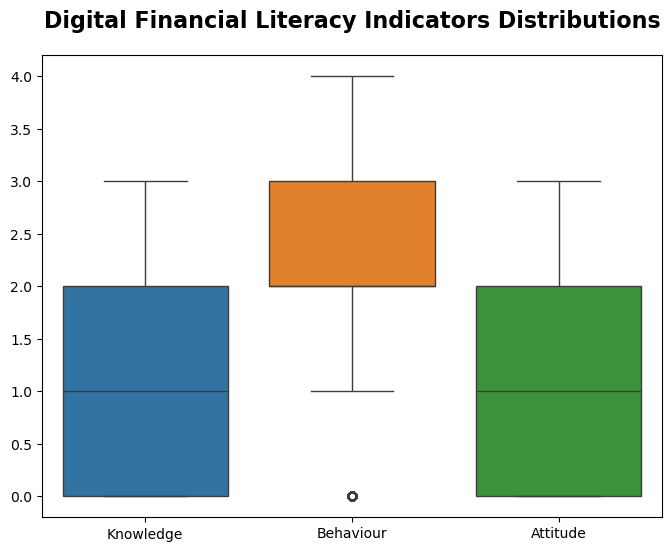

In [18]:
# Display the boxplot of each indicator
plot_distribution_indicators(df_analysis, triple_column='triple')

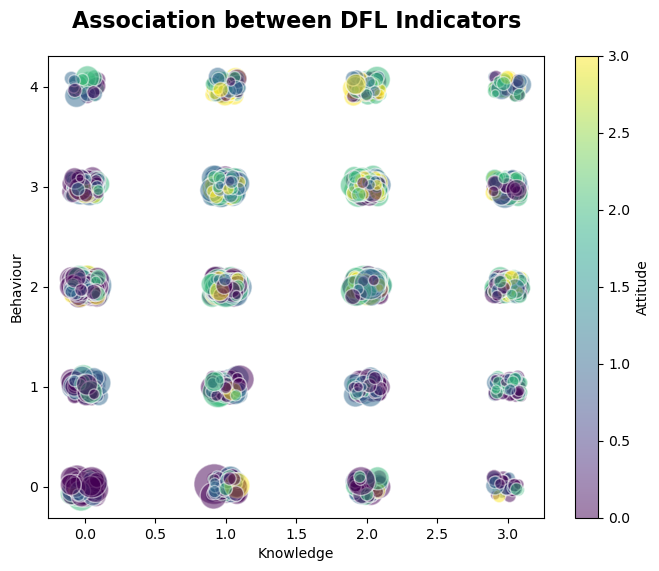

In [19]:
# Display the scatterplot between knowledge and behaviour, coloured by attitude
plot_association_indicators(df_analysis, triple_column='triple')

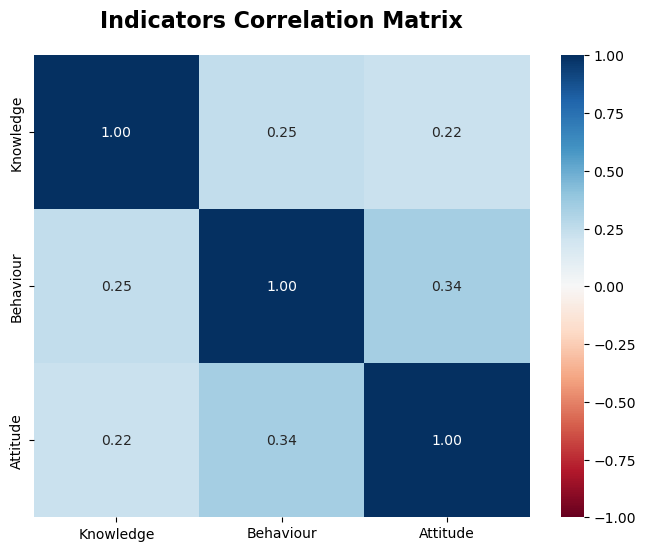

In [20]:
# Display the correlation matrix between indicators
plot_correlation_indicators(df_analysis, triple_column='triple')

### Profile recomputation

In [21]:
# Scale each indicator in the range 0-2
def recompute_profiles(df):
    df_new = df.copy()

    knowledge_conditions = [
        (df_new['knowledge'] <= 1),
        (df_new['knowledge'] == 2),
        (df_new['knowledge'] == 3)
    ]

    behaviour_conditions = [
        (df_new['behaviour'] <= 1),
        (df_new['behaviour'].isin([2, 3])),
        (df_new['behaviour'] == 4)
    ]

    attitude_conditions = [
        (df_new['attitude'] <= 1),
        (df_new['attitude'] == 2),
        (df_new['attitude'] == 3)
    ]

    choices = [0, 1, 2]

    df_new['knowledge_scaled'] = np.select(
        knowledge_conditions, choices, default=0).astype(int)
    df_new['behaviour_scaled'] = np.select(
        behaviour_conditions, choices, default=0).astype(int)
    df_new['attitude_scaled'] = np.select(
        attitude_conditions, choices, default=0).astype(int)

    df_new['triple_scaled'] = df_new[
        ['knowledge_scaled', 'behaviour_scaled', 'attitude_scaled']
        ].apply(tuple, axis=1)

    df_new['final_score_scaled'] = (
        df_new['knowledge_scaled'] +
        df_new['behaviour_scaled'] +
        df_new['attitude_scaled'])
    
    columns_to_drop = ['knowledge', 'behaviour', 'attitude', 'knowledge_scaled',
                       'behaviour_scaled', 'attitude_scaled']
    df_new.drop(columns=columns_to_drop, inplace=True)

    return df_new

In [22]:
# Recompute profiles
df_analysis = recompute_profiles(df_analysis)

# Analyse the recomputed profiles
counts_scaled, weighted_counts_scaled = analyse_profiles(
    df_analysis, profile_col='triple_scaled', tot_profiles=27)

Unique Profiles Observed: 27 / 27

Most Frequent Observed: (0, 1, 0) in 1192 Cases
Most Frequent Weighted: (0, 1, 0) in 25.46% of the Population

Rare Profiles (Count=1): 1
Least Frequent Observed: (2, 0, 2) in 1 Cases
Least Frequent Weighted: (2, 0, 2) in 0.02% of the Population


### Analysis of scaled indicators

In [23]:
# Display the main statistics related to scaled DFL indicators
data = pd.DataFrame(df_analysis['triple_scaled'].tolist(),
                    columns=['Knowledge', 'Behaviour', 'Attitude'])
data['Final Score'] = df_analysis['final_score_scaled']
data[['Knowledge', 'Behaviour', 'Attitude', 'Final Score']].describe()

,Knowledge,Behaviour,Attitude,Final Score
count,4862.000000,4862.000000,4862.000000,4862.000000
mean,0.557589,0.859317,0.505142,1.922049
std,0.724760,0.513503,0.697274,1.296543
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,1.000000
50%,0.000000,1.000000,0.000000,2.000000
75%,1.000000,1.000000,1.000000,3.000000
max,2.000000,2.000000,2.000000,6.000000


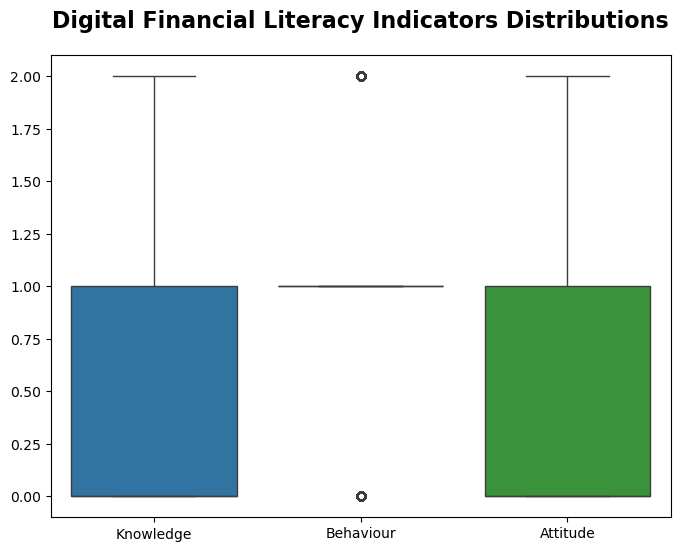

In [24]:
# Display the boxplot of each scaled indicator
plot_distribution_indicators(df_analysis, triple_column='triple_scaled')

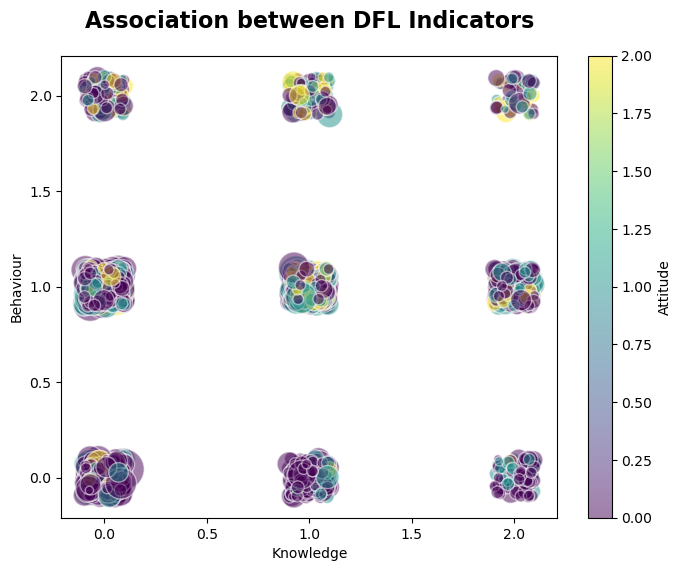

In [25]:
# Display the scatterplot between knowledge and behaviour, coloured by attitude
plot_association_indicators(df_analysis, triple_column='triple_scaled')

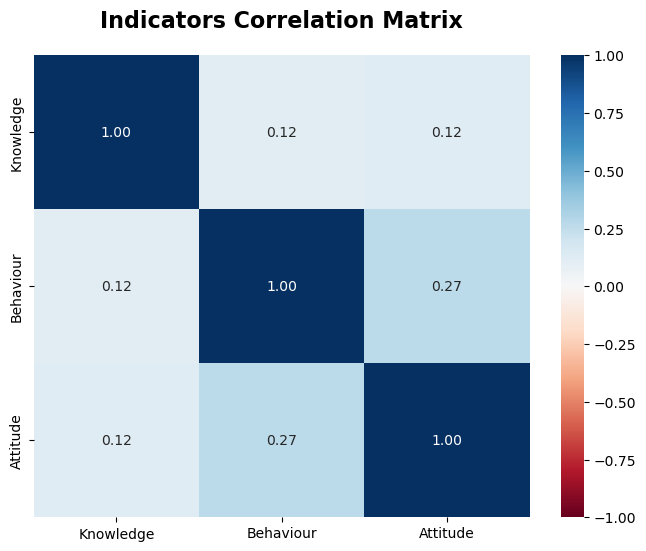

In [26]:
# Display the correlation matrix between scaled indicators
plot_correlation_indicators(df_analysis, triple_column='triple_scaled')

### Hasse diagram

In [27]:
# Define the poset for the profiles
def create_poset(counts):
    unique_profiles = list(counts.keys())

    # Build the directed graph with dominance relations
    graph = nx.DiGraph()
    graph.add_nodes_from(unique_profiles)

    for p1 in unique_profiles:
        for p2 in unique_profiles:
            if p1 != p2:
                if all(x <= y for x, y in zip(p1, p2)):
                    graph.add_edge(p1, p2)

    # Apply transitive reduction and add potential isolated nodes
    transitive_reduction = nx.transitive_reduction(graph)
    transitive_reduction.add_nodes_from(graph.nodes)

    # Add the counts as a graph attribute
    nx.set_node_attributes(transitive_reduction, counts, 'value')

    return transitive_reduction


# Create the Hasse diagram for the observed profiles
def plot_hasse_diagram(poset_graph, title, 
                       scale_node_sizes=False, highligthed_special=False):
    unique_profiles = list(poset_graph.nodes)
    percentages = nx.get_node_attributes(poset_graph, 'value')

    # Define the modal profile and the benchmark
    modal_profile = max(
        percentages, key=percentages.get) if percentages else None
    benchmark = (1, 1, 1)

    # Define the position of each profile based on levels
    levels = {p: sum(p) for p in unique_profiles}
    max_level = max(levels.values()) if levels else 0

    positions = {}
    for level in range(max_level + 1):
        nodes_at_level = sorted([
            p for p in unique_profiles if levels[p] == level])
        for i, p in enumerate(nodes_at_level):
            x = i - (len(nodes_at_level) - 1) / 2
            positions[p] = (x, level)

    # Define the size of each node
    if scale_node_sizes:
        max_perc = max(percentages.values()) if percentages else 1
        node_sizes = [
            800 + (percentages[p] / max_perc) * 4200 for p in unique_profiles]
    else:
        node_sizes = 1500

    # Define the colour of special nodes
    node_colours = []
    edge_widths = []
    for p in unique_profiles:
        if highligthed_special and p == modal_profile:
            node_colours.append('red')
            edge_widths.append(3)
        elif highligthed_special and p == benchmark:
            node_colours.append('#FFD700')
            edge_widths.append(3)
        else:
            node_colours.append('white')
            edge_widths.append(2)

    # Draw edges, nodes, and labels
    plt.figure(figsize=(12, 8))

    nx.draw_networkx_edges(poset_graph, positions, arrows=False, 
                           edge_color='black', width=1.5, alpha=0.7)

    nx.draw_networkx_nodes(poset_graph, positions, 
                           node_size=node_sizes, node_color=node_colours, 
                           edgecolors='black', linewidths=edge_widths)

    nx.draw_networkx_labels(poset_graph, positions,
                            font_size=7, font_weight='bold')

    # Define the legend
    if highligthed_special:
        benchmark_dot = plt.scatter([], [], c='#FFD700', edgecolors='black', 
                                    label='Benchmark (1, 1, 1)')
        modal_dot = plt.scatter([], [], c='red', edgecolors='black', 
                                label=f'Modal Profile {modal_profile}')
        plt.legend(handles=[benchmark_dot, modal_dot], 
                   loc='upper left', scatterpoints=1)
        
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

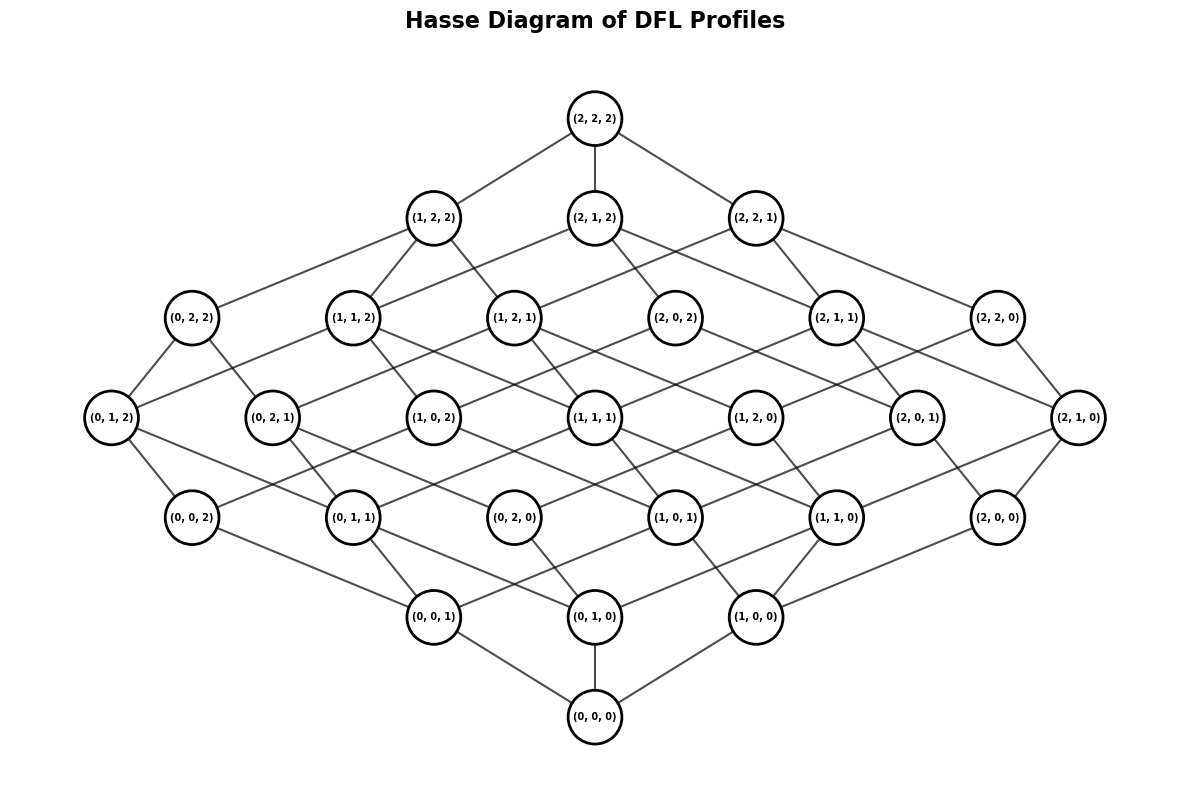

In [28]:
# Create the poset
poset = create_poset(counts_scaled)

# Display the standard Hasse diagram
plot_hasse_diagram(poset, title='Hasse Diagram of DFL Profiles',
                   scale_node_sizes=False, highligthed_special=False)

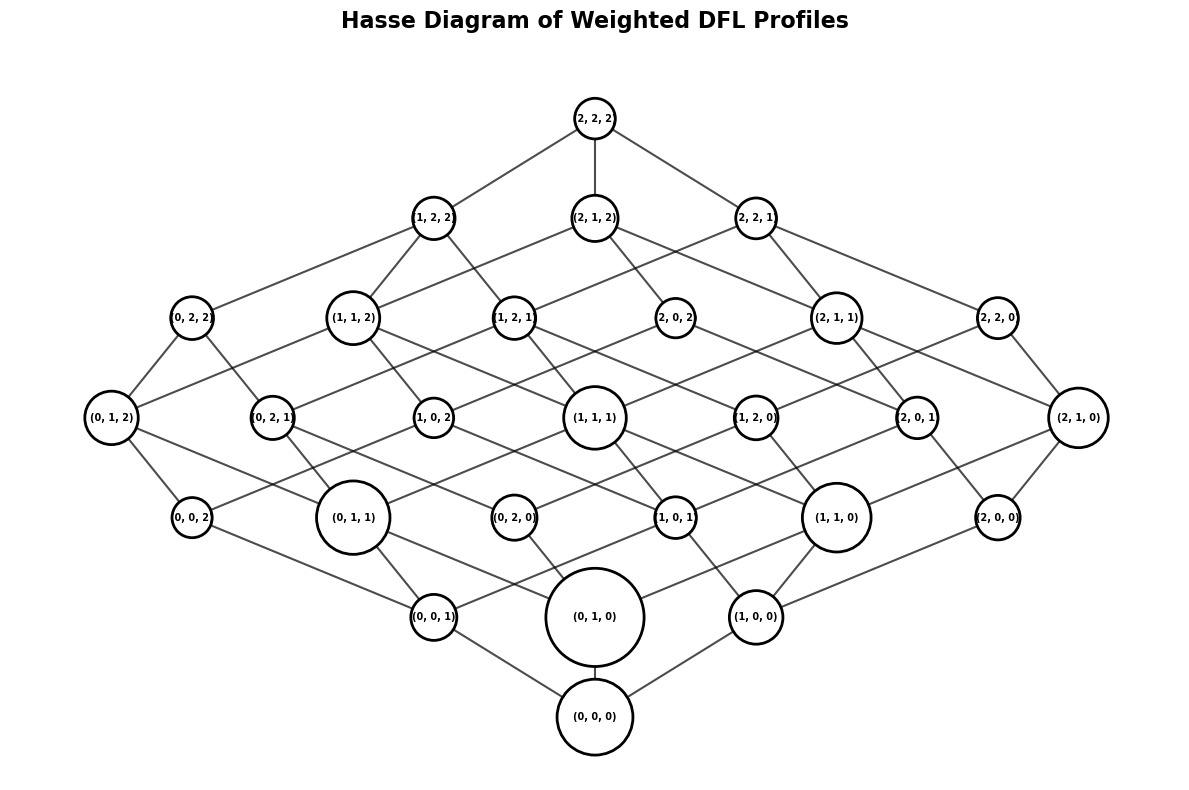

In [29]:
# Display the Hasse diagram with weighted node sizes
plot_hasse_diagram(poset, title='Hasse Diagram of Weighted DFL Profiles',
                   scale_node_sizes=True, highligthed_special=False)

### Analysis of profiles

In [30]:
# Create a histogram for inspecting the distribution of profiles
def plot_profiles_distribution(counts, weighted=False):
    formatted_labels = [f'{k}\n{b}\n{a}' for k, b, a in counts.index]
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x=formatted_labels, y=counts.values)

    if weighted:
      title = f'Weighted Frequency Distribution of Profiles'
      y_label = 'Percentage of Population (%)'
      label_format = '%.1f%%'
    else:
      title = f'Frequency Distribution of Profiles'
      y_label = 'Number of Participants'
      label_format = '%g'

    plt.title(title, fontsize=16, pad=20, fontweight='bold')
    plt.xlabel('Profiles (K, B, A)', fontsize=12, labelpad=12)
    plt.ylabel(y_label, fontsize=12)
    plt.xticks(rotation=0, fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    ax.bar_label(ax.containers[0], fmt=label_format, padding=3, fontsize=8)

    sns.despine(left=True)
    plt.tight_layout()
    plt.show()

In [31]:
# Plot the parallel line of each profile
def plot_parallel_indicators(df):
    df_plot = pd.DataFrame(df['triple_scaled'].tolist(), index=df.index)
    df_plot.columns = ['Knowledge', 'Behaviour', 'Attitude']

    for col in ['Knowledge', 'Behaviour', 'Attitude']:
        df_plot[f'{col} Score'] = df_plot[col].astype(str)

    fig = px.parallel_categories(
        df_plot, 
        dimensions=['Knowledge Score', 'Behaviour Score', 'Attitude Score'],
        color='Behaviour', 
        color_continuous_scale=px.colors.sequential.Viridis,
        title='Flow of Italian Profiles across DFL Indicators'
    )

    fig.update_traces(dimensions=[
        {'categoryarray': ['0', '1', '2'], 'categoryorder': 'array'},
        {'categoryarray': ['0', '1', '2'], 'categoryorder': 'array'},
        {'categoryarray': ['0', '1', '2'], 'categoryorder': 'array'}
    ])

    fig.update_layout(showlegend=False, coloraxis_showscale=False)
    fig.show()

In [32]:
# Plot the composition of profiles
def plot_sunburst(weighted_counts_scaled):
    df_plot = weighted_counts_scaled.reset_index()
    df_plot.columns = ['triple', 'weight']
    
    expanded_cols = pd.DataFrame(df_plot['triple'].tolist(), 
                                 columns=['Knowledge', 'Behaviour', 'Attitude'])
    df_plot = pd.concat([df_plot, expanded_cols], axis=1)

    fig = px.sunburst(df_plot, 
                      path=['Knowledge', 'Behaviour', 'Attitude'],
                      values='weight',
                      title='Weighted Hierarchy of DFL Profiles',
                      color='Knowledge',
                      color_continuous_scale='Viridis')
    
    fig.update_traces(hovertemplate='Weight: %{value:.2f}<br>Label: %{label}')
    fig.update_layout(showlegend=False, coloraxis_showscale=False)
    fig.show()

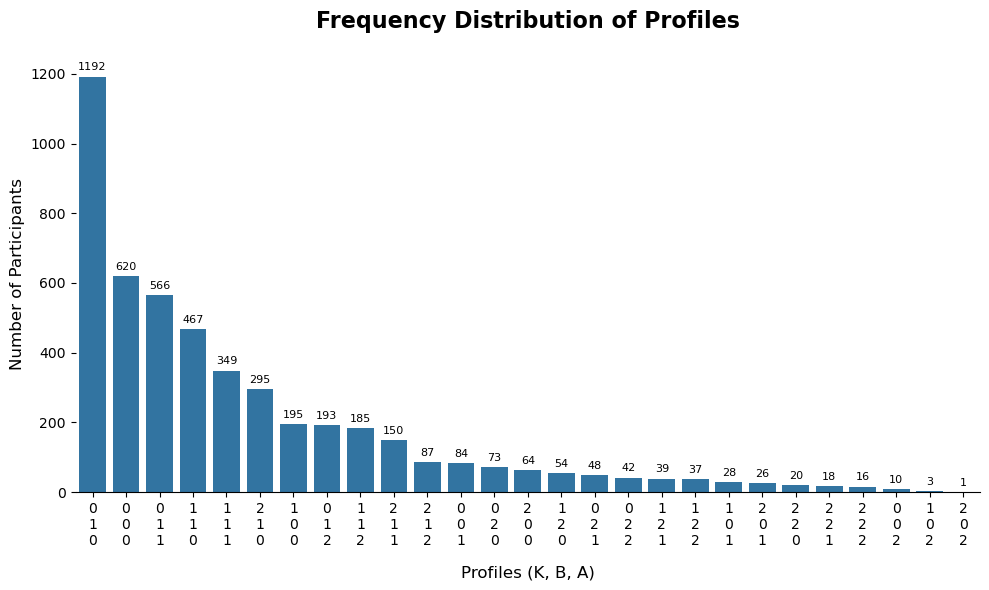

In [33]:
# Plot the distribution of profiles
plot_profiles_distribution(counts_scaled, weighted=False)

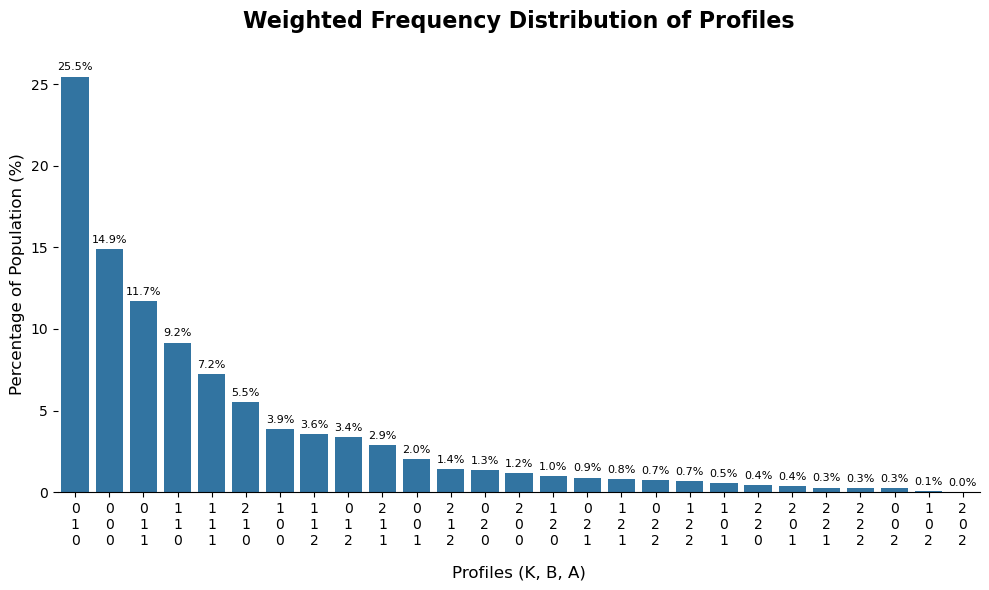

In [34]:
# Plot the weighted distribution of profiles
plot_profiles_distribution(weighted_counts_scaled, weighted=True)

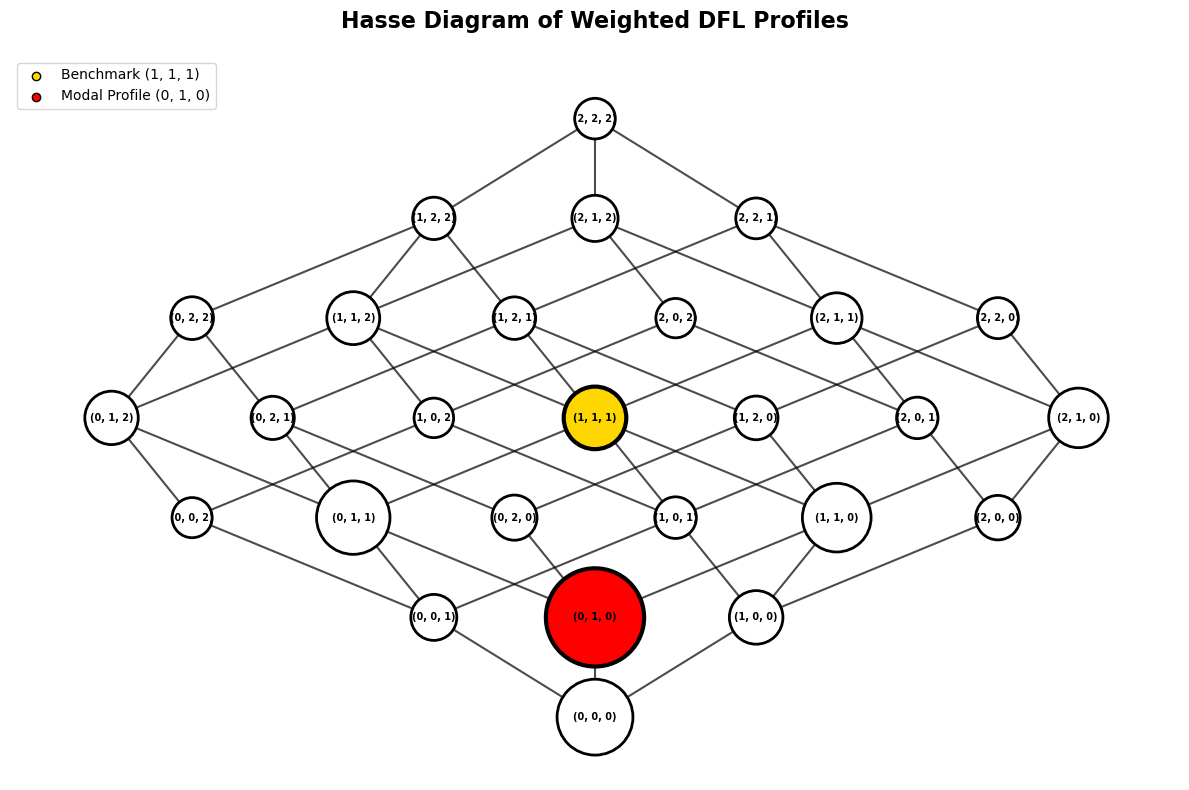

In [35]:
# Display the weighted Hasse diagram with highlighted profiles (benchmark-modal)
plot_hasse_diagram(poset, title='Hasse Diagram of Weighted DFL Profiles',
                   scale_node_sizes=True, highligthed_special=True)

In [36]:
# Display the construction of profiles
plot_parallel_indicators(df_analysis)

In [37]:
# Display the construction of profiles
plot_sunburst(weighted_counts_scaled)

### Mutual Ranking Probabilities

In [38]:
# Compute the number of iterations required for the MCMC chain to converge
def compute_num_samples(E, error=0.05):
    return math.ceil(
        E**4 * (math.log(E))**2 +
        E**3 * math.log(E) * math.log(1 / error)
    )


# Compute the MRP between each pair of profiles 
def compute_mrp(poset_graph, error=0.05, seed=None):
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    unique_profiles = sorted(list(poset_graph.nodes()),
                             key=lambda x: (sum(x), x))
    num_profiles = len(unique_profiles)
    profile_to_index = {p: i for i, p in enumerate(unique_profiles)}

    # Define the comparability matrix
    reachability = nx.transitive_closure(poset_graph)
    comparable = np.zeros((num_profiles, num_profiles), dtype=bool)
    for p1, p2 in reachability.edges():
        comparable[profile_to_index[p1], profile_to_index[p2]] = True

    # Select any linear extension as the initial state
    current_extension = list(nx.topological_sort(poset_graph))
    current_extension_index = np.array([
        profile_to_index[p] for p in current_extension])
    mrp_counts = np.zeros((num_profiles, num_profiles), dtype=np.float64)

    # Define the number of steps of the algorithm
    num_samples = compute_num_samples(num_profiles, error)
    burn_in = int(num_samples * 0.1)
    total_steps = burn_in + num_samples

    # Perform MCMC sampling using adjacent transposition
    # Converge is guaranteed by the Bubley-Dyer path coupling analysis
    for step in tqdm(range(total_steps), desc='Computing MRP through MCMC'):
        i = random.randint(0, num_profiles-2)
        p1, p2 = current_extension_index[i], current_extension_index[i+1]

        # Swap p1 and p2 only if they are not constrained
        if not comparable[p1, p2]:
            current_extension_index[i], current_extension_index[i+1] = p2, p1

        if step >= burn_in:
            # Associate the current position to the index of the profile
            ranks = np.empty(num_profiles, dtype=int)
            ranks[current_extension_index] = np.arange(num_profiles)

            # Compare all profiles
            mrp_counts += (ranks[:, None] > ranks[None, :])

    # Compute the MRP matrix
    mrp_matrix = mrp_counts / num_samples
    return pd.DataFrame(mrp_matrix,
                        index=unique_profiles, columns=unique_profiles)

In [39]:
# Create the heatmap for visualizating the MRP matrix
def plot_mrp_matrix(mrp_matrix):
    plt.figure(figsize=(10,8))
    formatted_labels = [f'({k},\n{b},\n{a})' for k, b, a in mrp_matrix.index]
    sns.heatmap(mrp_matrix,
                cmap='RdBu', linewidths=0.1,
                xticklabels=formatted_labels)

    plt.title('Mutual Ranking Probabilities')
    plt.tight_layout()
    plt.show()

In [40]:
# Compute the MRP matrix
mrp_df = compute_mrp(poset, seed=1234)

Computing MRP through MCMC: 100%|██████████| 6563852/6563852 [02:18<00:00, 47474.82it/s]


In [41]:
# Round and display the MRP matrix
mrp_rounded = mrp_df.round(2)
mrp_rounded

,"(0, 0, 0)","(0, 0, 1)","(0, 1, 0)","(1, 0, 0)","(0, 0, 2)","(0, 1, 1)","(0, 2, 0)","(1, 0, 1)","(1, 1, 0)","(2, 0, 0)",...,"(0, 2, 2)","(1, 1, 2)","(1, 2, 1)","(2, 0, 2)","(2, 1, 1)","(2, 2, 0)","(1, 2, 2)","(2, 1, 2)","(2, 2, 1)","(2, 2, 2)"
"(0, 0, 0)",0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0
"(0, 0, 1)",1.0,0.00,0.50,0.50,0.00,0.00,0.10,0.00,0.08,0.10,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0
"(0, 1, 0)",1.0,0.50,0.00,0.50,0.10,0.00,0.00,0.08,0.00,0.10,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0
"(1, 0, 0)",1.0,0.50,0.50,0.00,0.11,0.08,0.10,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0
"(0, 0, 2)",1.0,1.00,0.90,0.89,0.00,0.49,0.49,0.49,0.48,0.50,...,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.0
"(0, 1, 1)",1.0,1.00,1.00,0.92,0.51,0.00,0.51,0.50,0.50,0.51,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0
"(0, 2, 0)",1.0,0.90,1.00,0.90,0.51,0.49,0.00,0.50,0.49,0.51,...,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.0
"(1, 0, 1)",1.0,1.00,0.92,1.00,0.51,0.50,0.50,0.00,0.50,0.51,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0
"(1, 1, 0)",1.0,0.92,1.00,1.00,0.52,0.50,0.51,0.50,0.00,0.51,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0
"(2, 0, 0)",1.0,0.90,0.90,1.00,0.50,0.49,0.49,0.49,0.49,0.00,...,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0


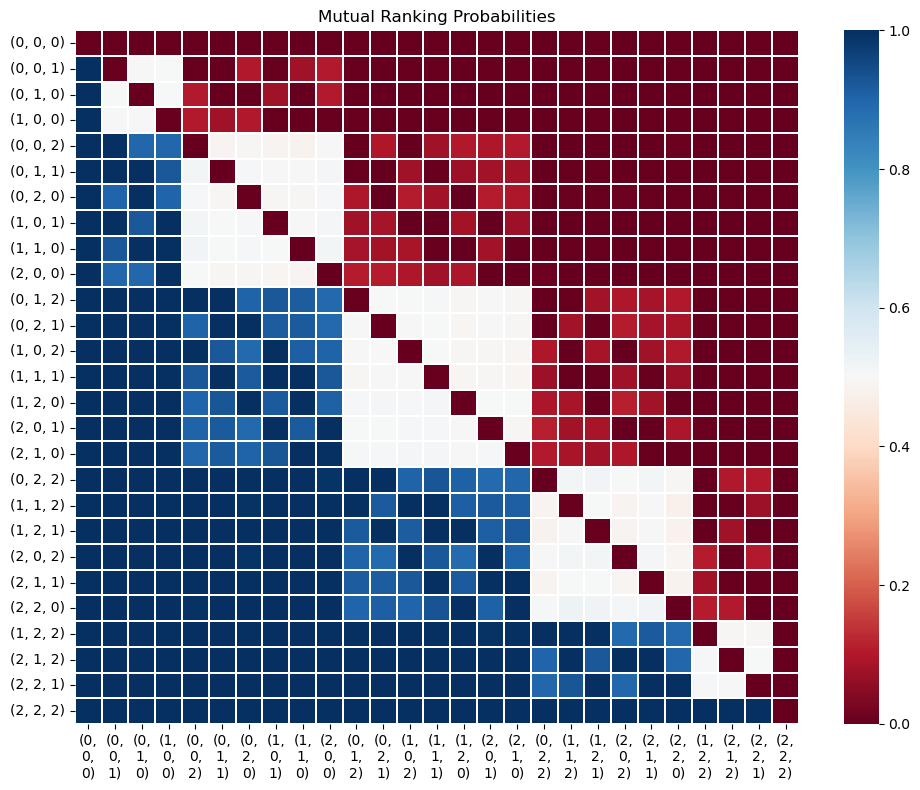

In [42]:
# Plot the MRP matrix
plot_mrp_matrix(mrp_df)

### Dominance, Incomparability, Separation

In [43]:
# Compute dominance and incomparability from the MRP matrix
def compute_poset_metrics(mrp_df):
    mrp_matrix = mrp_df.to_numpy()

    # Compute the dominance score (average rank)
    dominance_scores = mrp_df.sum(axis=1).values

    # Compute the incomparability score
    incomparability_scores = 1 - np.abs(mrp_matrix - 0.5).mean(axis=1) * 2

    return dominance_scores, incomparability_scores

In [44]:
# Define the fuzzy separation matrix between profiles
def compute_separation(mrp_df):
    mrp_matrix = mrp_df.to_numpy()
    num_profiles = mrp_matrix.shape[0]

    # Compute the separation matrix using fuzzy logic
    sep_matrix = np.zeros((num_profiles, num_profiles))
    for i in range(num_profiles):
        for j in range(num_profiles):
            # The element z is dominated by i and dominates j (between i and j)
            z = np.minimum(mrp_matrix[:, i], mrp_matrix[j, :])
            sep_matrix[i, j] = np.sum(z)

    return pd.DataFrame(sep_matrix, index=mrp_df.index, columns=mrp_df.columns)

In [45]:
# Identify which dimension represents the main bottleneck
def identify_bottlenecks(profiles, weights, benchmark=(1, 1, 1)):
    profiles_vector = np.array(profiles)
    benchmark_vector = np.array(benchmark)
    weights = np.array([weights.get(tuple(p), 0) for p in profiles_vector])

    # Compute the weighted vertical gaps from the benchmark
    gaps = np.maximum(0, benchmark_vector - profiles_vector)
    weighted_gaps = np.average(gaps, axis=0, weights=weights).round(3)

    return pd.Series({
        'Knowledge': weighted_gaps[0],
        'Behaviour': weighted_gaps[1],
        'Attitude': weighted_gaps[2]
    }).sort_values(ascending=False)

In [46]:
# Interpret specific profiles
def analyse_profiles(mrp_df, weighted_counts_scaled, modal_profile, benchmark):
    # Compute dominance and incomparability for each profile
    dominance_scores, incomparability_scores = compute_poset_metrics(mrp_df)

    # Compute the weight percentage
    total_pop = weighted_counts_scaled.sum()
    pop_percentage = (weighted_counts_scaled / total_pop) * 100

    summary = pd.DataFrame({
        'Dominance': dominance_scores,
        'Incomparability': incomparability_scores,
        'Population': pop_percentage
    }, index=mrp_df.index)

    for label, profile in [
        ('Benchmark', benchmark), ('Modal profile', modal_profile)]:
        print(f'{label}: {profile}')
        print(f" - Dominance: {summary.at[profile, 'Dominance']:.3f}")
        print(f" - Incomparability: {summary.at[profile, 'Incomparability']:.3f}")
        print(f" - Population: {summary.at[profile, 'Population']:.2f}%\n")
    
    return summary

In [47]:
# Analyse specific profiles
summary = analyse_profiles(mrp_df, weighted_counts_scaled,
                           modal_profile=(0, 1, 0), benchmark=(1, 1, 1))

Benchmark: (1, 1, 1)
 - Dominance: 12.951
 - Incomparability: 0.253
 - Population: 7.21%

Modal profile: (0, 1, 0)
 - Dominance: 2.295
 - Incomparability: 0.096
 - Population: 25.46%



In [48]:
# Compute the separation matrix
separation_matrix = compute_separation(mrp_df)

# Display the incomparability index and identify the main bottleneck
mean_incomparability = np.average(
    summary['Incomparability'],
    weights=np.array([weighted_counts_scaled.get(
        tuple(p), 0) for p in np.array(mrp_df.index)]))
print(f'Weighted Incomparability Index: {mean_incomparability:.3f}')

bottlenecks = identify_bottlenecks(
    mrp_df.index.tolist(), weighted_counts_scaled)
print(f'\nBottlenecks from Benchmark (1, 1, 1): \n{bottlenecks}')

Weighted Incomparability Index: 0.151

Bottlenecks from Benchmark (1, 1, 1): 
Attitude     0.628
Knowledge    0.607
Behaviour    0.233
dtype: float64


---

## **3. Influence of digital financial service usage and high self-confidence**

In [49]:
# Create behavioural mismatch dataset
def build_gap_dataset(df_analysis):
    df_gap = pd.DataFrame(df_analysis['triple_scaled'].tolist(),
                          columns=['Knowledge', 'Behaviour', 'Attitude'],
                          index=df_analysis.index)
    df_gap['dfs_intensity'] = df_analysis['dfs_intensity']
    df_gap['self_confidence'] = df_analysis['self_confidence']

    controls = [
        'gender',
        'region',
        'living_community',
        'internet_access',
        'age_class',
        'education_level',
        'household_income'
    ]

    for col in controls:
        df_gap[col] = df_analysis[col]

    df_gap['weight'] = df_analysis['weight']

    return df_gap

In [50]:
# Identify behavioural-cognitive mismatch
def compute_mismatch(df):
    df = df.copy()
    df['positive_mismatch'] = (
        (df['Behaviour'] > df['Knowledge']) &
        (df['Behaviour'] > df['Attitude'])
    ).astype(int)

    return df

In [51]:
# Plot DFS intensity distribution
def plot_dfs_distribution(df):
    plt.figure(figsize=(8,5))
    plt.hist(df['dfs_intensity'], bins=10)
    plt.xlabel('Digital Services Usage Intensity')
    plt.ylabel('Frequency')
    plt.title('Distribution of Digital Financial Service Usage')
    plt.show()

In [52]:
# Plot Mismatch by education
def plot_mismatch_education(df):
    mismatch_rates = df.groupby('education_level')['positive_mismatch'].mean()
    mismatch_rates.plot(kind='bar')
    plt.ylabel('Mismatch Probability')
    plt.title('Behavioural-Cognitive Mismatch by Education')
    plt.show()

In [53]:
# Plot Self-confidence against mismatch
def plot_confidence_mismatch(df):
    sns.boxplot(x='positive_mismatch', y='self_confidence', data=df)
    plt.title('Self-Confidence and Behavioural Mismatch')
    plt.show()

In [54]:
# Estimate weighted logistic regression
def estimate_logit(df):
    y = df['positive_mismatch']
    X_base = df[['dfs_intensity', 'self_confidence', 
                 'gender', 'internet_access']].copy()

    age_dummies = pd.get_dummies(
        df['age_class'], prefix='age', drop_first=True, dtype=int)
    edu_dummies = pd.get_dummies(
        df['education_level'], prefix='edu', drop_first=True, dtype=int)
    inc_dummies = pd.get_dummies(
        df['household_income'], prefix='inc', drop_first=True, dtype=int)
    X = pd.concat([X_base, age_dummies, edu_dummies, inc_dummies], axis=1)

    X = sm.add_constant(X)

    model = sm.GLM(
        y, X, family=sm.families.Binomial(), freq_weights=df['weight']).fit()
    
    return model

In [55]:
# Estimate weighted logistic regression including only those with internet access
def estimate_logit_filtered(df):
    df_users = df[df['internet_access'] == 1].copy()
    
    y = df_users['positive_mismatch']
    X_base = df_users[['dfs_intensity', 'self_confidence', 'gender']].copy()
    
    age_dummies = pd.get_dummies(
        df_users['age_class'], prefix='age', drop_first=True, dtype=int)
    edu_dummies = pd.get_dummies(
        df_users['education_level'], prefix='edu', drop_first=True, dtype=int)
    inc_dummies = pd.get_dummies(
        df_users['household_income'], prefix='inc', drop_first=True, dtype=int)
    
    X = pd.concat([X_base, age_dummies, edu_dummies, inc_dummies], axis=1)
    
    X = sm.add_constant(X)
    model = sm.GLM(
        y, X, 
        family=sm.families.Binomial(), freq_weights=df_users['weight']).fit()

    df_users['predicted_probability'] = model.predict(X)

    return model, df_users

In [56]:
# Plot heatmaps 
def multi_heatmaps(data, variables, value_var='predicted_probability', 
                   cmap='viridis', annot=False, figsize=(14, 12)):
       
    n = len(variables)
    fig, axes = plt.subplots(n, n, figsize=figsize)

    for i, row_var in enumerate(variables):
        for j, col_var in enumerate(variables):

            ax = axes[i, j]

            if row_var == col_var:
                ax.axis("off")
                continue

            heatmap_data = (
                data
                .groupby([row_var, col_var])[value_var]
                .mean()
                .unstack()
            )

            sns.heatmap(
                heatmap_data,
                ax=ax,
                cmap=cmap,
                annot=annot,
                cbar=(i == 0 and j == n - 1)
            )

            ax.set_title(f"{row_var} × {col_var}", fontsize=9)
            ax.set_xlabel("")
            ax.set_ylabel("")

    plt.tight_layout()
    plt.show()

In [57]:
# Extracts parameters and 95% CIs from both GLM models and creates a comparative Forest Plot
def plot_model_comparison(model_baseline, model_filtered):
    def extract_metrics(model, label):
        conf = model.conf_int()
        df = pd.DataFrame({
            'coef': model.params,
            'lower': conf[0],
            'upper': conf[1],
            'variable': model.params.index,
            'model': label
        })
        return df.drop('const', errors='ignore')

    df_base = extract_metrics(model_baseline, 'Baseline Model')
    df_filt = extract_metrics(model_filtered, 'Restricted Model (Connected Users)')
    df_all = pd.concat([df_base, df_filt], axis=0).reset_index(drop=True)

    variables = df_base['variable'].unique()
    y_positions = np.arange(len(variables))
    
    plt.figure(figsize=(10, 7))
    offset = 0.15
    
    # Plot Baseline Model
    b_data = df_all[df_all['model'] == 'Baseline Model'].set_index('variable').reindex(variables)
    plt.errorbar(b_data['coef'], y_positions + offset, 
                 xerr=[b_data['coef'] - b_data['lower'], b_data['upper'] - b_data['coef']],
                 fmt='o', color='#1f77b4', label='Baseline Model', capsize=4, markersize=6)
    
    # Plot Filtered Model
    f_data = df_all[df_all['model'] == 'Restricted Model (Connected Users)'].set_index('variable').reindex(variables)
    plt.errorbar(f_data['coef'], y_positions - offset, 
                 xerr=[f_data['coef'] - f_data['lower'], f_data['upper'] - f_data['coef']],
                 fmt='o', color='#ff7f0e', label='Restricted Model (Connected)', capsize=4, markersize=6)
    
    plt.axvline(x=0, color='black', linestyle='--', alpha=0.5, linewidth=1.2)
    plt.yticks(y_positions, variables, fontsize=10)
    plt.xlabel('Estimated Coefficient ($\\hat{\\beta}$)', fontsize=12)
    plt.title('Logit Coefficient Estimates & 95% Confidence Intervals', fontsize=13, fontweight='bold', pad=15)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='lower left', frameon=True, facecolor='white', edgecolor='none')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

In [58]:
# Generates a marginal effect line plot for self_confidence holding other variables constant at sample baselines
def plot_self_confidence_marginal_effect(model_filtered, df_users):
    conf_min = df_users['self_confidence'].min()
    conf_max = df_users['self_confidence'].max()
    confidence_grid = np.linspace(conf_min, conf_max, 100)
    
    feature_names = model_filtered.model.exog_names
    synthetic_X = pd.DataFrame(0.0, index=np.arange(100), columns=feature_names)
    
    if 'const' in synthetic_X.columns:
        synthetic_X['const'] = 1.0
    if 'dfs_intensity' in synthetic_X.columns:
        synthetic_X['dfs_intensity'] = df_users['dfs_intensity'].mean()
    if 'gender' in synthetic_X.columns:
        synthetic_X['gender'] = df_users['gender'].mode()[0]
        
    synthetic_X['self_confidence'] = confidence_grid
    
    predicted_probabilities = model_filtered.predict(synthetic_X)
    
    plt.figure(figsize=(7.5, 4.5))
    plt.plot(confidence_grid, predicted_probabilities, color='teal', linewidth=2.5, 
             label='Predicted Mismatch Probability')
    
    plt.xlabel('Technological Self-Confidence Level', fontsize=11)
    plt.ylabel('Probability of Positive Mismatch ($Y=1$)', fontsize=11)
    plt.title('Marginal Effect of Technological Self-Confidence on Mismatch Risk\n(Socio-Demographic Group Controls Held at Reference Baselines)', 
              fontsize=11, fontweight='bold', pad=12)
    plt.ylim(0, 1.0)
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [59]:
# Create behavioural mismatch dataset
df_gap = build_gap_dataset(df_analysis)
df_gap = compute_mismatch(df_gap)

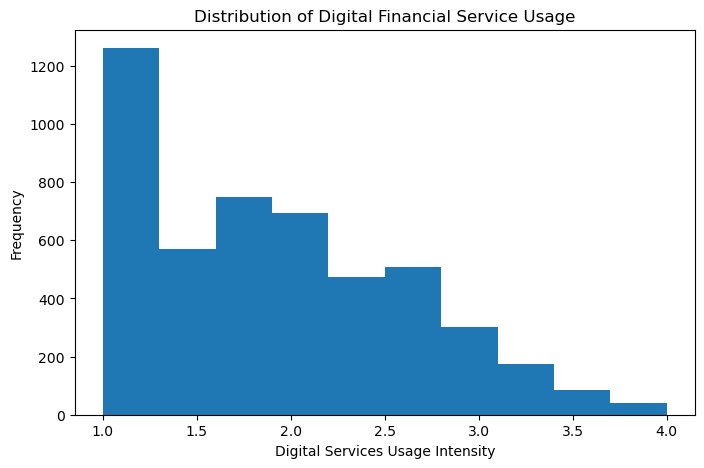

In [60]:
# Plot distribution of service usage
plot_dfs_distribution(df_gap)

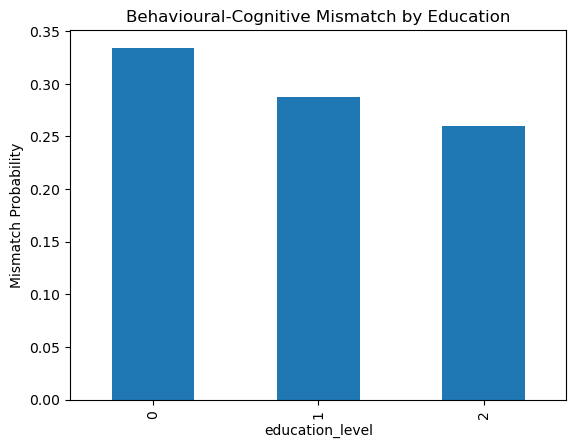

In [61]:
# Plot bar plot of mismatches across education levels
plot_mismatch_education(df_gap)

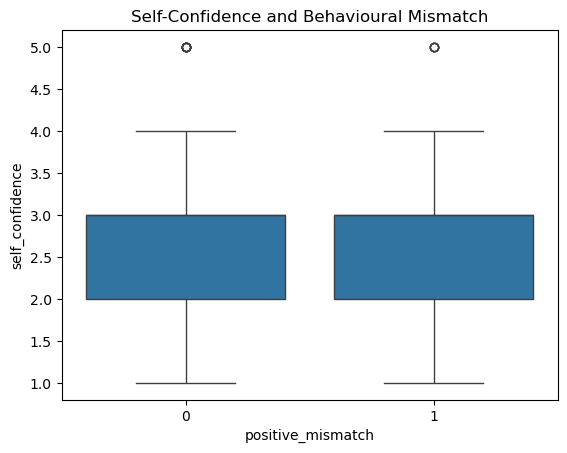

In [62]:
# Plot boxplot of mismatch against self-confidence
plot_confidence_mismatch(df_gap)

In [63]:
# Build the full model configuration
model_base = estimate_logit(df_gap)
print(model_base.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:      positive_mismatch   No. Observations:                 4862
Model:                            GLM   Df Residuals:                  4851.00
Model Family:                Binomial   Df Model:                           10
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2919.3
Date:                Sat, 30 May 2026   Deviance:                       5838.5
Time:                        15:48:23   Pearson chi2:                 4.86e+03
No. Iterations:                     4   Pseudo R-squ. (CS):            0.01173
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.2763      0.149     

In [64]:
# Build constrained model configuration
model_filt, df_users = estimate_logit_filtered(df_gap)
print(model_filt.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:      positive_mismatch   No. Observations:                 4427
Model:                            GLM   Df Residuals:                  4314.34
Model Family:                Binomial   Df Model:                            9
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2552.5
Date:                Sat, 30 May 2026   Deviance:                       5105.1
Time:                        15:48:23   Pearson chi2:                 4.33e+03
No. Iterations:                     4   Pseudo R-squ. (CS):           0.003550
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.9540      0.145     

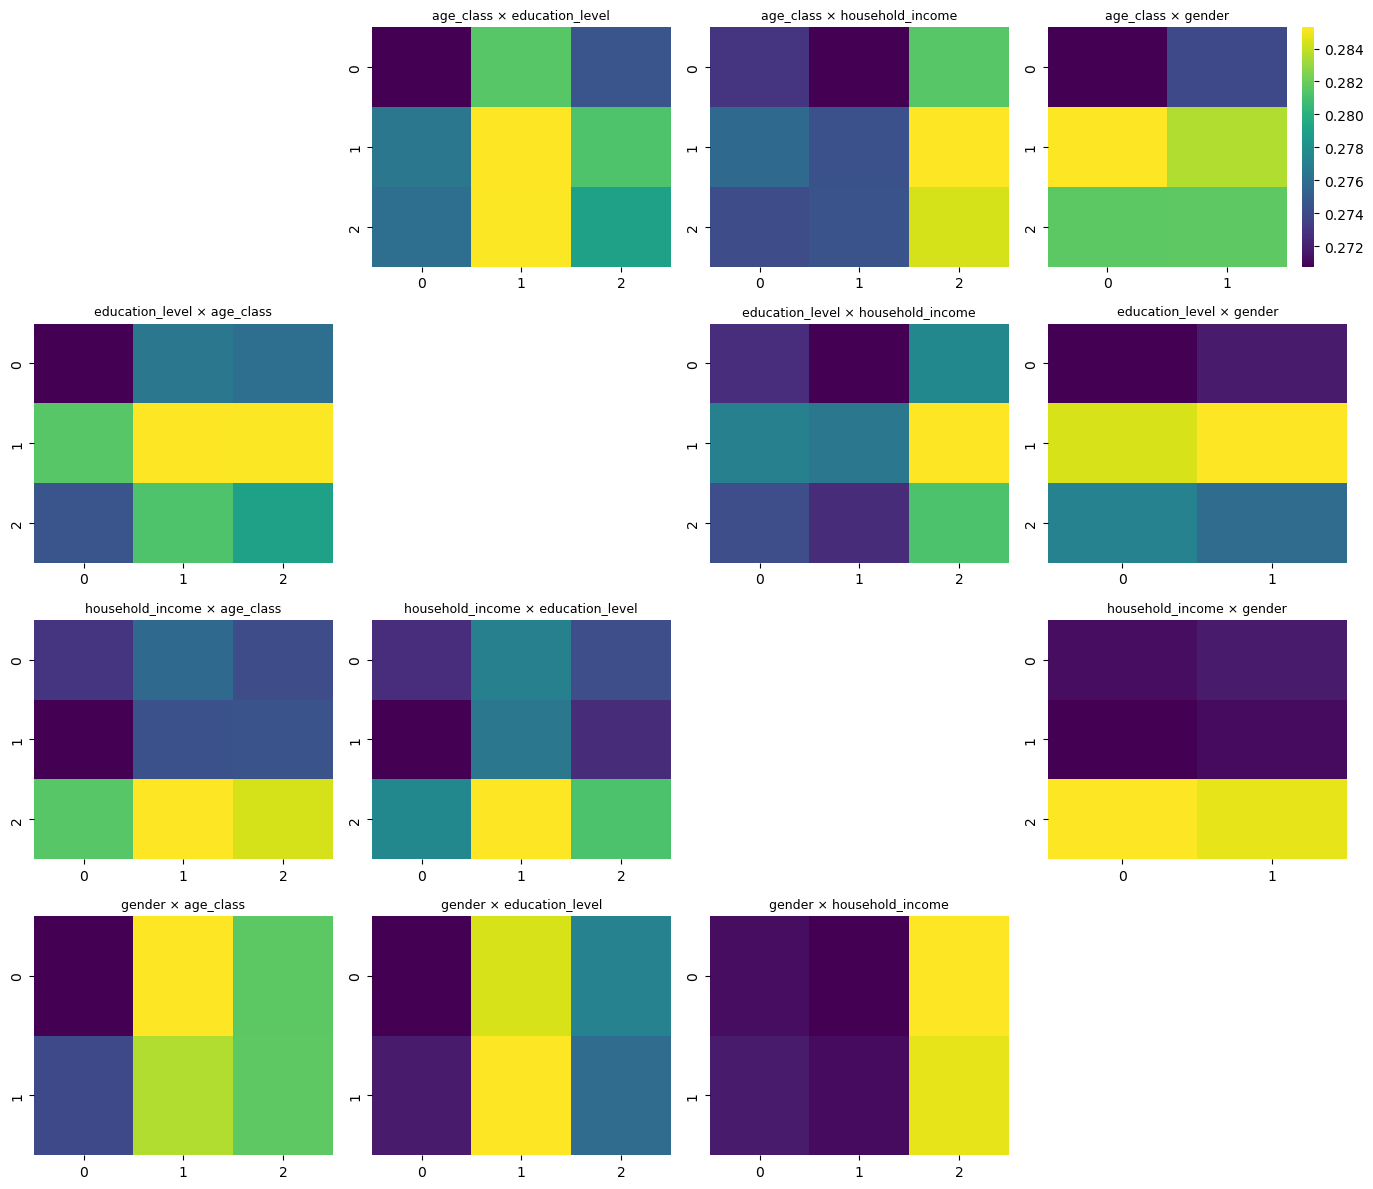

In [65]:
# Plot multiheatmaps of the predicted proabilities
multi_heatmaps(data=df_users, variables=['age_class', 'education_level', 'household_income', 'gender'],
               value_var='predicted_probability')

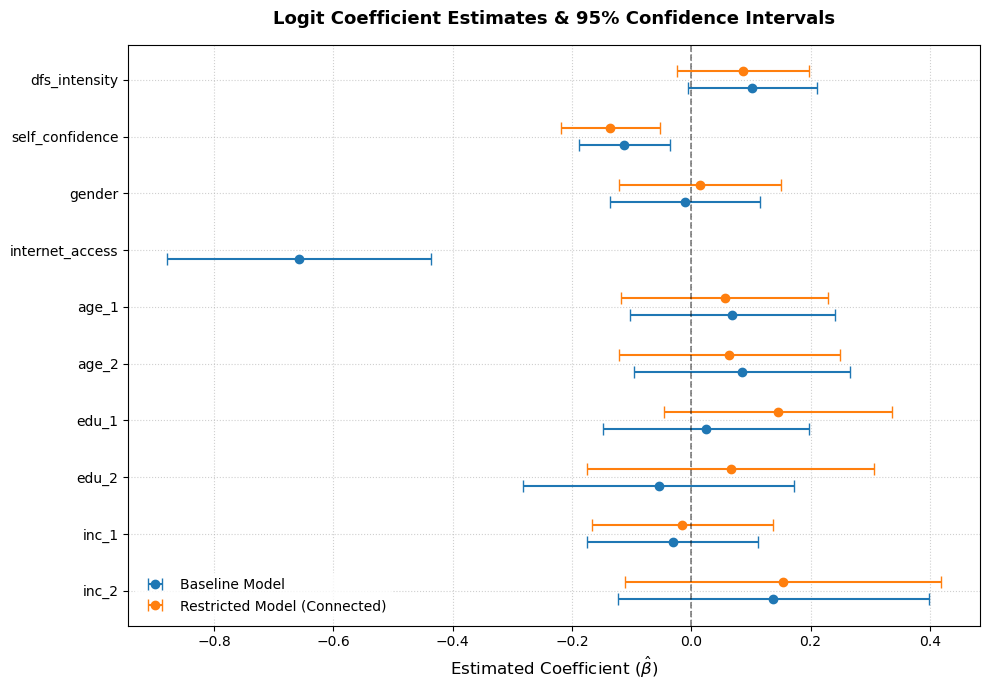

In [66]:
# Plot both Baseline and Filtered models
plot_model_comparison(model_base, model_filt)

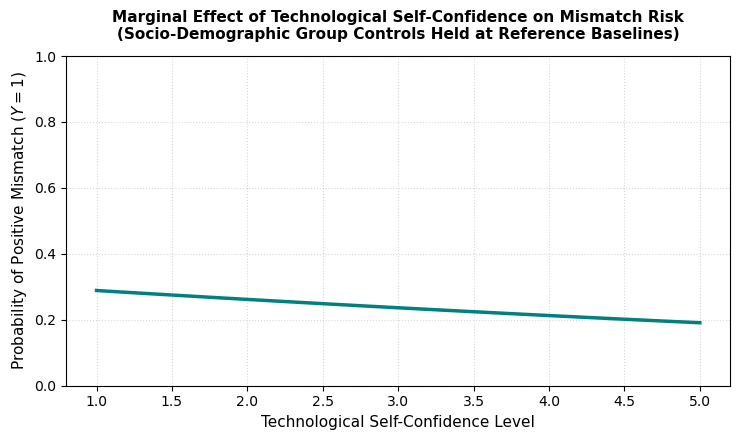

In [67]:
# Plot raw curve
plot_self_confidence_marginal_effect(model_filt, df_users)

---

## **4. Analysis of regional disparities, generational gaps, and educational levels**

### Regional disparities

In [68]:
# Set global plotting style for visual consistency
plt.style.use('seaborn-v0_8-whitegrid')

REGION_MAP = {
    0: 'North',
    1: 'Center',
    2: 'South-Islands'
}

REGION_ORDER = [
    'North',
    'Center',
    'South-Islands'
]

# Create macro-region labels from raw region codes
def prepare_regional_dataframe(df):

    df_new = df.copy()

    df_new['macro_region'] = (
        df_new['region']
        .map(REGION_MAP)
    )

    return df_new


# Plot weighted distribution using a donut chart
def plot_weighted_donut(
    data,
    labels,
    colors,
    title,
    center_title,
    explode=None
):

    plt.figure(figsize=(12, 8), facecolor='white')

    if explode is None:
        explode = [0.03] * len(labels)

    wedges, texts, autotexts = plt.pie(
        data,
        labels=labels,
        autopct=lambda p: f'{p:.1f}%',
        startangle=140,
        colors=colors,
        pctdistance=0.82,
        explode=explode,
        textprops={
            'fontsize': 14,
            'fontweight': 'bold',
            'color': 'black'
        }
    )

    for autotext in autotexts:
        autotext.set_color('black')
        autotext.set_weight('bold')
        autotext.set_fontsize(14)

    centre_circle = plt.Circle(
        (0, 0),
        0.70,
        fc='white',
        linewidth=1.25
    )

    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)

    plt.text(
        0,
        0,
        f'{center_title}',
        ha='center',
        va='center',
        fontsize=16,
        fontweight='bold',
        color='#333333'
    )

    plt.title(
        title,
        fontsize=20,
        fontweight='bold',
        pad=25,
        color='#2c3e50'
    )

    plt.axis('equal')
    plt.tight_layout()
    plt.show()


# Show weighted sample composition by region
def plot_region_distribution(df):

    region_weights = (
        df.groupby('macro_region')['weight']
        .sum()
        .reindex(REGION_ORDER)
    )

    labels = REGION_ORDER

    colors = [
        '#1f77b4',
        '#2ca02c',
        '#ff7f0e'
    ]

    plot_weighted_donut(
        data=region_weights.values,
        labels=labels,
        colors=colors,
        title='Weighted Sample Distribution by Italian Macro-Region',
        center_title=' '
    )


# Compute weighted distribution of DFL profiles by region
def compute_profile_heatmap(df):

    contingency_table = pd.crosstab(
        df['macro_region'],
        df['triple_scaled'].astype(str),
        values=df['weight'],
        aggfunc='sum'
    ).fillna(0)

    heatmap_data = (
        contingency_table
        .div(contingency_table.sum(axis=1), axis=0)
        * 100
    )

    heatmap_data = heatmap_data.reindex(REGION_ORDER)

    sorted_cols = sorted(
        heatmap_data.columns,
        key=lambda x: (
            sum(ast.literal_eval(x)),
            ast.literal_eval(x)
        )
    )

    heatmap_data = heatmap_data[sorted_cols]

    return contingency_table, heatmap_data


# Visualize regional distribution of DFL profiles as heatmap
def plot_profile_heatmap(heatmap_data):

    plt.figure(figsize=(16, 6))

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".1f",
        cmap="YlGnBu",
        linewidths=0.5,
        annot_kws={
            "size": 8,
            "weight": "bold"
        },
        cbar_kws={
            'label': 'Percentage (%)'
        }
    )

    plt.title(
        "DFL Profile Distribution Across Italian Macro-Regions",
        fontsize=18,
        fontweight='bold',
        color='#2c3e50'
    )

    plt.xlabel(
        "DFL Profiles (K, B, A)",
        fontsize=12,
        fontweight='bold'
    )

    plt.ylabel(
        "Macro Region",
        fontsize=12,
        fontweight='bold'
    )

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# Compute most frequent weighted profiles per region
def compute_weighted_profiles(df):

    weighted_profiles = (
        df.groupby(
            ['macro_region', 'triple_scaled']
        )['weight'].sum().reset_index()
    )

    weighted_profiles['Percentage'] = (
        weighted_profiles
        .groupby('macro_region')['weight']
        .transform(lambda x: x / x.sum() * 100)
    )

    return weighted_profiles


# Plot top DFL profiles for each region
def plot_top_profiles(weighted_profiles, top_n=7):

    df_final_plot = (
        weighted_profiles
        .sort_values(
            ['macro_region', 'Percentage'],
            ascending=[True, False]
        )
        .groupby('macro_region')
        .head(top_n)
        .copy()
    )

    df_final_plot['Profile (K,B,A)'] = (
        df_final_plot['triple_scaled'].astype(str)
    )

    g = sns.catplot(
        data=df_final_plot,
        kind="bar",
        x="Percentage",
        y="Profile (K,B,A)",
        col="macro_region",
        col_order=REGION_ORDER,
        palette="magma",
        sharey=False,
        height=5,
        aspect=1.3
    )

    g.set_axis_labels(
        "Weighted Population (%)",
        "DFL Profile (K, B, A)"
    )

    g.set_titles("{col_name}")

    for ax in g.axes.flat:
        ax.set_xlim(
            0,
            df_final_plot['Percentage'].max() + 5
        )

        for p in ax.patches:
            ax.annotate(
                f'{p.get_width():.1f}%',
                (
                    p.get_width(),
                    p.get_y() + p.get_height() / 2
                ),
                ha='left',
                va='center',
                xytext=(5, 0),
                textcoords='offset points',
                fontsize=9,
                fontweight='bold',
                color='#34495e'
            )

    plt.subplots_adjust(top=0.88)
    g.fig.suptitle(
        'Regional Archetypes: Top Weighted DFL Profiles',
        fontsize=22,
        fontweight='900',
        color='#2c3e50'
    )

    plt.tight_layout()
    plt.show()


# Compute weighted regional statistics for DFL dimensions
def compute_regional_statistics(df):

    temp = pd.DataFrame(
        df['triple_scaled'].tolist(),
        columns=['Knowledge', 'Behaviour', 'Attitude']
    )

    temp['macro_region'] = df['macro_region']
    temp['weight'] = df['weight']

    stats = (
        temp.groupby('macro_region')
        .apply(
            lambda x: pd.Series({
                'Knowledge': np.average(x['Knowledge'], weights=x['weight']),
                'Behaviour': np.average(x['Behaviour'], weights=x['weight']),
                'Attitude': np.average(x['Attitude'], weights=x['weight'])
            })
        )
    )

    stats = stats.reindex(REGION_ORDER)
    return stats


# Compute national weighted averages for comparison
def compute_national_statistics(df):

    temp = pd.DataFrame(
        df['triple_scaled'].tolist(),
        columns=['Knowledge', 'Behaviour', 'Attitude']
    )

    temp['weight'] = df['weight']

    national_stats = {
        'Knowledge': np.average(temp['Knowledge'], weights=temp['weight']),
        'Behaviour': np.average(temp['Behaviour'], weights=temp['weight']),
        'Attitude': np.average(temp['Attitude'], weights=temp['weight'])
    }

    return national_stats


# Compare regional averages against national benchmark
def plot_regional_vs_national(stats, national_stats):

    colors = ['#1f77b4', '#2ca02c', '#ff7f0e']
    labels = ['Knowledge', 'Behaviour', 'Attitude']

    x = np.arange(len(labels))
    width = 0.25

    fig, ax = plt.subplots(figsize=(12, 8), facecolor='white')

    for i, region in enumerate(stats.index):

        bars = ax.bar(
            x + i * width,
            stats.loc[region],
            width,
            label=region,
            color=colors[i],
            edgecolor='white',
            linewidth=0.9,
            alpha=0.85
        )

        ax.bar_label(
            bars,
            padding=3,
            fmt='%.2f',
            fontsize=10,
            fontweight='bold',
            color='#2f2f2f'
        )

    for i, label in enumerate(labels):
        mean_val = national_stats[label]
        ax.hlines(
            y=mean_val,
            xmin=i - 0.1,
            xmax=i + width * 2 + 0.1,
            color='red',
            linestyle='--',
            linewidth=1.5,
            label='National Avg' if i == 0 else ""
        )

    ax.set_xticks(x + width)
    ax.set_xticklabels(labels, fontsize=13, 
                       fontweight='bold', color='#2c3e50')

    ax.set_ylabel("Weighted Mean Score", fontsize=12, fontweight='bold')

    ax.set_title(
        "Regional DFL Dimensions vs National Benchmark",
        fontsize=20,
        fontweight='bold',
        color='#2c3e50',
        pad=25
    )

    ax.legend(frameon=False, fontsize=11, loc='upper right')

    plt.tight_layout()
    plt.show()


# Perform chi-square test and compute effect size
def chi_square_analysis(contingency_table):

    chi2, p, dof, expected = chi2_contingency(contingency_table)

    print("\n--- Chi-Square Test: Region vs DFL Profile ---")
    print(f"Chi2 Statistic : {chi2:.2f}")
    print(f"Degrees Freedom: {dof}")
    print(f"P-Value        : {p:.4e}")

    n = contingency_table.to_numpy().sum()

    cramers_v = np.sqrt(
        chi2 / (n * (min(contingency_table.shape) - 1))
    )

    print(f"Cramer's V     : {cramers_v:.3f}")

    if p < 0.05:
        print("\nConclusion:")
        print("Significant association between region and DFL profiles.")
    else:
        print("\nConclusion:")
        print("No statistically significant association found.")

    if cramers_v < 0.1:
        effect = "negligible"
    elif cramers_v < 0.2:
        effect = "weak"
    elif cramers_v < 0.3:
        effect = "moderate"
    else:
        effect = "strong"

    print(f"Effect size    : {effect}")

    return chi2, p, dof, expected, cramers_v


# Visualize deviations from expected frequencies
def plot_pearson_residuals(contingency_table, expected):

    residuals = (contingency_table - expected) / np.sqrt(expected)

    plt.figure(figsize=(18, 6), facecolor='white')

    sns.heatmap(
        residuals,
        annot=True,
        fmt=".1f",
        cmap="RdBu_r",
        center=0,
        linewidths=0.5,
        cbar_kws={'label': 'Pearson Residuals'},
        annot_kws={"size": 9, "weight": "bold"}
    )

    plt.title(
        "Regional Deviations from Expected Profile Distribution",
        fontsize=18,
        fontweight='bold',
        pad=25,
        color='#2c3e50'
    )

    plt.xlabel("DFL Profile (K, B, A)", fontsize=12, fontweight='bold')
    plt.ylabel("Macro Region", fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.show()

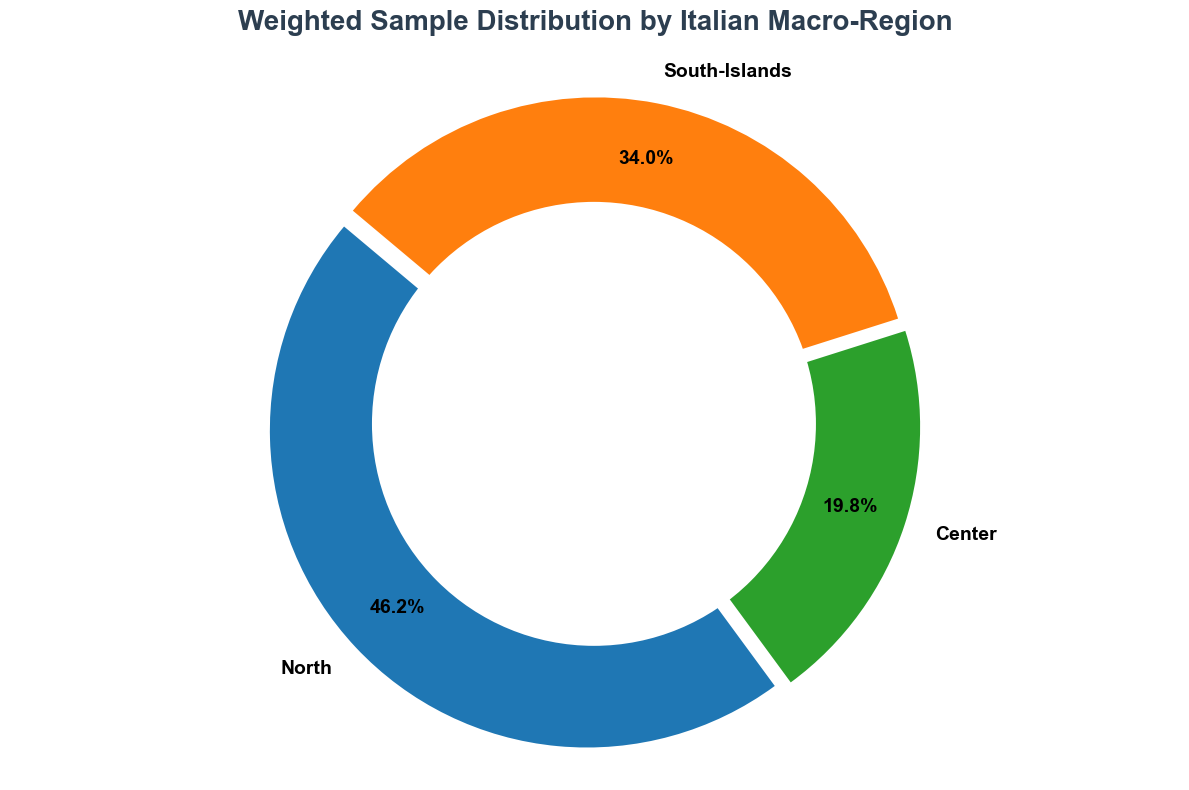

In [69]:
df_regional = prepare_regional_dataframe(df_analysis)

# Distribution by region
plot_region_distribution(df_regional)

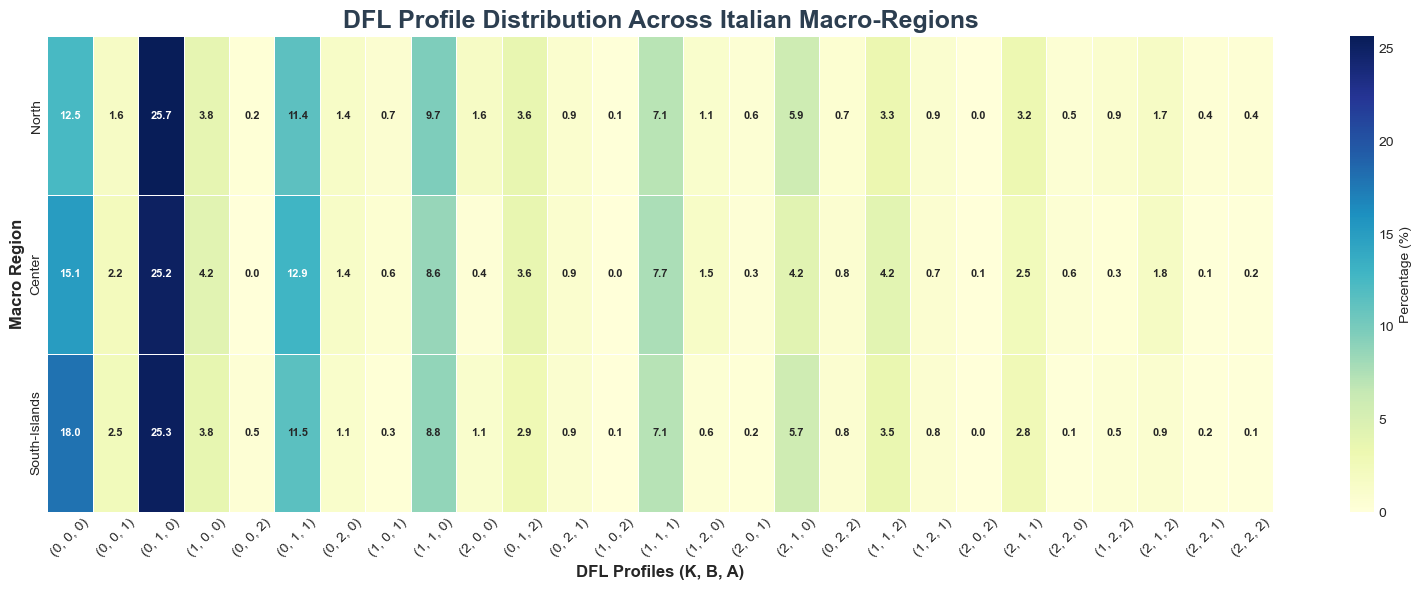

In [70]:
# Heatmap analysis
contingency_table, heatmap_data = (
    compute_profile_heatmap(df_regional)
)

plot_profile_heatmap(heatmap_data)

C:\Users\danie\AppData\Local\Temp\ipykernel_9088\2218870125.py:235: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




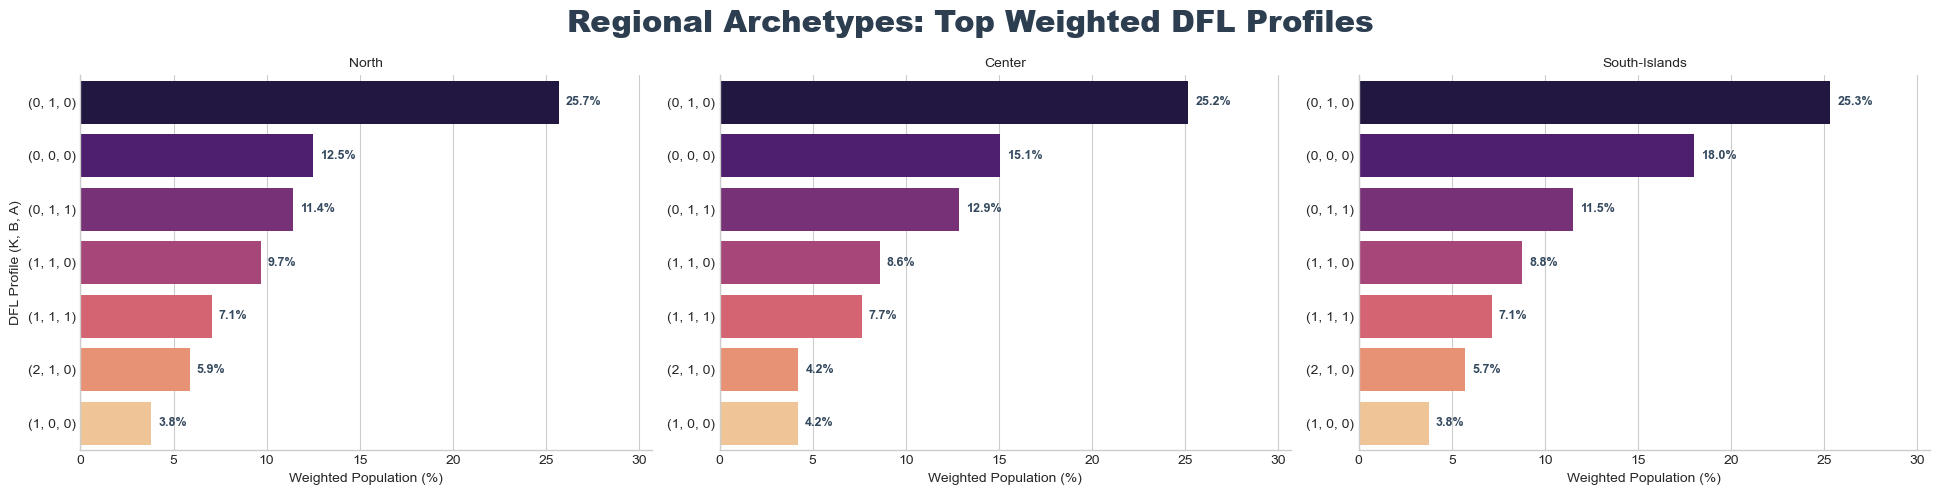

In [71]:
# Top profiles
weighted_profiles = compute_weighted_profiles(
    df_regional
)

plot_top_profiles(weighted_profiles)

C:\Users\danie\AppData\Local\Temp\ipykernel_9088\2218870125.py:302: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



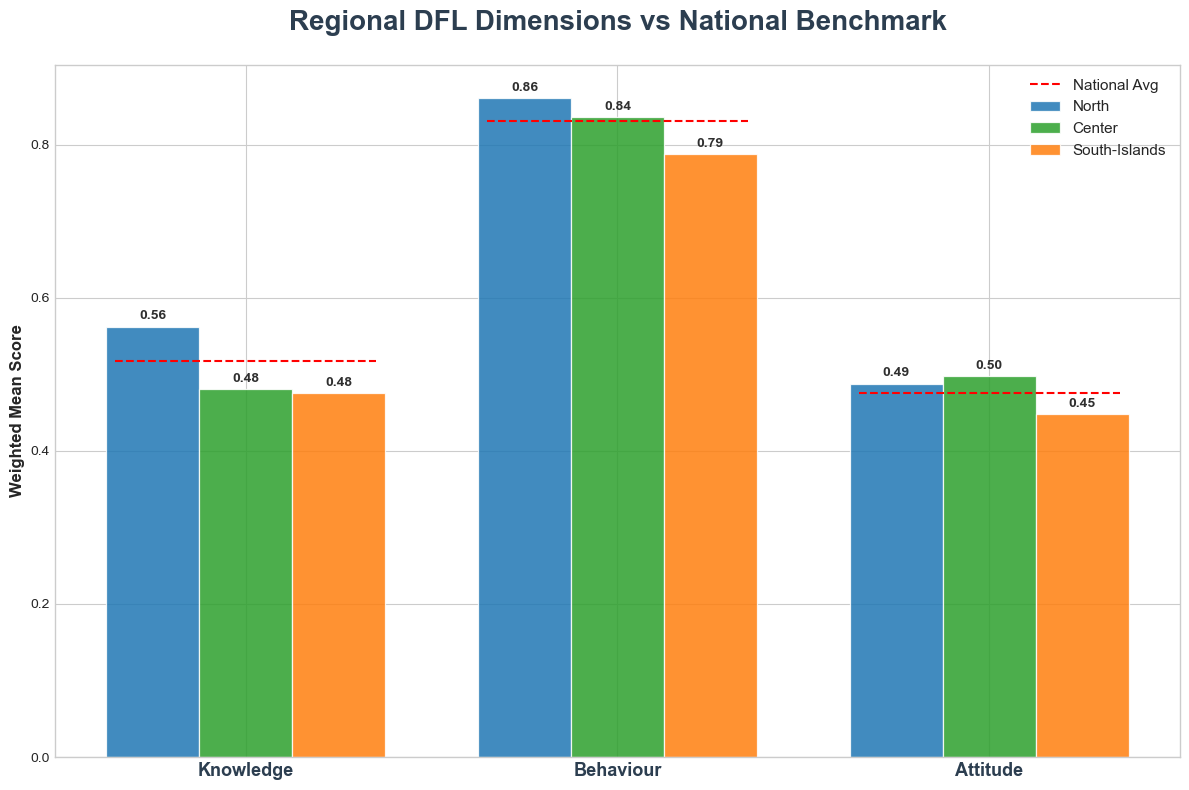

In [72]:
# Benchmark analysis
stats = compute_regional_statistics(
    df_regional
)

national_stats = compute_national_statistics(
    df_regional
)

plot_regional_vs_national(
    stats,
    national_stats
)

In [73]:
# Chi-square analysis
chi2, p, dof, expected, cramers_v = (
    chi_square_analysis(contingency_table)
)


--- Chi-Square Test: Region vs DFL Profile ---
Chi2 Statistic : 87.66
Degrees Freedom: 52
P-Value        : 1.4478e-03
Cramer's V     : 0.095

Conclusion:
Significant association between region and DFL profiles.
Effect size    : negligible


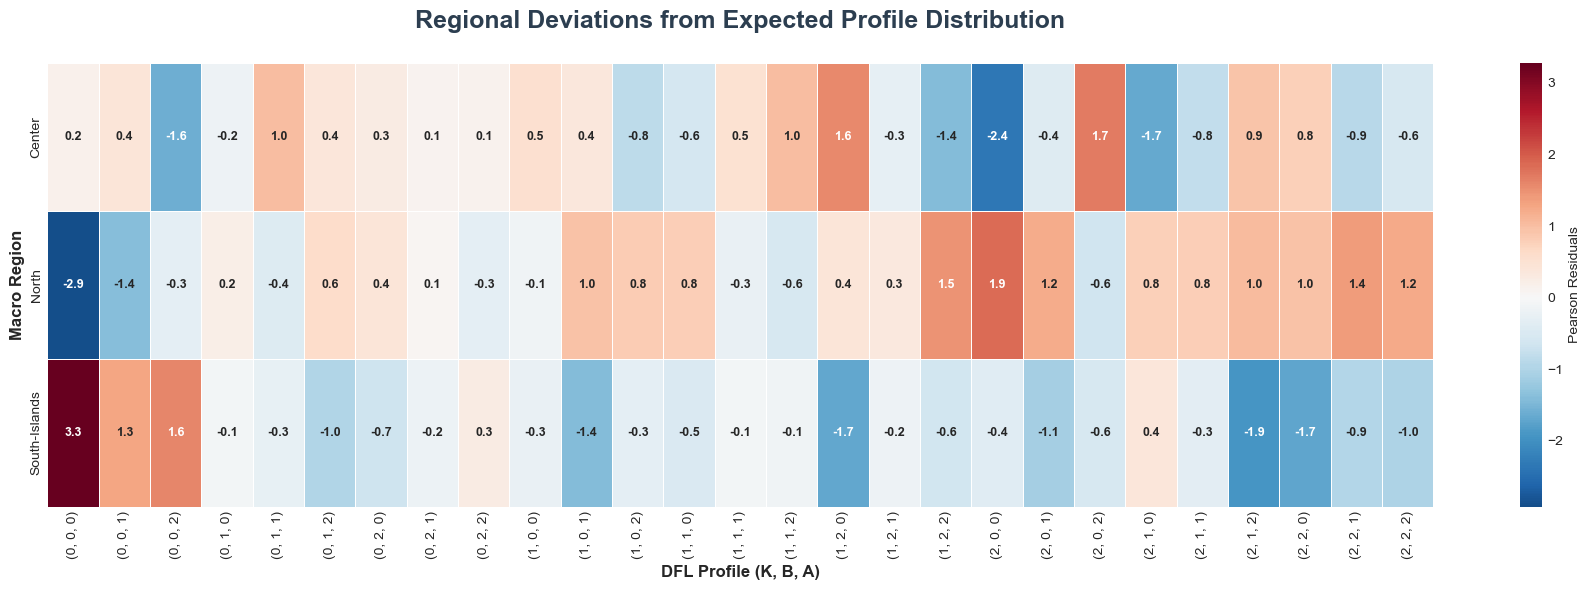

In [74]:
# Pearson residuals
plot_pearson_residuals(
    contingency_table,
    expected
)

### Generational gap

In [75]:
# Settings and visual style configuration
plt.style.use('seaborn-v0_8-whitegrid')

AGE_MAP = {
    0: 'Young',
    1: 'Adult',
    2: 'Senior'
}

AGE_ORDER = ['Young', 'Adult', 'Senior']


# Prepare age-based grouping variable
def prepare_age_dataframe(df):
    df_new = df.copy()
    df_new['age_group'] = df_new['age_class'].map(AGE_MAP)
    return df_new


# Plot weighted donut chart for distribution analysis
def plot_weighted_donut(
    data,
    labels,
    colors,
    title,
    center_title,
    explode=None
):

    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 8), facecolor='white')

    if explode is None:
        explode = [0.03] * len(labels)

    wedges, texts, autotexts = plt.pie(
        data,
        labels=labels,
        autopct=lambda p: f'{p:.1f}%',
        startangle=140,
        colors=colors,
        pctdistance=0.82,
        explode=explode,
        textprops={
            'fontsize': 14,
            'fontweight': 'bold',
            'color': 'black'
        }
    )

    for autotext in autotexts:
        autotext.set_color('black')
        autotext.set_weight('bold')
        autotext.set_fontsize(14)

    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)

    plt.text(
        0, 0,
        f'{center_title}',
        ha='center',
        va='center',
        fontsize=16,
        fontweight='bold',
        color='#333333'
    )

    plt.title(
        title,
        fontsize=20,
        fontweight='bold',
        pad=25,
        color='#2c3e50'
    )

    plt.axis('equal')
    plt.tight_layout()
    plt.show()


# Compute age group weighted distribution
def plot_age_distribution(df):

    age_weights = (
        df.groupby('age_group')['weight']
        .sum()
        .reindex(AGE_ORDER)
    )

    colors = ['#6C5CE7', '#00CEC9', '#FF7675']

    plot_weighted_donut(
        data=age_weights.values,
        labels=AGE_ORDER,
        colors=colors,
        title='Weighted Sample Distribution by Age Group',
        center_title=' '
    )


# Compute contingency table and percentage heatmap for age analysis
def compute_age_heatmap(df):

    contingency_table = pd.crosstab(
        df['age_group'],
        df['triple_scaled'].astype(str),
        values=df['weight'],
        aggfunc='sum'
    ).fillna(0)

    heatmap_data = (
        contingency_table
        .div(contingency_table.sum(axis=1), axis=0)
        * 100
    )

    heatmap_data = heatmap_data.reindex(AGE_ORDER)

    sorted_cols = sorted(
        heatmap_data.columns,
        key=lambda x: (
            sum(ast.literal_eval(x)),
            ast.literal_eval(x)
        )
    )

    heatmap_data = heatmap_data[sorted_cols]

    return contingency_table, heatmap_data


# Plot heatmap of age distribution across DFL profiles
def plot_age_heatmap(heatmap_data):

    plt.figure(figsize=(16, 6))

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".1f",
        cmap="YlGnBu",
        linewidths=0.5,
        annot_kws={"size": 9, "weight": "bold"},
        cbar_kws={'label': 'Percentage (%)'}
    )

    plt.title(
        "DFL Profile Distribution Across Age Groups",
        fontsize=20,
        fontweight='bold'
    )

    plt.xlabel("DFL profiles (K, B, A)", fontsize=12, fontweight='bold')
    plt.ylabel("Age group", fontsize=12, fontweight='bold')

    plt.xticks(rotation=45, fontsize=11)
    plt.yticks(fontsize=11)

    plt.tight_layout()
    plt.show()


# Compute top weighted profiles per age group
def compute_age_profiles(df):

    weighted_profiles = (
        df.groupby(['age_group', 'triple_scaled'])['weight']
        .sum()
        .reset_index()
    )

    weighted_profiles['Percentage'] = (
        weighted_profiles
        .groupby('age_group')['weight']
        .transform(lambda x: x / x.sum() * 100)
    )

    return weighted_profiles


# Plot top DFL profiles per age group
def plot_top_age_profiles(weighted_profiles, top_n=7):

    df_plot = (
        weighted_profiles
        .sort_values(['age_group', 'Percentage'], ascending=[True, False])
        .groupby('age_group')
        .head(top_n)
        .copy()
    )

    df_plot['Profile (K,B,A)'] = df_plot['triple_scaled'].astype(str)

    g = sns.catplot(
        data=df_plot,
        kind="bar",
        x="Percentage",
        y="Profile (K,B,A)",
        col="age_group",
        col_order=AGE_ORDER,
        palette="magma",
        sharey=False,
        height=5,
        aspect=1.3
    )

    g.set_axis_labels("Weighted population (%)", "DFL profile (K,B,A)")
    g.set_titles("{col_name}")

    for ax in g.axes.flat:
        ax.set_xlim(0, df_plot['Percentage'].max() + 5)

        for p in ax.patches:
            ax.annotate(
                f'{p.get_width():.1f}%',
                (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left',
                va='center',
                xytext=(5, 0),
                textcoords='offset points',
                fontsize=10,
                fontweight='bold',
                color='#34495e'
            )

    plt.subplots_adjust(top=0.88)
    g.fig.suptitle(
        "Generational Archetypes: Top Weighted DFL Profiles",
        fontsize=22,
        fontweight='bold'
    )

    plt.tight_layout()
    plt.show()


# Compute weighted statistics by age group
def compute_age_statistics(df):

    temp = pd.DataFrame(
        df['triple_scaled'].tolist(),
        columns=['Knowledge', 'Behaviour', 'Attitude']
    )

    temp['age_group'] = df['age_group']
    temp['weight'] = df['weight']

    stats = temp.groupby('age_group').apply(
        lambda x: pd.Series({
            'Knowledge': np.average(x['Knowledge'], weights=x['weight']),
            'Behaviour': np.average(x['Behaviour'], weights=x['weight']),
            'Attitude': np.average(x['Attitude'], weights=x['weight'])
        })
    )

    return stats.reindex(AGE_ORDER)


# Compute national weighted benchmark for age analysis
def compute_national_age_stats(df):

    temp = pd.DataFrame(
        df['triple_scaled'].tolist(),
        columns=['Knowledge', 'Behaviour', 'Attitude']
    )

    temp['weight'] = df['weight']

    return {
        'Knowledge': np.average(temp['Knowledge'], weights=temp['weight']),
        'Behaviour': np.average(temp['Behaviour'], weights=temp['weight']),
        'Attitude': np.average(temp['Attitude'], weights=temp['weight'])
    }


# Plot comparison between age groups and national benchmark
def plot_age_vs_national(stats, national_stats):

    colors = ['#6C5CE7', '#00CEC9', '#FF7675']
    labels = ['Knowledge', 'Behaviour', 'Attitude']

    x = np.arange(len(labels))
    width = 0.25

    fig, ax = plt.subplots(figsize=(12, 8))

    for i, age in enumerate(stats.index):

        bars = ax.bar(
            x + i * width,
            stats.loc[age],
            width,
            label=age,
            color=colors[i]
        )

        ax.bar_label(bars, fmt='%.2f', fontsize=11, fontweight='bold')

    for i, label in enumerate(labels):
        ax.hlines(
            y=national_stats[label],
            xmin=i - 0.1,
            xmax=i + width * 2 + 0.1,
            color='red',
            linestyle='--',
            linewidth=1.5
        )

    ax.set_xticks(x + width)
    ax.set_xticklabels(labels, fontsize=12, fontweight='bold')

    ax.set_title(
        "Generational DFL Gap vs National Benchmark",
        fontsize=18,
        fontweight='bold'
    )

    ax.legend()
    plt.tight_layout()
    plt.show()


# Perform chi-square test and effect size analysis
def chi_square_age_analysis(contingency_table):

    chi2, p, dof, expected = chi2_contingency(contingency_table)

    print("\n--- Chi-square test: age vs dfl profile ---")
    print(f"Chi2 statistic : {chi2:.2f}")
    print(f"Degrees freedom: {dof}")
    print(f"P-value        : {p:.4e}")

    n = contingency_table.to_numpy().sum()

    cramers_v = np.sqrt(
        chi2 / (n * (min(contingency_table.shape) - 1))
    )

    print(f"Cramer's V     : {cramers_v:.3f}")

    print("\n--- interpretation ---")

    if p < 0.05:
        print("significant association between age and dfl profiles.")
    else:
        print("no significant association between age and dfl profiles.")

    if cramers_v < 0.1:
        effect = "negligible"
    elif cramers_v < 0.2:
        effect = "weak"
    elif cramers_v < 0.3:
        effect = "moderate"
    else:
        effect = "strong"

    print(f"effect size    : {effect}")

    return chi2, p, dof, expected, cramers_v


# Plot Pearson residuals from chi-square expected values
def plot_age_residuals(contingency_table, expected):

    residuals = (contingency_table - expected) / np.sqrt(expected)

    plt.figure(figsize=(18, 6))

    sns.heatmap(
        residuals,
        annot=True,
        fmt=".1f",
        cmap="RdBu_r",
        center=0,
        linewidths=0.5,
        cbar_kws={'label': 'Pearson residuals'}
    )

    plt.title(
        "Generational Deviations from Expected Profile Distribution",
        fontsize=18,
        fontweight='bold'
    )

    plt.xlabel("DFL profiles (K, B, A)")
    plt.ylabel("Age group")

    plt.tight_layout()
    plt.show()

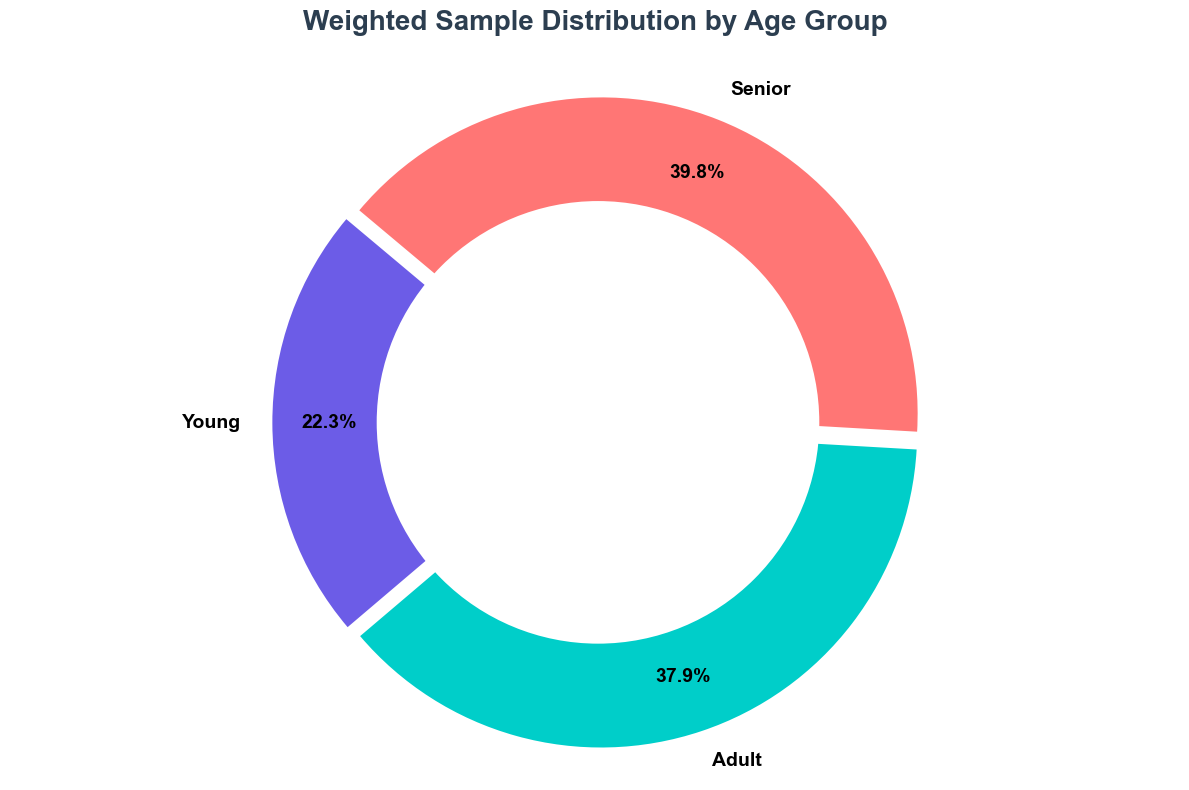

In [76]:
df_age = prepare_age_dataframe(df_analysis)
plot_age_distribution(df_age)

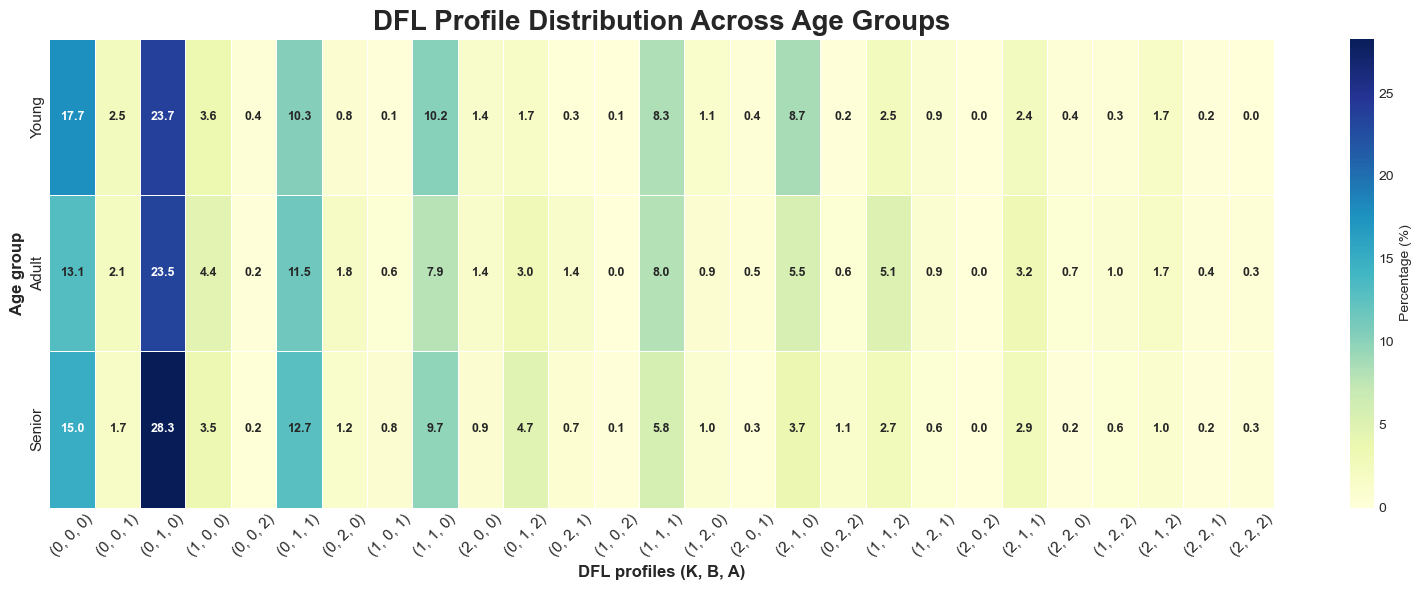

In [77]:
contingency_table, heatmap_data = compute_age_heatmap(df_age)
plot_age_heatmap(heatmap_data)

C:\Users\danie\AppData\Local\Temp\ipykernel_9088\1536925328.py:197: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




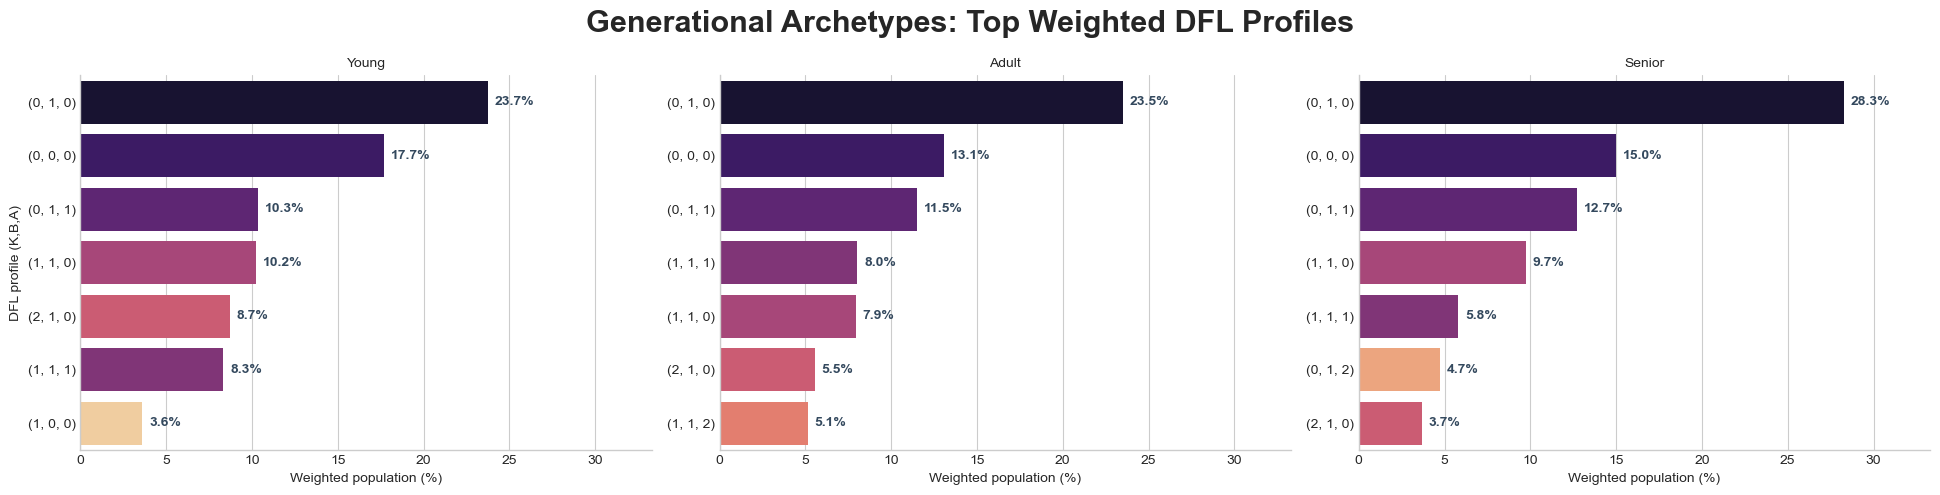

In [78]:
weighted_profiles = compute_age_profiles(df_age)
plot_top_age_profiles(weighted_profiles)

C:\Users\danie\AppData\Local\Temp\ipykernel_9088\1536925328.py:251: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



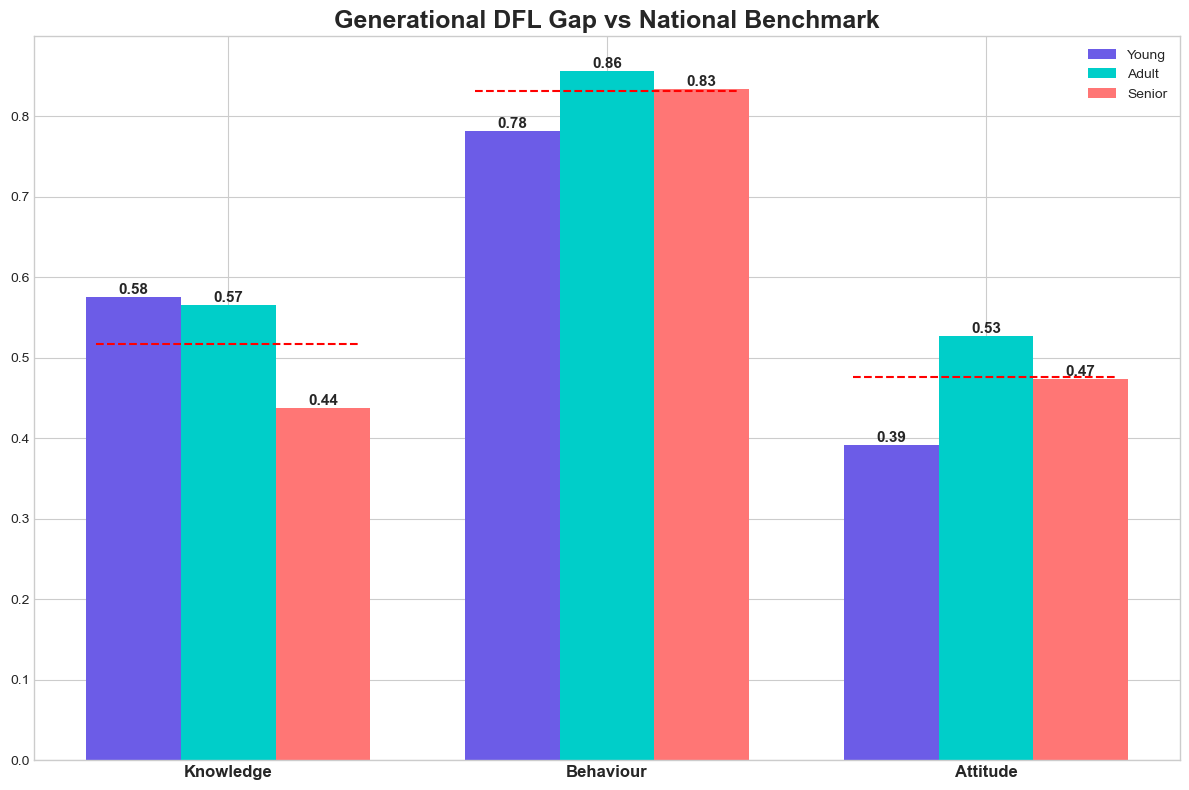

In [79]:
stats = compute_age_statistics(df_age)
national_stats = compute_national_age_stats(df_age)

plot_age_vs_national(stats, national_stats)

In [80]:
chi2, p, dof, expected, cramers_v = chi_square_age_analysis(contingency_table)


--- Chi-square test: age vs dfl profile ---
Chi2 statistic : 177.09
Degrees freedom: 52
P-value        : 1.4956e-15
Cramer's V     : 0.135

--- interpretation ---
significant association between age and dfl profiles.
effect size    : weak


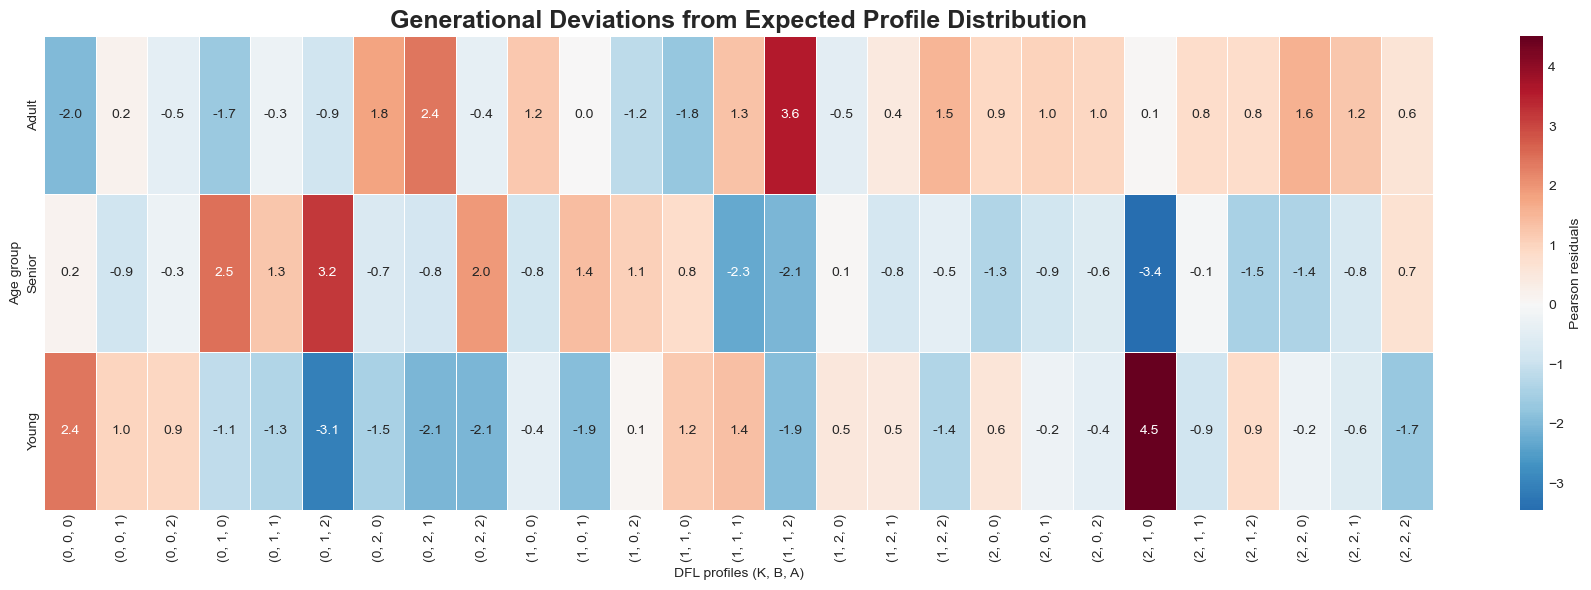

In [81]:
plot_age_residuals(contingency_table, expected)

### Educational Level

In [82]:
# Settings and visual configuration for plots
plt.style.use('seaborn-v0_8-whitegrid')

EDU_MAP = {
    0: 'Low',
    1: 'Medium',
    2: 'High'
}

EDU_ORDER = [
    'Low',
    'Medium',
    'High'
]

# Prepare dataframe by mapping numerical levels into categorical groups
def prepare_education_dataframe(df):

    df_new = df.copy()
    df_new['edu_group'] = df_new['education_level'].map(EDU_MAP)

    return df_new


# Create a weighted donut chart to visualize proportional distributions
def plot_weighted_donut(
    data,
    labels,
    colors,
    title,
    center_title,
    explode=None
):

    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 8), facecolor='white')

    if explode is None:
        explode = [0.03] * len(labels)

    wedges, texts, autotexts = plt.pie(
        data,
        labels=labels,
        autopct=lambda p: f'{p:.1f}%',
        startangle=140,
        colors=colors,
        pctdistance=0.82,
        explode=explode,
        textprops={
            'fontsize': 14,
            'fontweight': 'bold',
            'color': 'black'
        }
    )

    for autotext in autotexts:
        autotext.set_color('black')
        autotext.set_weight('bold')
        autotext.set_fontsize(14)

    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)

    plt.text(
        0, 0,
        f'{center_title}',
        ha='center',
        va='center',
        fontsize=16,
        fontweight='bold',
        color='#333333'
    )

    plt.title(
        title,
        fontsize=20,
        fontweight='bold',
        pad=25,
        color='#2c3e50'
    )

    plt.axis('equal')
    plt.tight_layout()
    plt.show()


# Plot weighted distribution of education groups in the sample
def plot_education_distribution(df):

    edu_weights = (
        df.groupby('edu_group')['weight']
        .sum()
        .reindex(EDU_ORDER)
    )

    colors = ['#3498db', '#f1c40f', '#e74c3c']

    plot_weighted_donut(
        data=edu_weights.values,
        labels=EDU_ORDER,
        colors=colors,
        title='Weighted Sample Distribution by Education Level',
        center_title=' '
    )


# Compute contingency table and normalized heatmap for education vs DFL profiles
def compute_education_heatmap(df):

    contingency_table = pd.crosstab(
        df['edu_group'],
        df['triple_scaled'].astype(str),
        values=df['weight'],
        aggfunc='sum'
    ).fillna(0)

    heatmap_data = (
        contingency_table
        .div(contingency_table.sum(axis=1), axis=0)
        * 100
    )

    heatmap_data = heatmap_data.reindex(EDU_ORDER)

    sorted_cols = sorted(
        heatmap_data.columns,
        key=lambda x: (
            sum(ast.literal_eval(x)),
            ast.literal_eval(x)
        )
    )

    heatmap_data = heatmap_data[sorted_cols]

    return contingency_table, heatmap_data


# Visualize percentage distribution of DFL profiles across education groups
def plot_education_heatmap(heatmap_data):

    plt.figure(figsize=(16, 6))
    heatmap_data_inverted = heatmap_data.iloc[::-1]

    sns.heatmap(
        heatmap_data_inverted,
        annot=True,
        fmt=".1f",
        cmap="YlGnBu",
        linewidths=0.5,
        annot_kws={"size": 8, "weight": "bold"},
        cbar_kws={'label': 'percentage (%)'}
    )

    plt.title(
        "Distribution of DFL Profiles Across Education Levels",
        fontsize=18,
        fontweight='bold',
        color='#2c3e50'
    )

    plt.xlabel("DFL Profiles (K, B, A)")
    plt.ylabel("Education Level")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# Compute top weighted DFL profiles per education group
def compute_education_profiles(df):

    weighted_profiles = (
        df.groupby(['edu_group', 'triple_scaled'])['weight']
        .sum()
        .reset_index()
    )

    weighted_profiles['Percentage'] = (
        weighted_profiles
        .groupby('edu_group')['weight']
        .transform(lambda x: x / x.sum() * 100)
    )

    return weighted_profiles


# Plot most representative DFL profiles per education group
def plot_top_education_profiles(weighted_profiles, top_n=7):

    df_plot = (
        weighted_profiles
        .sort_values(['edu_group', 'Percentage'], ascending=[True, False])
        .groupby('edu_group')
        .head(top_n)
        .copy()
    )

    df_plot['Profile (K,B,A)'] = df_plot['triple_scaled'].astype(str)

    g = sns.catplot(
        data=df_plot,
        kind="bar",
        x="Percentage",
        y="Profile (K,B,A)",
        col="edu_group",
        col_order=EDU_ORDER,
        palette="magma",
        sharey=False,
        height=5,
        aspect=1.3
    )

    g.set_axis_labels("Weighted Population (%)", "DFL Profile (K, B, A)")
    g.set_titles("{col_name}")

    for ax in g.axes.flat:
        ax.set_xlim(0, df_plot['Percentage'].max() + 5)

        for p in ax.patches:
            ax.annotate(
                f'{p.get_width():.1f}%',
                (p.get_width(), p.get_y() + p.get_height()/2),
                ha='left',
                va='center',
                xytext=(5, 0),
                textcoords='offset points',
                fontsize=9,
                fontweight='bold',
                color='#34495e'
            )

    plt.subplots_adjust(top=0.88)
    g.fig.suptitle(
        "Educational Archetypes: Top Weighted DFL Profiles",
        fontsize=22,
        fontweight='900',
        color='#2c3e50'
    )

    plt.tight_layout()
    plt.show()


# Compute weighted average of DFL dimensions by education group
def compute_education_statistics(df):

    temp = pd.DataFrame(
        df['triple_scaled'].tolist(),
        columns=['Knowledge', 'Behaviour', 'Attitude']
    )

    temp['edu_group'] = df['edu_group']
    temp['weight'] = df['weight']

    stats = temp.groupby('edu_group').apply(
        lambda x: pd.Series({
            'Knowledge': np.average(x['Knowledge'], weights=x['weight']),
            'Behaviour': np.average(x['Behaviour'], weights=x['weight']),
            'Attitude': np.average(x['Attitude'], weights=x['weight'])
        })
    )

    return stats.reindex(EDU_ORDER)


# Compute national weighted averages of DFL dimensions
def compute_national_education_stats(df):

    temp = pd.DataFrame(
        df['triple_scaled'].tolist(),
        columns=['Knowledge', 'Behaviour', 'Attitude']
    )

    temp['weight'] = df['weight']

    return {
        'Knowledge': np.average(temp['Knowledge'], weights=temp['weight']),
        'Behaviour': np.average(temp['Behaviour'], weights=temp['weight']),
        'Attitude': np.average(temp['Attitude'], weights=temp['weight'])
    }


# Compare education groups against national benchmark
def plot_education_vs_national(stats, national_stats):

    colors = ['#3498db', '#f1c40f', '#e74c3c']
    labels = ['Knowledge', 'Behaviour', 'Attitude']

    x = np.arange(len(labels))
    width = 0.25

    fig, ax = plt.subplots(figsize=(12, 8))

    for i, edu in enumerate(stats.index):

        bars = ax.bar(
            x + i * width,
            stats.loc[edu],
            width,
            label=edu,
            color=colors[i]
        )

        ax.bar_label(bars, fmt='%.2f', fontsize=10, fontweight='bold')

    for i, label in enumerate(labels):
        ax.hlines(
            y=national_stats[label],
            xmin=i - 0.1,
            xmax=i + width * 2 + 0.1,
            color='red',
            linestyle='--',
            linewidth=1.5
        )

    ax.set_xticks(x + width)
    ax.set_xticklabels(labels, fontweight='bold')

    ax.set_title(
        "Educational DFL Gap vs National Benchmark",
        fontsize=18,
        fontweight='bold'
    )

    ax.legend()
    plt.tight_layout()
    plt.show()


# Perform chi-square test of independence between education and DFL profiles
def chi_square_education_analysis(contingency_table):

    chi2, p, dof, expected = chi2_contingency(contingency_table)

    print("\n--- chi-square test: education vs dfl profile ---")
    print(f"chi2 statistic : {chi2:.2f}")
    print(f"degrees freedom: {dof}")
    print(f"p-value        : {p:.4e}")

    n = contingency_table.to_numpy().sum()

    cramers_v = np.sqrt(
        chi2 / (n * (min(contingency_table.shape) - 1))
    )

    print(f"cramer's v     : {cramers_v:.3f}")

    print("\n--- interpretation ---")

    if p < 0.05:
        print("significant association between education and dfl profiles.")
    else:
        print("no significant association between education and dfl profiles.")

    if cramers_v < 0.1:
        effect = "negligible"
    elif cramers_v < 0.2:
        effect = "weak"
    elif cramers_v < 0.3:
        effect = "moderate"
    else:
        effect = "strong"

    print(f"effect size    : {effect}")

    return chi2, p, dof, expected, cramers_v


# Compute Pearson residuals and visualize deviations from expected counts
def plot_education_residuals(contingency_table, expected):

    contingency_table = contingency_table.reindex(EDU_ORDER)
    expected = pd.DataFrame(
        expected,
        index=contingency_table.index,
        columns=contingency_table.columns
    )

    residuals = (contingency_table - expected) / np.sqrt(expected)
    residuals_inverted = residuals[::-1]

    plt.figure(figsize=(18, 6))

    sns.heatmap(
        residuals_inverted,
        annot=True,
        fmt=".1f",
        cmap="RdBu_r",
        center=0,
        linewidths=0.5,
        annot_kws={'size': 12},
        cbar_kws={'label': 'Pearson Residuals'}
    )

    plt.title(
        "Educational Deviations from Expected Profile Distribution",
        fontsize=18,
        fontweight='bold'
    )

    plt.xlabel("DFL Profiles (K, B, A)")
    plt.ylabel("Education Level")

    plt.tight_layout()
    plt.show()

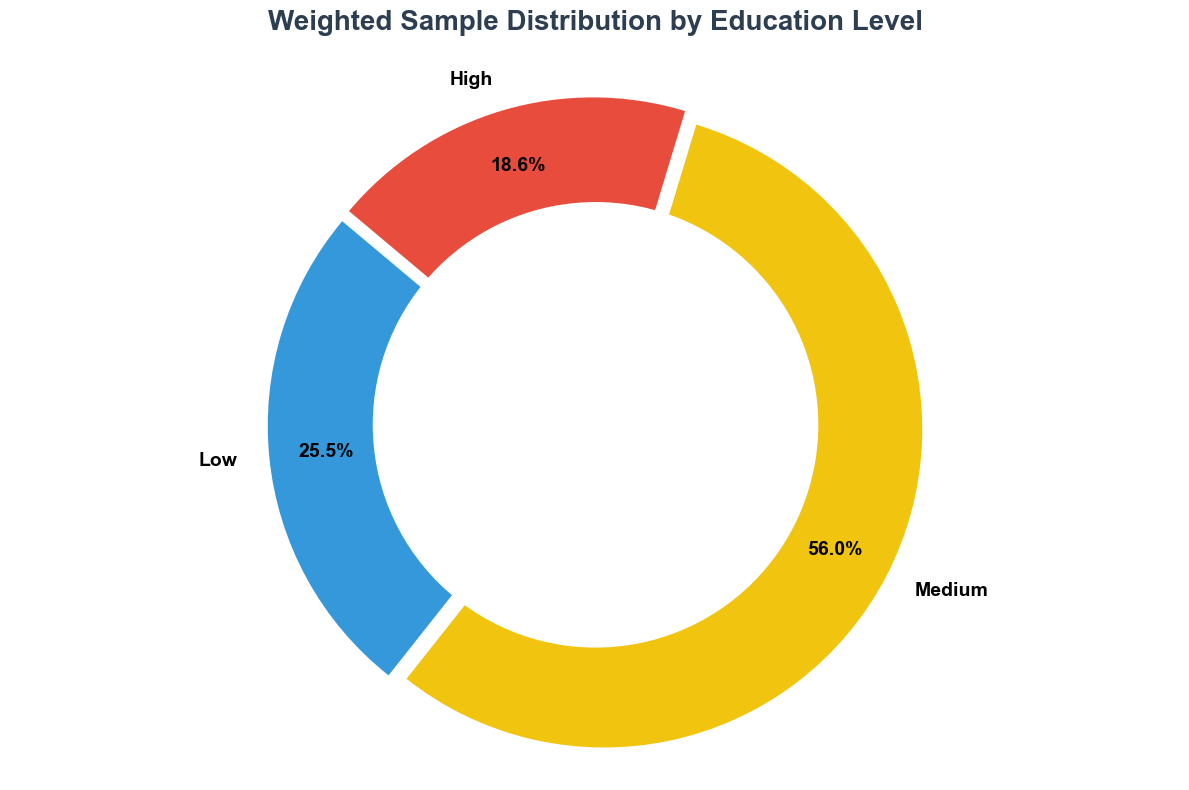

In [83]:
df_edu = prepare_education_dataframe(df_analysis)

# Distribution
plot_education_distribution(df_edu)

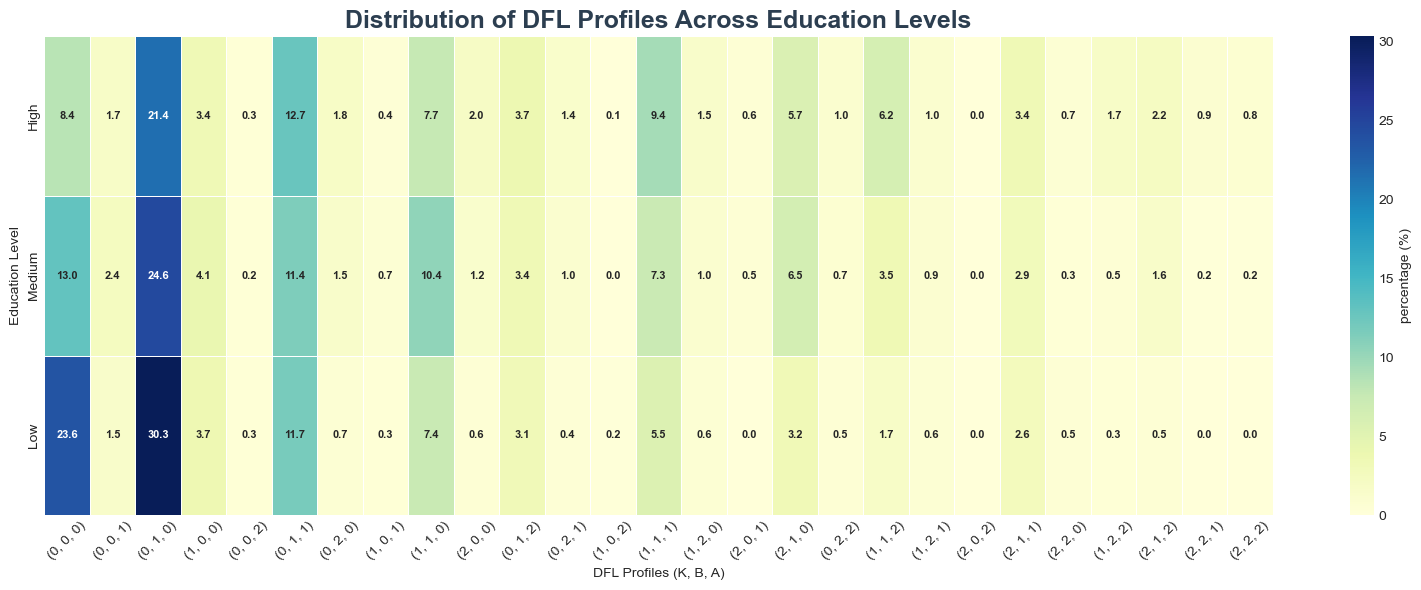

In [84]:
# Heatmap
contingency_table, heatmap_data = compute_education_heatmap(df_edu)
plot_education_heatmap(heatmap_data)

C:\Users\danie\AppData\Local\Temp\ipykernel_9088\4142284583.py:202: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




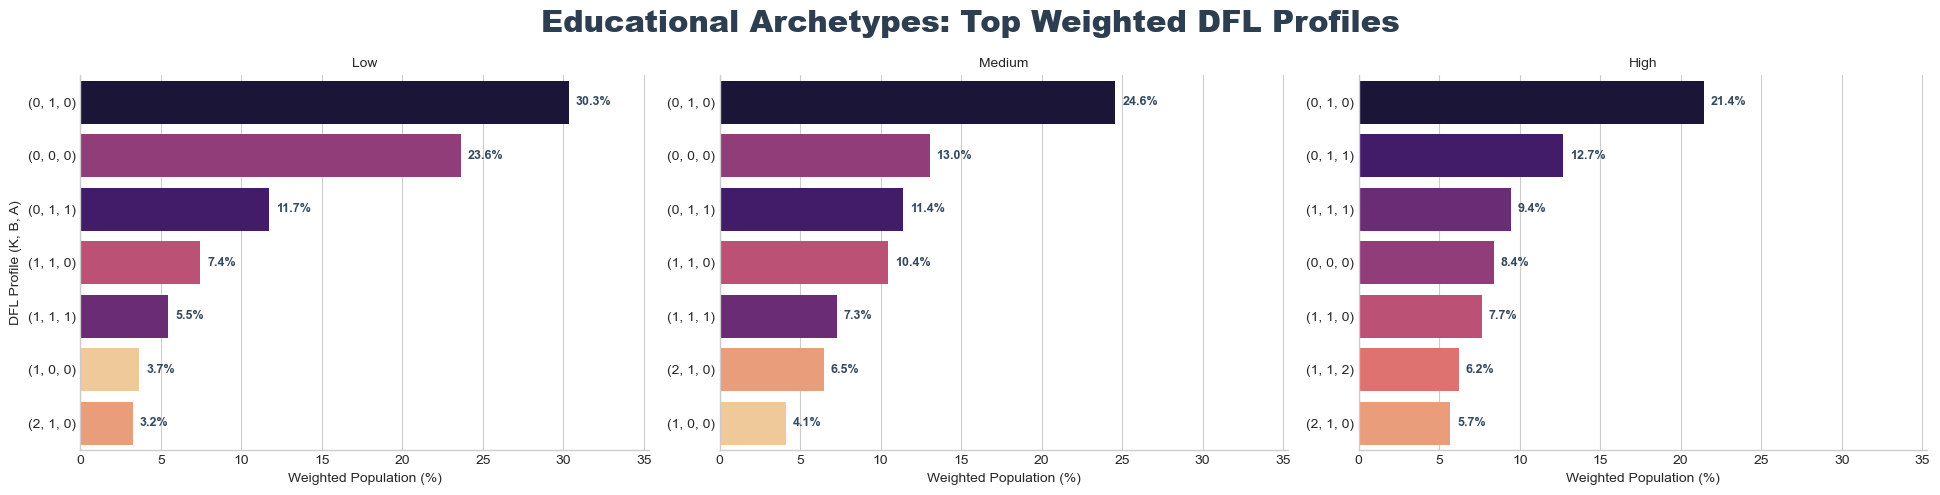

In [85]:
# Top profiles
weighted_profiles = compute_education_profiles(df_edu)
plot_top_education_profiles(weighted_profiles)

C:\Users\danie\AppData\Local\Temp\ipykernel_9088\4142284583.py:257: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



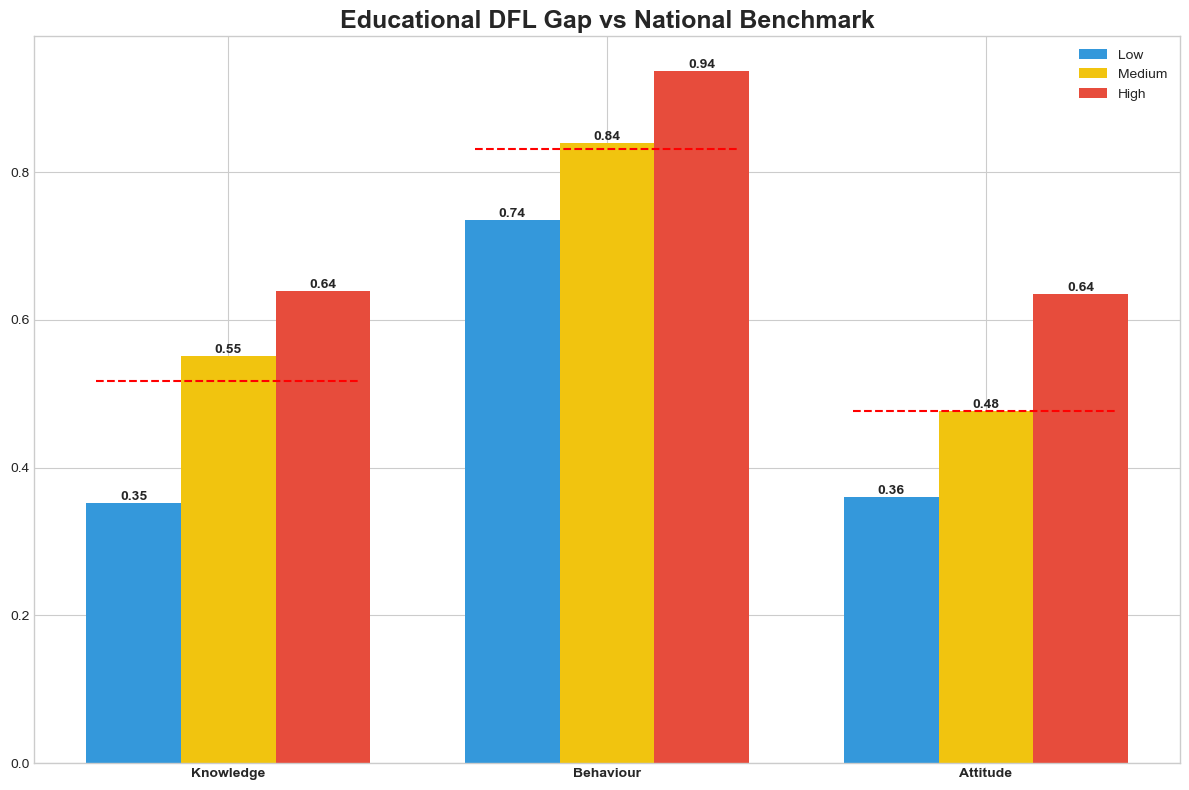

In [86]:
# Benchmark (gap analysis)
stats = compute_education_statistics(df_edu)
national_stats = compute_national_education_stats(df_edu)

plot_education_vs_national(stats, national_stats)

In [87]:
# Chi-square Test
chi2, p, dof, expected, cramers_v = chi_square_education_analysis(contingency_table)


--- chi-square test: education vs dfl profile ---
chi2 statistic : 294.10
degrees freedom: 52
p-value        : 1.6362e-35
cramer's v     : 0.174

--- interpretation ---
significant association between education and dfl profiles.
effect size    : weak


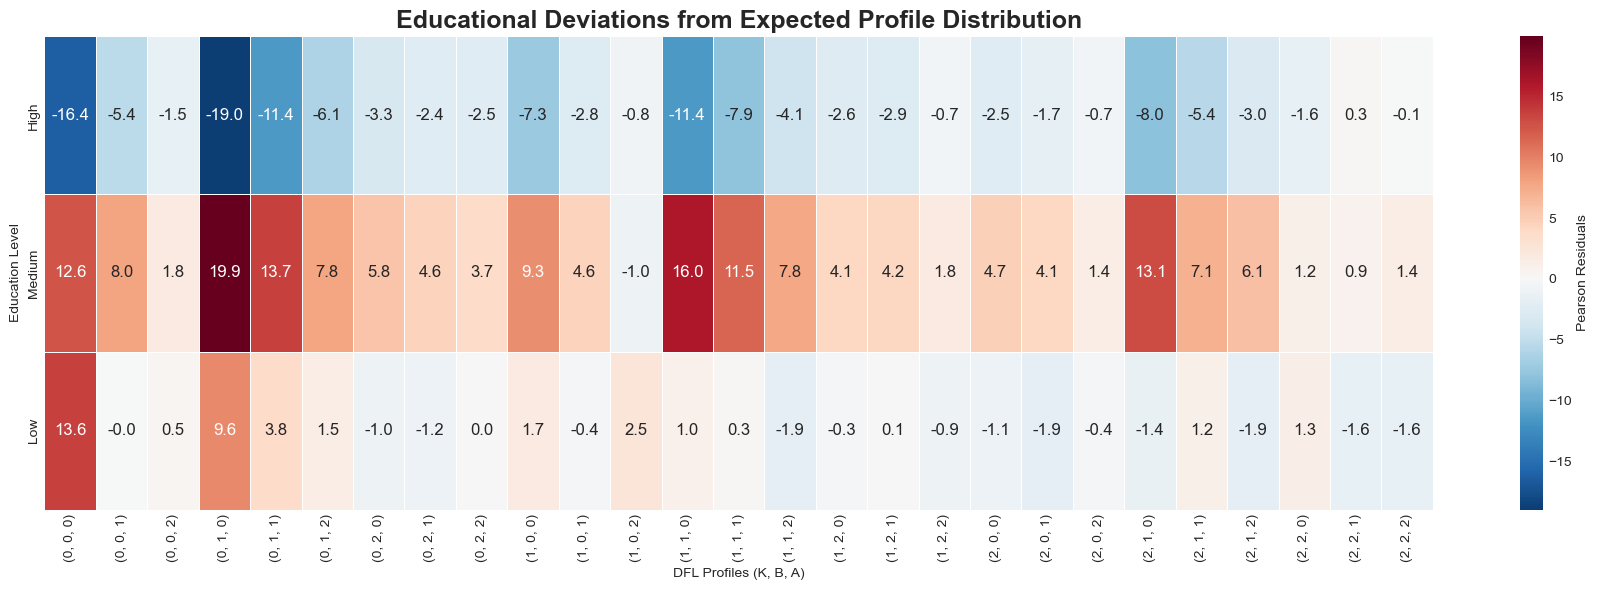

In [88]:
# Residuals
plot_education_residuals(contingency_table, expected)

### Multivariate Analysis

In [89]:
# Estimates a logistic regression to see what increases or decreases the probability of belonging to a certain profile (e.g. (0,0,0)) and then displays it with a forest plot
def run_logit_forest_plot(df, profile=(0, 0, 0)):

    df_model = df.copy()

    df_model = prepare_regional_dataframe(df_model)
    df_model = prepare_age_dataframe(df_model)
    df_model = prepare_education_dataframe(df_model)

    df_model['is_target_profile'] = (
        df_model['triple_scaled'] == profile).astype(int)

    df_model['macro_region'] = pd.Categorical(
        df_model['macro_region'], 
        categories=['North', 'Center', 'South-Islands']
    )
    df_model['age_group'] = pd.Categorical(
        df_model['age_group'], categories=['Young', 'Adult', 'Senior']
    )
    df_model['edu_group'] = pd.Categorical(
        df_model['edu_group'], categories=['High', 'Medium', 'Low']
    )

    model = smf.glm(
        formula="is_target_profile ~ macro_region + age_group + edu_group",
        data=df_model,
        family=sm.families.Binomial()
    ).fit(freq_weights=df_model['weight'])

    results = pd.DataFrame({
        'Coefficient': model.params,
        'P-Value': model.pvalues,
        'Odds Ratio (OR)': np.exp(model.params),
        'CI 2.5%': np.exp(model.conf_int()[0]),
        'CI 97.5%': np.exp(model.conf_int()[1])
    })

    print("\n--- WEIGHTED LOGISTIC REGRESSION ---")
    print(results.round(3))

    or_df = results.copy()
    if 'Intercept' in or_df.index:
        or_df = or_df.drop(index='Intercept')

    or_df = or_df.sort_values('Odds Ratio (OR)')

    # Style
    
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 7), dpi=150)

    y_pos = np.arange(len(or_df))

    or_values = or_df['Odds Ratio (OR)'].values
    ci_low = or_df['CI 2.5%'].values
    ci_high = or_df['CI 97.5%'].values
    p_values = or_df['P-Value'].values

    # Clean labels
    clean_labels = [
        str(idx)
        .replace('macro_region[T.', 'Region: ')
        .replace('age_group[T.', 'Age: ')
        .replace('edu_group[T.', 'Education: ')
        .replace(']', '')
        for idx in or_df.index
    ]

    # Colors
    colors = []
    for or_val, p_val in zip(or_values, p_values):
        if p_val > 0.05:
            colors.append('#B0B0B0')
        elif or_val > 1:
            colors.append('#1f77b4')
        else:
            colors.append('#d62728')

    # Plot
    for i in range(len(or_df)):

        ax.errorbar(
            or_values[i],
            y_pos[i],
            xerr=[[or_values[i] - ci_low[i]], [ci_high[i] - or_values[i]]],
            fmt='o',
            color=colors[i],
            ecolor=colors[i],
            elinewidth=2.5,
            capsize=3,
            markersize=9,
            markeredgecolor='white'
        )

        # Safe annotation
        ax.text(
            ci_high[i] * 1.05,
            y_pos[i],
            f"{or_values[i]:.2f} [{ci_low[i]:.2f}-{ci_high[i]:.2f}]",
            va='center',
            fontsize=10,
            color='#333333'
        )

    # Reference line
    ax.axvline(1, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

    ax.set_xscale('linear')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(clean_labels, fontsize=11)

    ax.set_xlabel("Odds Ratio", fontsize=12, fontweight='bold')

    ax.set_title(
        f"Logistic Regression – Profile {profile}",
        fontsize=16,
        fontweight='bold'
    )

    ax.grid(axis='x', alpha=0.3)
    ax.grid(axis='y', alpha=0)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.show()

    return model, results


--- WEIGHTED LOGISTIC REGRESSION ---
                               Coefficient  P-Value  Odds Ratio (OR)  CI 2.5%  \
Intercept                           -2.430    0.000            0.088    0.066   
macro_region[T.Center]               0.273    0.022            1.314    1.040   
macro_region[T.South-Islands]        0.390    0.000            1.477    1.220   
age_group[T.Adult]                  -0.247    0.035            0.781    0.620   
age_group[T.Senior]                 -0.465    0.000            0.628    0.496   
edu_group[T.Medium]                  0.512    0.000            1.669    1.288   
edu_group[T.Low]                     1.382    0.000            3.983    2.919   

                               CI 97.5%  
Intercept                         0.118  
macro_region[T.Center]            1.659  
macro_region[T.South-Islands]     1.788  
age_group[T.Adult]                0.983  
age_group[T.Senior]               0.795  
edu_group[T.Medium]               2.162  
edu_group[T.Low]   

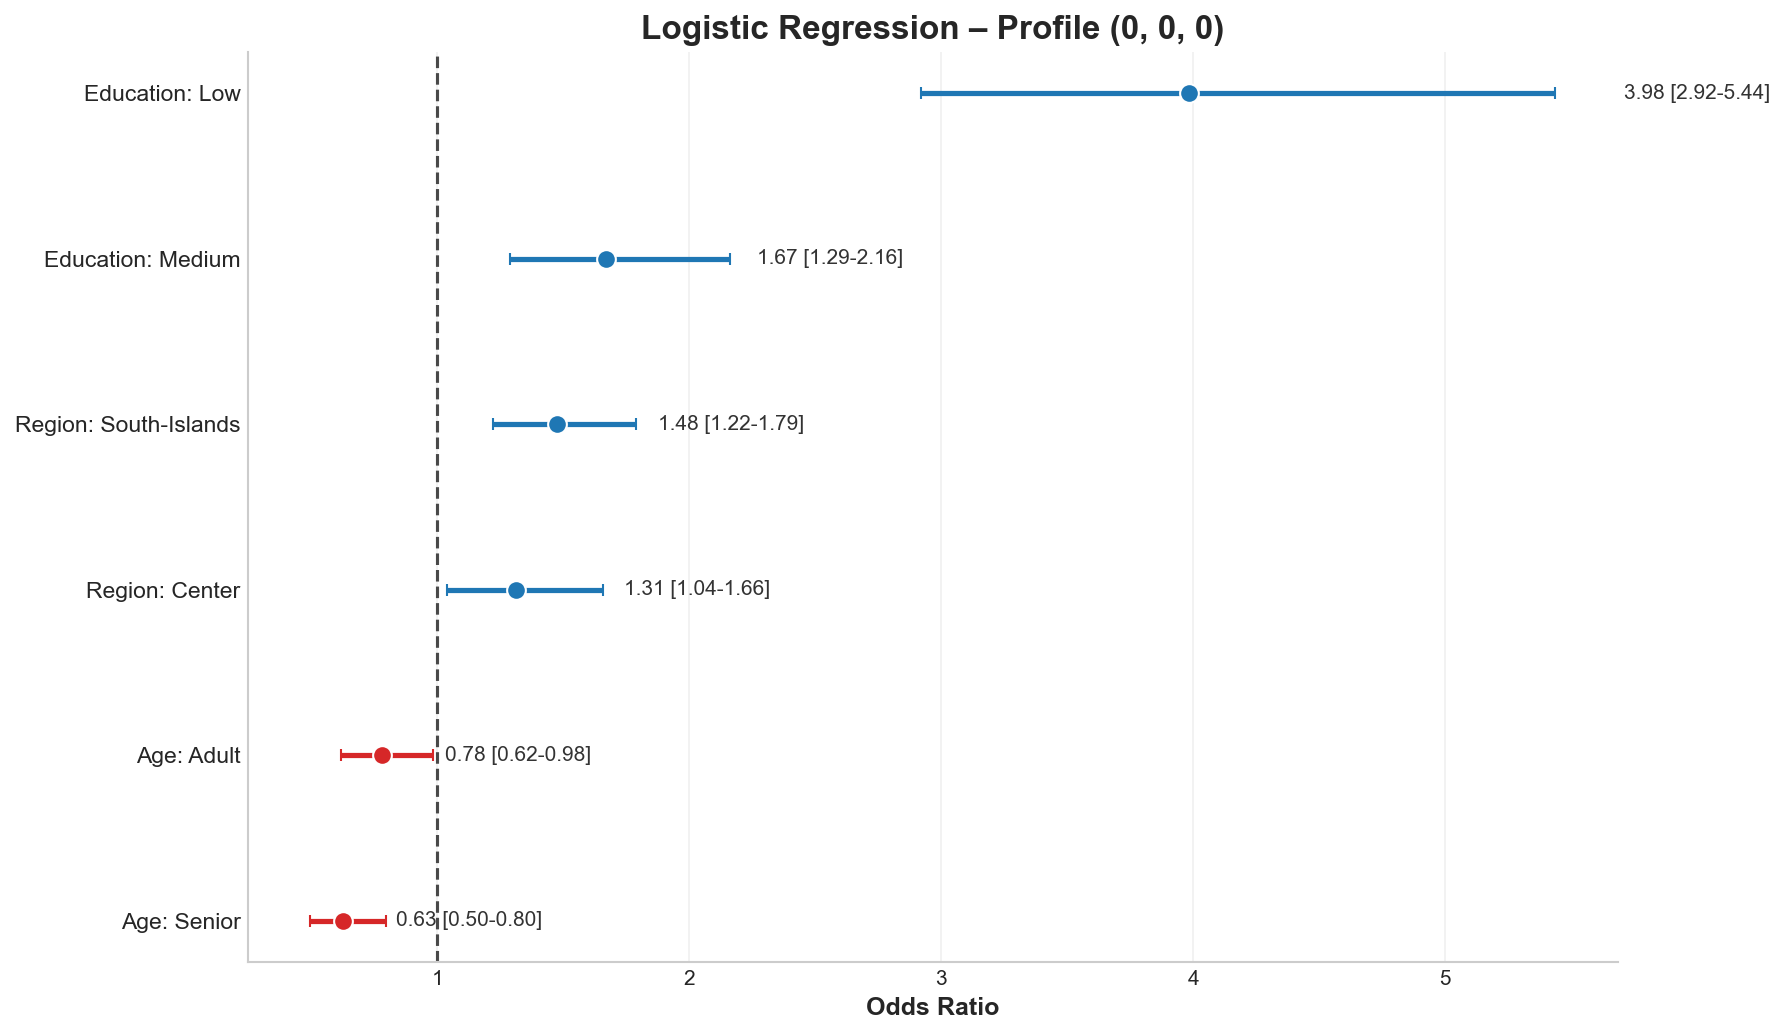

In [90]:
model, table = run_logit_forest_plot(df_analysis, profile=(0, 0, 0))

c:\Users\danie\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

overflow encountered in exp




--- WEIGHTED LOGISTIC REGRESSION ---
                               Coefficient  P-Value  Odds Ratio (OR)  CI 2.5%  \
Intercept                          -26.148    0.999     0.000000e+00    0.000   
macro_region[T.Center]              -0.768    0.319     4.640000e-01    0.102   
macro_region[T.South-Islands]       -1.046    0.110     3.510000e-01    0.097   
age_group[T.Adult]                  21.879    0.999     3.176083e+09    0.000   
age_group[T.Senior]                 22.677    0.999     7.057018e+09    0.000   
edu_group[T.Medium]                 -1.682    0.001     1.860000e-01    0.067   
edu_group[T.Low]                   -23.453    0.999     0.000000e+00    0.000   

                               CI 97.5%  
Intercept                           inf  
macro_region[T.Center]            2.105  
macro_region[T.South-Islands]     1.267  
age_group[T.Adult]                  inf  
age_group[T.Senior]                 inf  
edu_group[T.Medium]               0.514  
edu_group[T.Low]   

c:\Users\danie\anaconda3\Lib\site-packages\matplotlib\transforms.py:354: RuntimeWarning:

invalid value encountered in scalar subtract

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


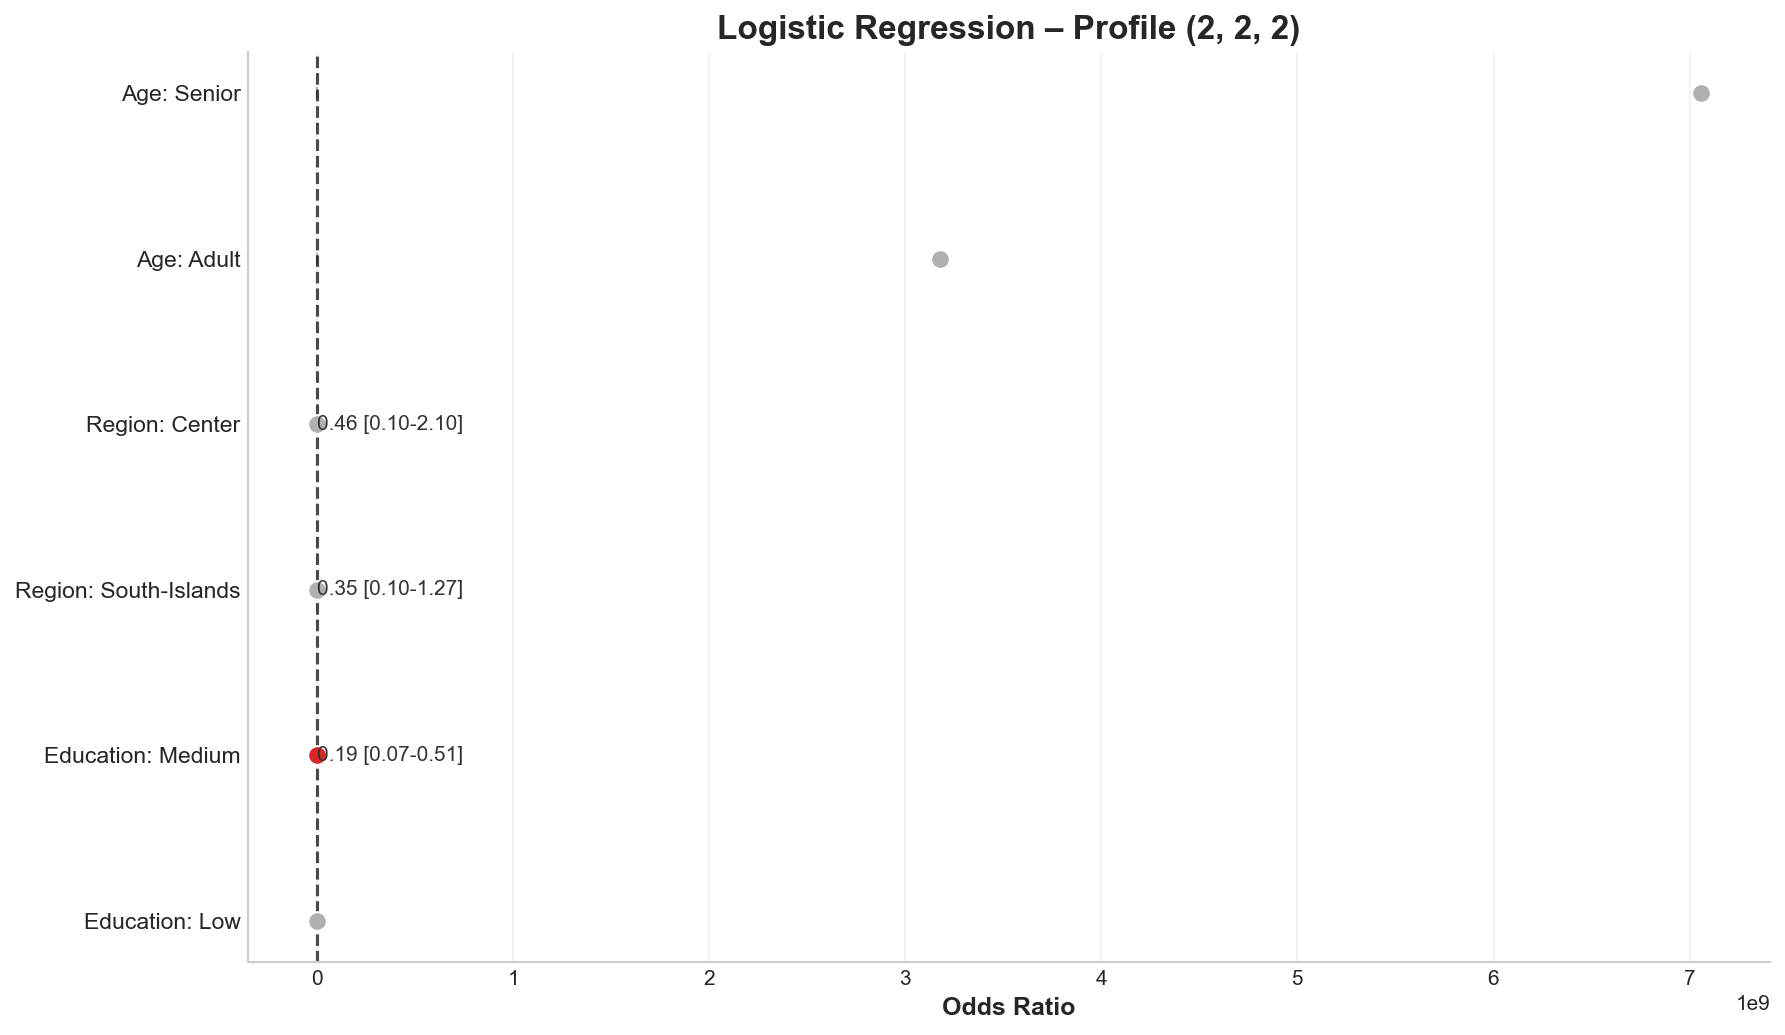

In [91]:
model, table = run_logit_forest_plot(df_analysis, profile=(2, 2, 2))


--- WEIGHTED LOGISTIC REGRESSION ---
                               Coefficient  P-Value  Odds Ratio (OR)  CI 2.5%  \
Intercept                           -2.247    0.000            0.106    0.077   
macro_region[T.Center]               0.015    0.923            1.015    0.753   
macro_region[T.South-Islands]        0.022    0.857            1.023    0.800   
age_group[T.Adult]                   0.093    0.535            1.098    0.818   
age_group[T.Senior]                 -0.009    0.953            0.991    0.726   
edu_group[T.Medium]                 -0.411    0.002            0.663    0.514   
edu_group[T.Low]                    -0.756    0.000            0.470    0.309   

                               CI 97.5%  
Intercept                         0.145  
macro_region[T.Center]            1.367  
macro_region[T.South-Islands]     1.307  
age_group[T.Adult]                1.474  
age_group[T.Senior]               1.351  
edu_group[T.Medium]               0.855  
edu_group[T.Low]   

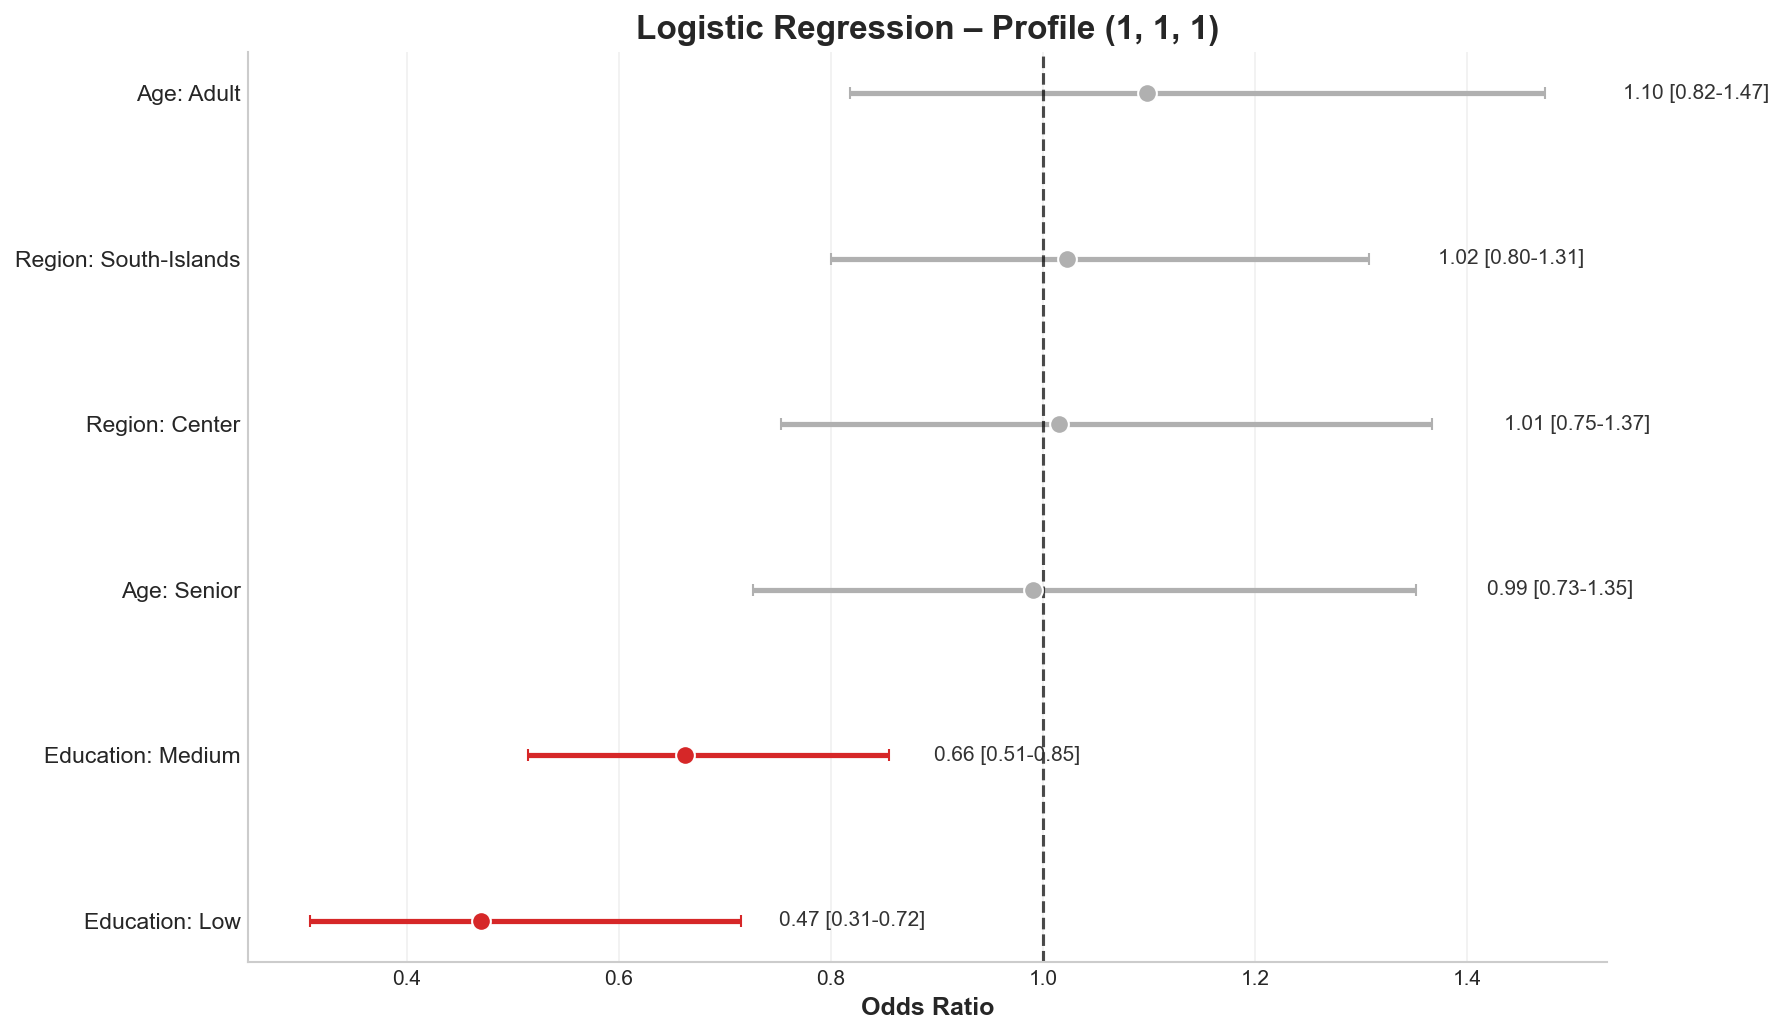

In [92]:
# BenchMark Profile
model, table = run_logit_forest_plot(df_analysis, profile=(1, 1, 1))


--- WEIGHTED LOGISTIC REGRESSION ---
                               Coefficient  P-Value  Odds Ratio (OR)  CI 2.5%  \
Intercept                           -1.329    0.000            0.265    0.214   
macro_region[T.Center]              -0.075    0.415            0.928    0.775   
macro_region[T.South-Islands]       -0.045    0.549            0.956    0.825   
age_group[T.Adult]                  -0.018    0.847            0.982    0.816   
age_group[T.Senior]                  0.098    0.302            1.103    0.916   
edu_group[T.Medium]                  0.183    0.043            1.201    1.006   
edu_group[T.Low]                     0.496    0.000            1.641    1.299   

                               CI 97.5%  
Intercept                         0.327  
macro_region[T.Center]            1.111  
macro_region[T.South-Islands]     1.107  
age_group[T.Adult]                1.181  
age_group[T.Senior]               1.328  
edu_group[T.Medium]               1.434  
edu_group[T.Low]   

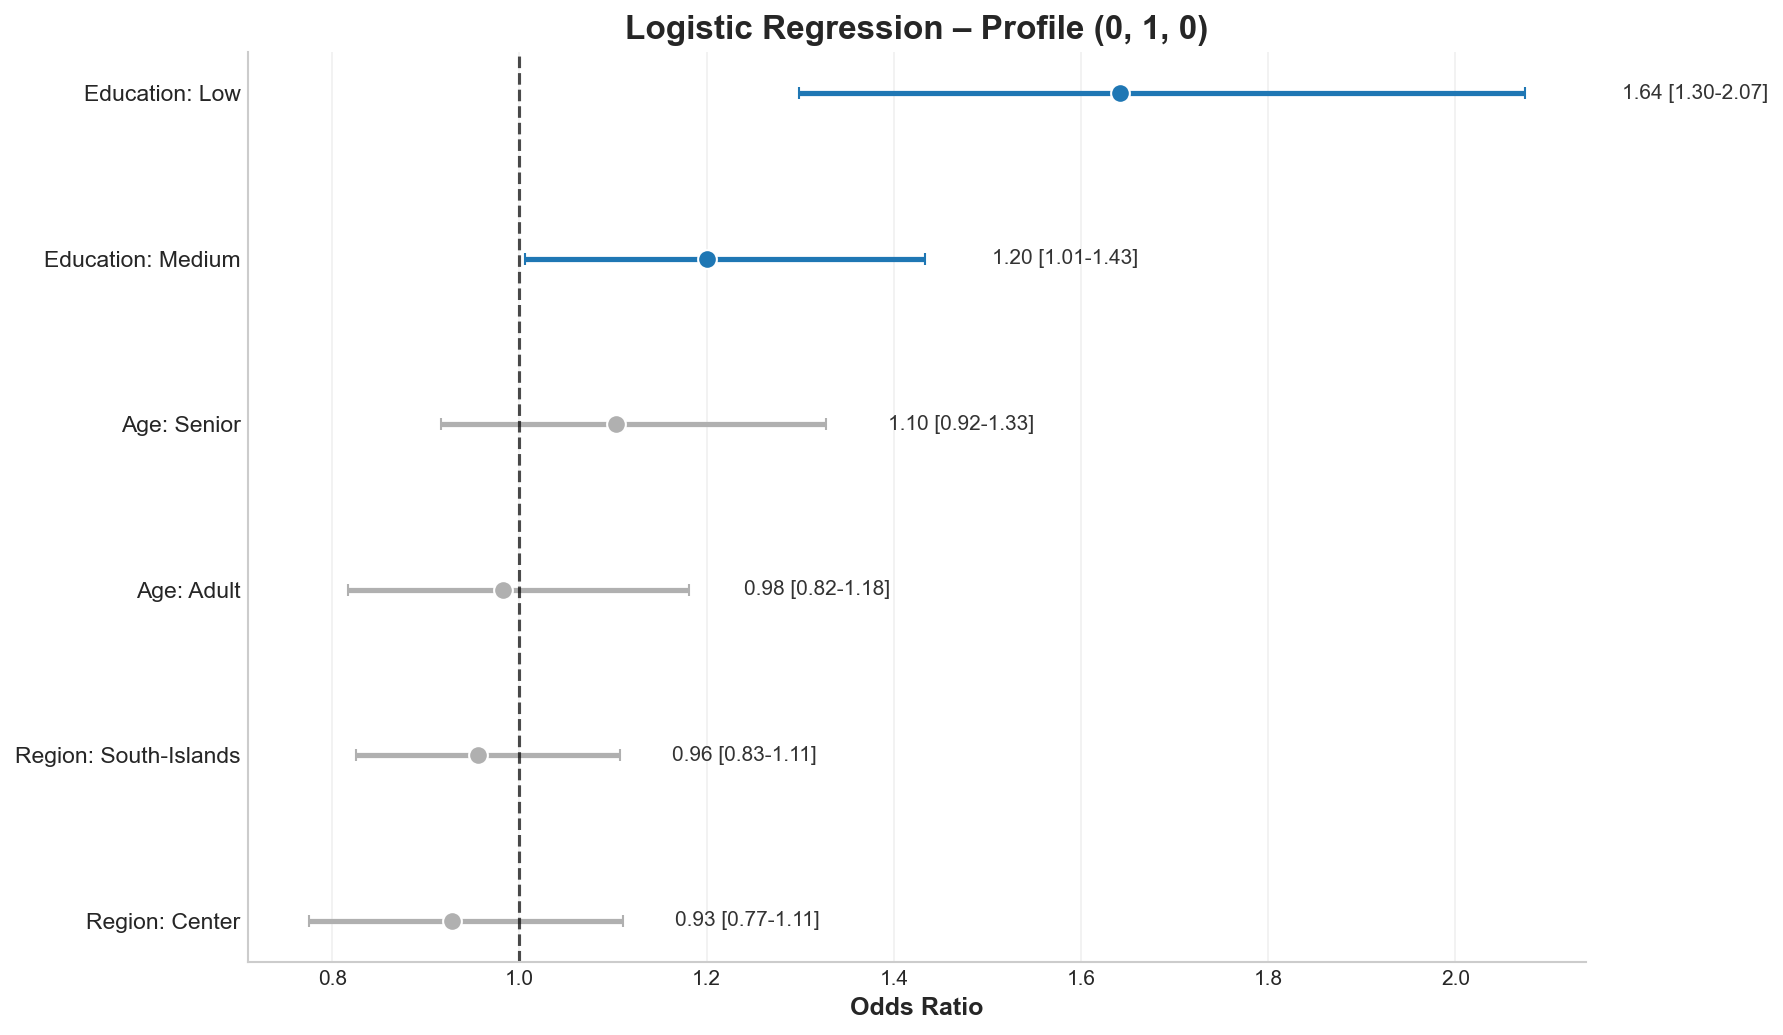

In [93]:
model, table = run_logit_forest_plot(df_analysis, profile=(0, 1, 0))


--- WEIGHTED LOGISTIC REGRESSION ---
                               Coefficient  P-Value  Odds Ratio (OR)  CI 2.5%  \
Intercept                           -3.523    0.000            0.029    0.018   
macro_region[T.Center]               0.173    0.377            1.189    0.809   
macro_region[T.South-Islands]        0.139    0.399            1.149    0.832   
age_group[T.Adult]                   0.237    0.255            1.267    0.843   
age_group[T.Senior]                  0.123    0.568            1.131    0.742   
edu_group[T.Medium]                  0.184    0.347            1.202    0.819   
edu_group[T.Low]                    -0.028    0.922            0.973    0.561   

                               CI 97.5%  
Intercept                         0.047  
macro_region[T.Center]            1.747  
macro_region[T.South-Islands]     1.587  
age_group[T.Adult]                1.905  
age_group[T.Senior]               1.724  
edu_group[T.Medium]               1.762  
edu_group[T.Low]   

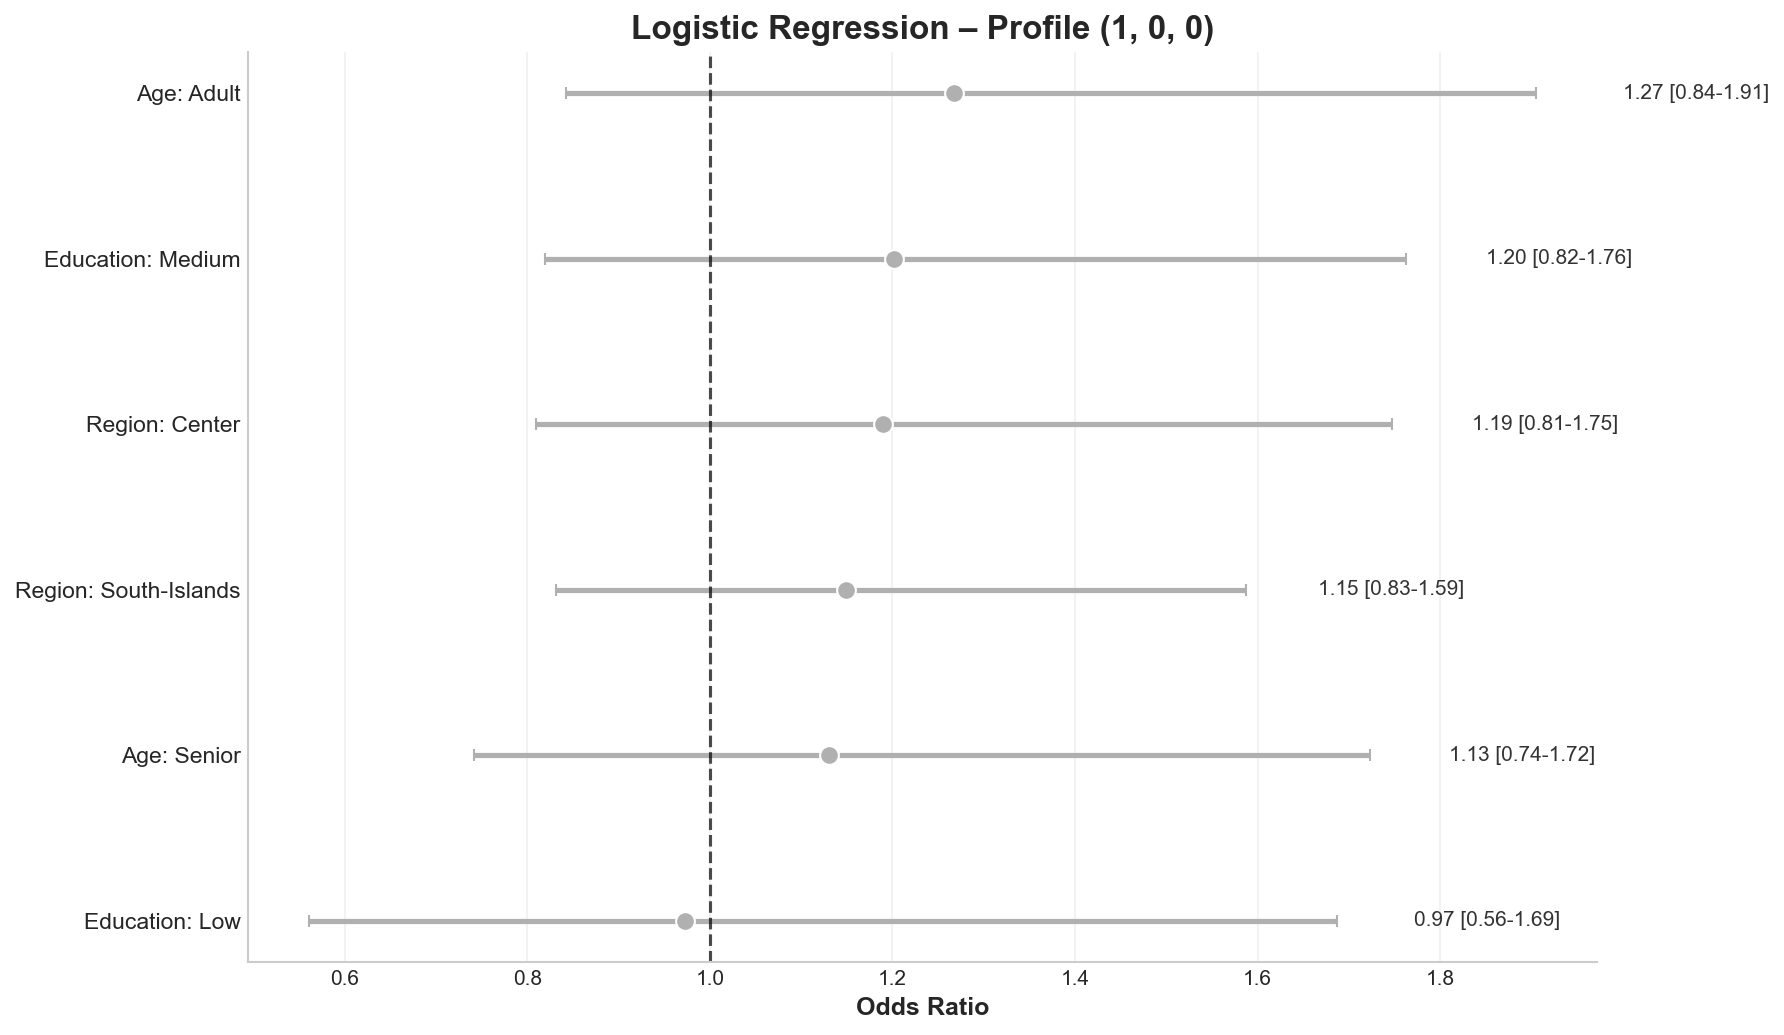

In [94]:
# BenchMark Profile
model, table = run_logit_forest_plot(df_analysis, profile=(1, 0, 0))


--- WEIGHTED LOGISTIC REGRESSION ---
                               Coefficient  P-Value  Odds Ratio (OR)  CI 2.5%  \
Intercept                           -4.336    0.000            0.013    0.007   
macro_region[T.Center]               0.307    0.314            1.359    0.748   
macro_region[T.South-Islands]        0.477    0.054            1.611    0.992   
age_group[T.Adult]                   0.008    0.978            1.008    0.576   
age_group[T.Senior]                 -0.331    0.283            0.718    0.392   
edu_group[T.Medium]                  0.279    0.342            1.321    0.744   
edu_group[T.Low]                    -0.167    0.717            0.846    0.343   

                               CI 97.5%  
Intercept                         0.026  
macro_region[T.Center]            2.468  
macro_region[T.South-Islands]     2.617  
age_group[T.Adult]                1.763  
age_group[T.Senior]               1.315  
edu_group[T.Medium]               2.347  
edu_group[T.Low]   

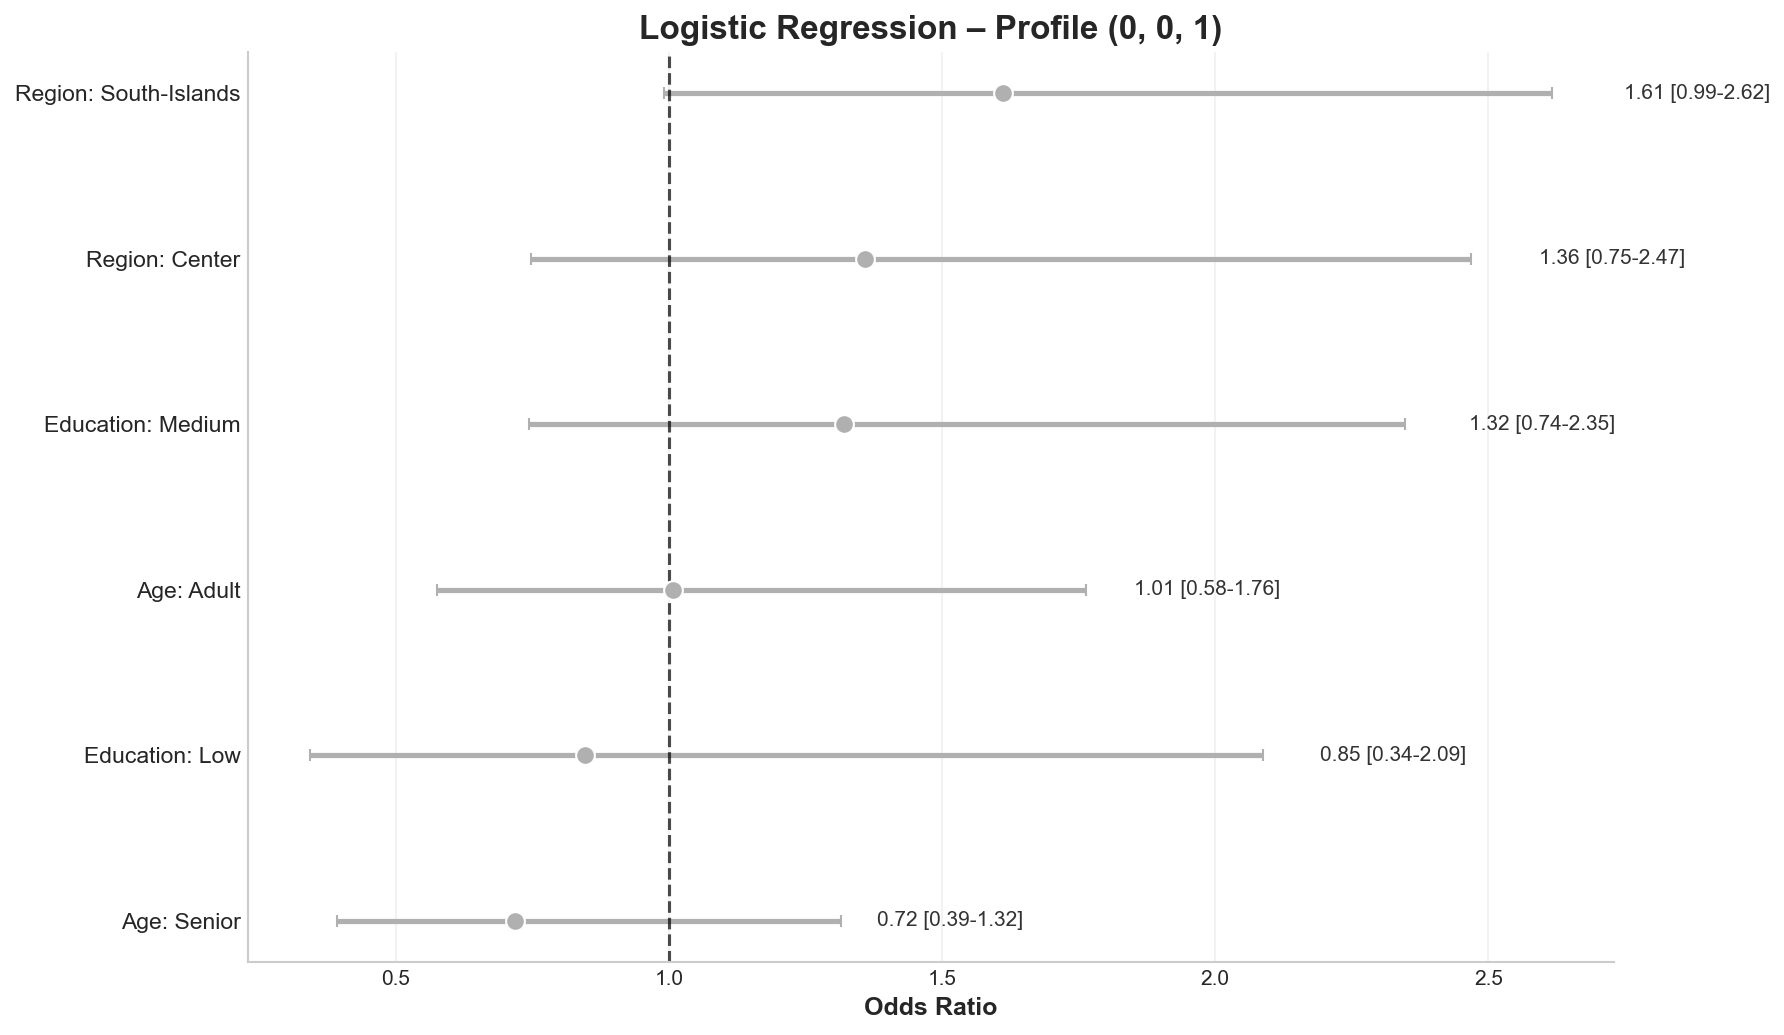

In [95]:
model, table = run_logit_forest_plot(df_analysis, profile=(0, 0, 1))

In [96]:
# Estimates a weighted least squares (WLS) regression to see how socio-demographic factors and their interactions (e.g., age and education) 
# increase or decrease the overall continuous score, and then displays the statistical summary.
def run_wls_model(df, formula):

    # Make a copy of the dataset
    df_model = df.copy()

    # Prepare categorical variables (region, age, education)
    df_model = prepare_regional_dataframe(df_model)
    df_model = prepare_age_dataframe(df_model)
    df_model = prepare_education_dataframe(df_model)

    # Check that all required columns exist
    required = ['macro_region', 'age_group', 'edu_group', 
                'final_score_scaled', 'weight']
    for col in required:
        if col not in df_model.columns:
            raise ValueError(f"Missing column: {col}")

    # Fit a Weighted Least Squares (WLS) regression model
    
    model = smf.wls(
        formula,
        data=df_model,       
        weights=df_model["weight"]  # sample weights
    ).fit()

    # Print model information
    print("\n--- MODEL ---")
    print(formula)
    print(model.summary())

    # Return the fitted model for further analysis
    return model

In [97]:
m1 = run_wls_model(
    df_analysis, "final_score_scaled ~ macro_region + age_group * edu_group")


--- MODEL ---
final_score_scaled ~ macro_region + age_group * edu_group
                            WLS Regression Results                            
Dep. Variable:     final_score_scaled   R-squared:                       0.053
Model:                            WLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     27.09
Date:                Sat, 30 May 2026   Prob (F-statistic):           6.80e-51
Time:                        15:48:50   Log-Likelihood:                -8315.5
No. Observations:                4862   AIC:                         1.665e+04
Df Residuals:                    4851   BIC:                         1.672e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                              coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------

In [98]:
m2 = run_wls_model(
    df_analysis, "final_score_scaled ~ edu_group + age_group * macro_region")


--- MODEL ---
final_score_scaled ~ edu_group + age_group * macro_region
                            WLS Regression Results                            
Dep. Variable:     final_score_scaled   R-squared:                       0.048
Model:                            WLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     24.68
Date:                Sat, 30 May 2026   Prob (F-statistic):           4.33e-46
Time:                        15:48:50   Log-Likelihood:                -8327.0
No. Observations:                4862   AIC:                         1.668e+04
Df Residuals:                    4851   BIC:                         1.675e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------

In [99]:
m3 = run_wls_model(
    df_analysis, "final_score_scaled ~ age_group + edu_group * macro_region")


--- MODEL ---
final_score_scaled ~ age_group + edu_group * macro_region
                            WLS Regression Results                            
Dep. Variable:     final_score_scaled   R-squared:                       0.048
Model:                            WLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     24.70
Date:                Sat, 30 May 2026   Prob (F-statistic):           4.07e-46
Time:                        15:48:51   Log-Likelihood:                -8326.9
No. Observations:                4862   AIC:                         1.668e+04
Df Residuals:                    4851   BIC:                         1.675e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------

In [100]:
# Region x Education 
def plot_region_education_interaction(df):
    
    # Feature engineering
    df_plot = df.copy()
    df_plot = prepare_regional_dataframe(df_plot)
    df_plot = prepare_education_dataframe(df_plot)
    df_plot = prepare_age_dataframe(df_plot)

    # Required columns check
    required = ['macro_region', 'edu_group', 'final_score_scaled']
    for col in required:
        if col not in df_plot.columns:
            raise ValueError(f"Missing column: {col}")

    # Style
    
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))

    # Fixed Order
    region_order = ['North', 'Center', 'South-Islands']
    edu_order = ['High', 'Medium', 'Low']

    # Plot
    ax = sns.pointplot(
        data=df_plot,
        x='macro_region',
        y='final_score_scaled',
        hue='edu_group',
        order=region_order,
        hue_order=edu_order,
        palette='magma',
        dodge=0.1,
        markers=['o', 's', 'D'],
        linestyles=['-', '--', ':'],
        capsize=0.05
    )

    # Labels
    plt.title("Interaction Plot: Education × Region", 
              fontsize=14, fontweight='bold')
    plt.xlabel("Macro Region", fontsize=12, fontweight='bold')
    plt.ylabel("Average Poset Score", fontsize=12, fontweight='bold')

    plt.legend(title='Education Level', 
               bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()
    
# Age x Region 

def plot_region_age_interaction(df):
    df_plot = df.copy()
    df_plot = prepare_regional_dataframe(df_plot)
    df_plot = prepare_age_dataframe(df_plot)

    import seaborn as sns
    import matplotlib.pyplot as plt

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))

    # Fix Orders
    region_order = ['North', 'Center', 'South-Islands']
    age_order = ['Young', 'Adult', 'Senior']

    sns.pointplot(
        data=df_plot,
        x='macro_region',
        y='final_score_scaled',
        hue='age_group',
        order=region_order,
        hue_order=age_order,
        palette='viridis',
        dodge=0.1,
        markers=['o', 's', 'D'],
        linestyles=['-', '--', ':'],
        capsize=0.05
    )

    plt.title('Interaction Plot: Age × Region', fontsize=14, fontweight='bold')
    plt.xlabel('Macro Region', fontweight='bold')
    plt.ylabel('Final Score (posetico medio)', fontweight='bold')

    plt.legend(title="Age Group", bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()
    
# Age x Education 

def plot_age_education_interaction(df):
    df_plot = df.copy()

    # Feature engineering
    df_plot = prepare_age_dataframe(df_plot)
    df_plot = prepare_education_dataframe(df_plot)

    # Required columns check
    required = ['age_group', 'edu_group', 'final_score_scaled']
    for col in required:
        if col not in df_plot.columns:
            raise ValueError(f"Missing column: {col}")

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))

    # Fixed order
    age_order = ['Young', 'Adult', 'Senior']
    edu_order = ['High', 'Medium', 'Low']

    sns.pointplot(
        data=df_plot,
        x='age_group',
        y='final_score_scaled',
        hue='edu_group',
        order=age_order,
        hue_order=edu_order,
        palette='plasma',
        dodge=0.1,
        markers=['o', 's', 'D'],
        linestyles=['-', '--', ':'],
        capsize=0.05
    )

    plt.title('Interaction Plot: Age × Education', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Age Group', fontweight='bold')
    plt.ylabel('Average Poset Score', fontweight='bold')

    plt.legend(title='Education Level', 
               bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

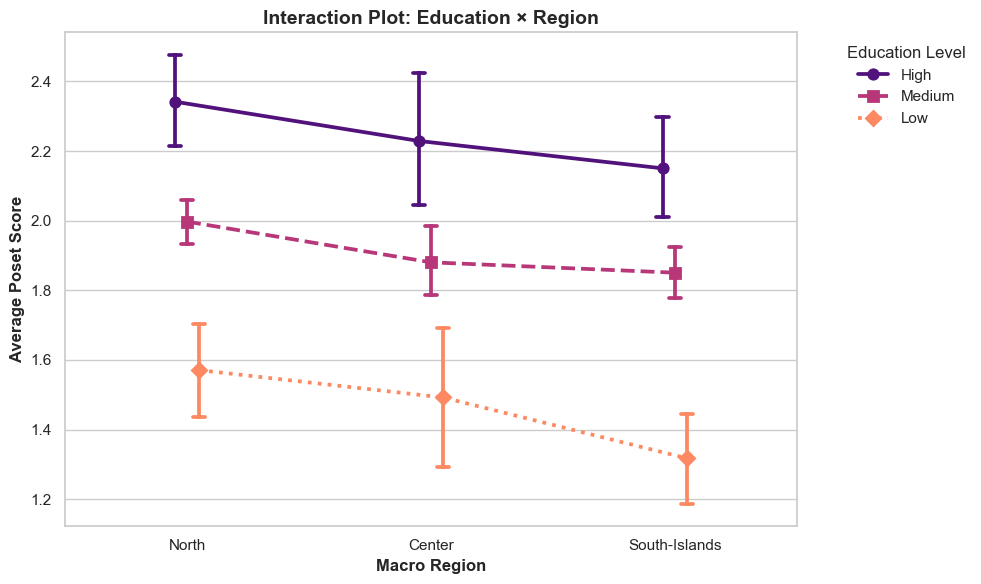

In [101]:
plot_region_education_interaction(df_analysis)

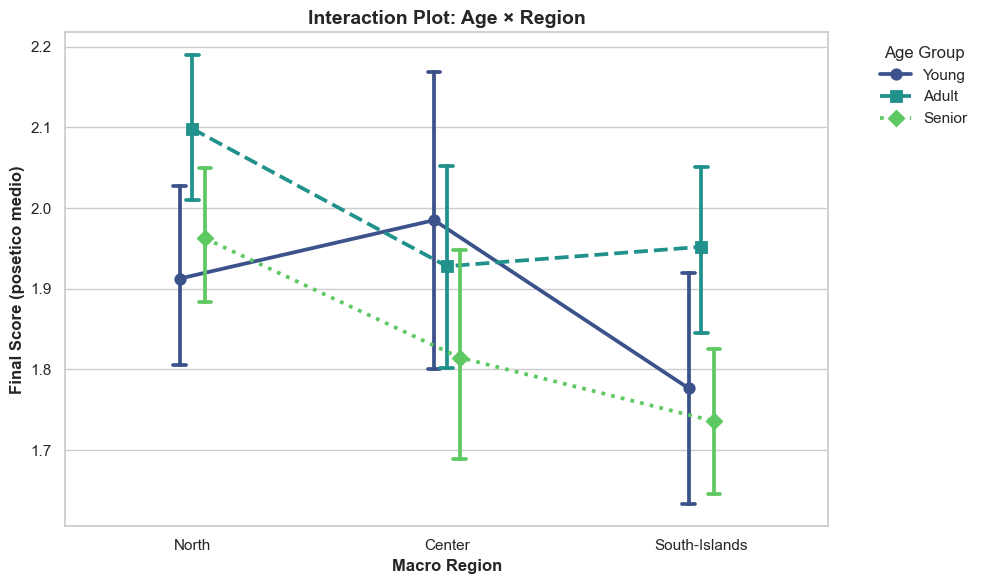

In [102]:
plot_region_age_interaction(df_analysis)

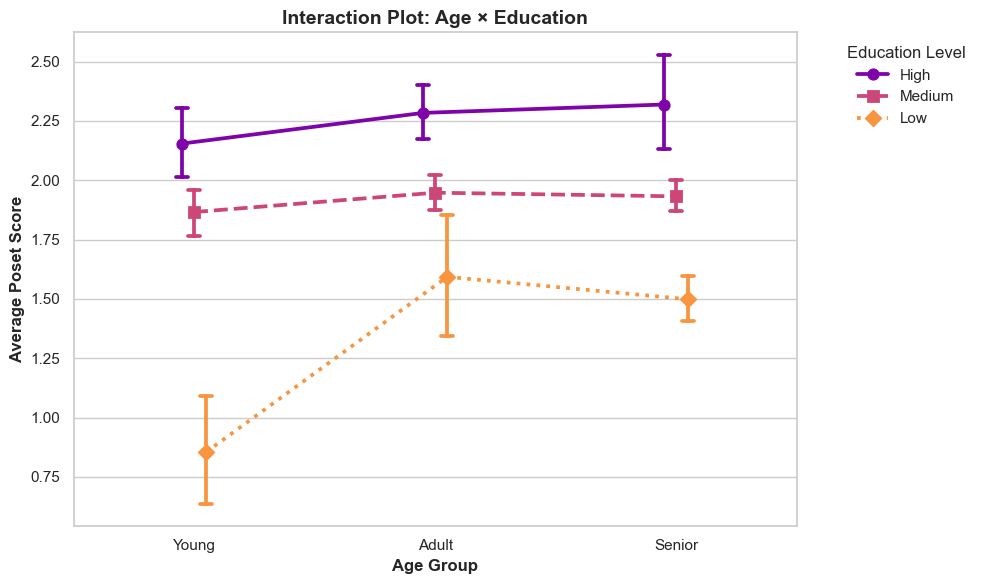

In [103]:
plot_age_education_interaction(df_analysis)